In [35]:
# from google.colab import drive
# drive.mount('/content/gdrive')
# working_dir = '/content/gdrive/MyDrive/Colab Notebooks/Forecasting Project 1'

In [36]:
# import os
# os.chdir(working_dir)
# print(f"Current working directory: {os.getcwd()}")

# Transform Data

Retail data from: https://archive.ics.uci.edu/dataset/502/online+retail+ii

Read data from excel and processed total_retail to pd DataFrame.

#### **Drop Overlapping rows**

Two sheets overlap. Between Invoice [536365, 538171], or between time [01/12/2010 08:26, 09/12/2010 20:01]. Total of 22524 entries.

#### **Need to clear duplicate rows**

#### **Drop Bad Rows???**

Most rows with price = 0 contains random input noise. These are manual entries that are labeled by the operator to indicate some kind of adjustment or alignment between records and actual sales. A huge majority of these are items with nan Description, indicating they might just be small adjustments, they have negative quantity, and could just be cleaned up inventory. Other price = 0 entries are labeled as missing, destroyed, test product, or just gifts (these have actual product descriptions, positive quantity, but 0 price). There are only a handful of rows with price < 0, they are all labeled "adjust bad debt", which is an regulatory and administrative decision, and should not be reflected in the market prediction model.

These account for less than 0.6% of total entries

#### **Missingness**

Seems like we handled missingness during our cleaning process. We only combined, renamed, dropped overlap, and dropped bad rows (based on price).

In [37]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Define file paths for cleaned data
cleaned_retail_path = 'online retail/total_retail_cleaned.csv'
cleaned_products_path = 'online retail/all_products_cleaned.csv'
excel_file_path = 'online retail/online_retail_II.xlsx'

# Check if cleaned data already exists
if os.path.exists(cleaned_retail_path) and os.path.exists(cleaned_products_path):
    print("Loading already cleaned data from CSVs...")
    total_retail = pd.read_csv(cleaned_retail_path)
    total_retail['InvoiceDate'] = pd.to_datetime(total_retail['InvoiceDate'])
    all_products = pd.read_csv(cleaned_products_path)
    print("Cleaned data loaded successfully.")
else:
    print("Cleaned data not found. Processing raw data...")
    # Load raw data
    xl_file = pd.ExcelFile(excel_file_path)
    dfs = {sheet_name: xl_file.parse(sheet_name) for sheet_name in xl_file.sheet_names}

    # Drop Overlapping rows
    dfs['Year 2009-2010']['Invoice'] = dfs['Year 2009-2010']['Invoice'].astype(str)
    first_repeat_ind = dfs['Year 2009-2010'][dfs['Year 2009-2010']['Invoice'] == '536365'].index[0]
    dfs['Year 2009-2010'] = dfs['Year 2009-2010'].iloc[:first_repeat_ind]

    # Combine and cast types
    total_retail = pd.concat([dfs['Year 2009-2010'], dfs['Year 2010-2011']], ignore_index=True)
    total_retail[['Customer ID', 'Country']] = total_retail[['Customer ID', 'Country']].astype(str)
    total_retail['InvoiceDate'] = pd.to_datetime(total_retail['InvoiceDate'])
    total_retail[['Invoice', 'StockCode', 'Description']] = total_retail[['Invoice', 'StockCode', 'Description']].astype(str)
    total_retail.columns = [col.replace(' ', '') for col in total_retail.columns]

    # Drop duplicate rows
    initial_shape = total_retail.shape[0]
    total_retail = total_retail.drop_duplicates()
    print(f"Dropped {initial_shape - total_retail.shape[0]} duplicate rows.")

    # Drop all rows with price <= 0
    total_retail = total_retail[total_retail['Price'] > 0]
    print(f"Dropped rows with Price <= 0. Remaining: {total_retail.shape[0]}")

    # Check missingness
    print('\nPercentage missing in original datasets:')
    print(pd.concat([dfs['Year 2009-2010'], dfs['Year 2010-2011']], ignore_index=True).isna().sum()/len(pd.concat([dfs['Year 2009-2010'], dfs['Year 2010-2011']], ignore_index=True)))
    print('Percentage missing in cleaned dataset:')
    print(total_retail.isna().sum()/len(total_retail))

    # By-product Adjustments
    all_products = total_retail.groupby('StockCode')['Description'].agg(['first', 'count']).sort_values('count', ascending=False).reset_index()
    non_product_entries = [
        'POSTAGE', 'DOTCOM POSTAGE', 'Manual', 'CARRIAGE', 'Discount',
        'SAMPLES', ' Bank Charges', 'AMAZON FEE', 'ebay', 'nan',
        'CRUK Commission', 'This is a test product.', 'Adjust bad debt',
        'Dotcomgiftshop Gift Voucher £10.00',
        'Dotcomgiftshop Gift Voucher £20.00',
        'Dotcomgiftshop Gift Voucher £30.00',
        'Dotcomgiftshop Gift Voucher £40.00',
        'Dotcomgiftshop Gift Voucher £50.00',
        'Dotcomgiftshop Gift Voucher £60.00',
        'Dotcomgiftshop Gift Voucher £70.00',
        'Dotcomgiftshop Gift Voucher £80.00',
        'Adjustment by john on 26/01/2010 16',
        'Adjustment by Peter on Jun 25 2010 '
    ]
    all_products = all_products[~all_products['first'].isin(non_product_entries)]
    total_retail = total_retail[total_retail['StockCode'].isin(all_products['StockCode'])]
    print(f"Filtered non-product entries. Remaining products: {len(all_products)}")
    all_products.info()

    # Save cleaned data
    total_retail.to_csv(cleaned_retail_path, index=False)
    all_products.to_csv(cleaned_products_path, index=False)
    print("Cleaned data saved to CSVs.")

print(f"\nFinal total_retail shape: {total_retail.shape}")
print(f"Final all_products shape: {all_products.shape}")

Loading already cleaned data from CSVs...
Cleaned data loaded successfully.

Final total_retail shape: (1021272, 8)
Final all_products shape: (4910, 3)


# Train - Val - Test split

In [38]:
# Add useful columns for analysis
total_retail['Week'] = total_retail["InvoiceDate"].dt.to_period("W")
total_retail['Sales'] = total_retail['Quantity'] * total_retail['Price']

total_weeks = total_retail['Week'].unique()
# Impute any missing weeks
all_weeks = pd.period_range(start=total_weeks.min(), end=total_weeks.max(), freq='W')
print(f"Total weeks in dataset: {len(all_weeks)} (from {all_weeks.min()} to {all_weeks.max()})")

# Testing and validation horizon of 12 weeks
horizon = 12
training_weeks = all_weeks[:-2*horizon]
validation_weeks = all_weeks[-2*horizon:-horizon]
test_weeks = all_weeks[-horizon:]
print(f"Training weeks: {len(training_weeks)}, Validation weeks: {len(validation_weeks)}, Test weeks: {len(test_weeks)}")

retail_train = total_retail[total_retail['Week'].isin(training_weeks)]
retail_valid = total_retail[total_retail['Week'].isin(validation_weeks)]
retail_test = total_retail[total_retail['Week'].isin(test_weeks)]
print(f"Training set shape: {retail_train.shape}, Validation set shape: {retail_valid.shape}, Test set shape: {retail_test.shape}")

# Train used for clustering and modelling, test set held out for future forecasting evaluation
retail_train.reset_index(drop=True, inplace=True)
retail_valid.reset_index(drop=True, inplace=True)
retail_test.reset_index(drop=True, inplace=True)

Total weeks in dataset: 106 (from 2009-11-30/2009-12-06 to 2011-12-05/2011-12-11)
Training weeks: 82, Validation weeks: 12, Test weeks: 12
Training set shape: (725920, 10), Validation set shape: (104072, 10), Test set shape: (191280, 10)


# Clustering Features

Cell skippable if product_features_scaled, product_features_full already saved

In [39]:
from scipy.stats import linregress
from sklearn.preprocessing import RobustScaler

# ── 0. Load & clean ───────────────────────────────────────────────────────────
retail_mod = retail_train.copy()

# Separate cancellations (InvoiceNo starting with 'C')
retail_mod["is_cancelled"] = retail_mod["Invoice"].astype(str).str.startswith("C")
cancellations = retail_mod[retail_mod["is_cancelled"]].copy()
sales = retail_mod[~retail_mod["is_cancelled"]].copy()

# Remove non-product rows (postage, manual charges, etc.)
# sales = sales[sales["Price"] > 0] # Already done in cleaning step
# sales = sales[sales["Quantity"] > 0] # All negative quantities are cancellations, already separated
# sales = sales[sales["StockCode"].astype(str).str.match(r"^\d{5}")] # valid products already filtered

# Week label for each transaction (used for weekly aggregations)
sales["week"] = sales["InvoiceDate"].dt.to_period("W")
sales["month"] = sales["InvoiceDate"].dt.month
sales["quarter"] = sales["InvoiceDate"].dt.quarter
sales["year"] = sales["InvoiceDate"].dt.year

# Full week range in the dataset (to count zero-sales weeks)
clustering_weeks = pd.period_range(
    start=sales["InvoiceDate"].min().to_period("W"),
    end=sales["InvoiceDate"].max().to_period("W"),
    freq="W"
)
total_weeks = len(clustering_weeks)


# ── 1. Weekly sales per product ───────────────────────────────────────────────

weekly = (
    sales.groupby(["StockCode", "week"])["Sales"]
    .sum()
    .reset_index()
    .rename(columns={"Sales": "weekly_sales"})
)

# Pivot so every product has a row for every week (fill missing with 0)
weekly_pivot = (
    weekly.pivot(index="StockCode", columns="week", values="weekly_sales")
    .reindex(columns=clustering_weeks)
    .fillna(0)
)


# ── 2. Helper: seasonal concentration (Herfindahl index) ─────────────────────
# HHI = sum of squared monthly share. Range 0–1. Higher = more concentrated.

def herfindahl(monthly_totals):
    total = monthly_totals.sum()
    if total == 0:
        return np.nan
    shares = monthly_totals / total
    return (shares ** 2).sum()


# ── 3. Build feature table ────────────────────────────────────────────────────

features = []

for stock_code, group in sales.groupby("StockCode"):

    # --- Demand level ---
    weekly_sales = weekly_pivot.loc[stock_code] if stock_code in weekly_pivot.index else pd.Series(dtype=float)
    mean_weekly_sales    = weekly_sales.mean()
    median_weekly_sales  = weekly_sales.median()
    total_sales          = weekly_sales.sum()
    mean_txn_size      = group["Sales"].mean()

    # --- Volatility ---
    std_weekly_sales     = weekly_sales.std()
    cv                 = std_weekly_sales / mean_weekly_sales if mean_weekly_sales > 0 else np.nan
    spike_ratio        = weekly_sales.max() / mean_weekly_sales if mean_weekly_sales > 0 else np.nan

    # --- Intermittency ---
    zero_weeks         = (weekly_sales == 0).sum()
    pct_zero_weeks     = zero_weeks / total_weeks

    # Average inter-demand interval (days between consecutive transactions)
    txn_dates          = group["InvoiceDate"].sort_values()
    if len(txn_dates) > 1:
        gaps           = txn_dates.diff().dt.days.dropna()
        avg_idi        = gaps.mean()
    else:
        avg_idi        = np.nan

    # Longest streak of zero-sales weeks
    in_streak, max_streak, cur_streak = False, 0, 0
    for v in weekly_sales:
        if v == 0:
            cur_streak += 1
            max_streak = max(max_streak, cur_streak)
        else:
            cur_streak = 0
    longest_zero_streak = max_streak

    # --- Seasonality & timing ---
    monthly_sales        = group.groupby("month")["Sales"].sum().reindex(range(1, 13), fill_value=0)
    q4_pct             = monthly_sales[[10, 11, 12]].sum() / total_sales if total_sales > 0 else np.nan
    q1_pct             = monthly_sales[[1, 2, 3]].sum()   / total_sales if total_sales > 0 else np.nan
    peak_month         = int(monthly_sales.idxmax())
    seasonal_conc      = herfindahl(monthly_sales)

    # --- Trend ---
    weekly_values      = weekly_sales.values
    if len(weekly_values) > 1 and weekly_values.sum() > 0:
        x              = np.arange(len(weekly_values))
        slope, *_      = linregress(x, weekly_values)
        trend_slope    = slope
    else:
        trend_slope    = np.nan

    # Sales in last 3 months vs first 3 months
    date_min           = group["InvoiceDate"].min()
    date_max           = group["InvoiceDate"].max()
    cutoff_early       = date_min + pd.DateOffset(months=3)
    cutoff_late        = date_max - pd.DateOffset(months=3)
    early_sales        = group[group["InvoiceDate"] < cutoff_early]["Sales"].sum()
    late_sales         = group[group["InvoiceDate"] > cutoff_late]["Sales"].sum()
    trend_log_diff     = np.log1p(late_sales) - np.log1p(early_sales)

    # --- Price ---
    mean_price         = group["Price"].mean()
    std_price          = group["Price"].std()

    # --- Customer base ---
    n_unique_customers = group["CustomerID"].nunique()
    total_customers    = group["CustomerID"].count()
    repeat_customers   = total_customers - n_unique_customers
    pct_repeat         = repeat_customers / total_customers if total_customers > 0 else np.nan
    n_countries        = group["Country"].nunique()
    top_country_pct    = group["Country"].value_counts(normalize=True).iloc[0] if len(group) > 0 else np.nan

    # --- Cancellation rate ---
    cancelled_sales      = cancellations[cancellations["StockCode"] == stock_code]["Sales"].abs().sum()
    cancel_rate        = cancelled_sales / (total_sales + cancelled_sales) if (total_sales + cancelled_sales) > 0 else 0.0

    features.append({
        "StockCode":           stock_code,
        # Demand level
        "mean_weekly_sales":     mean_weekly_sales,
        "median_weekly_sales":   median_weekly_sales,
        "total_sales":           total_sales,
        "mean_txn_size":       mean_txn_size,
        # Volatility
        "std_weekly_sales":      std_weekly_sales,
        "cv":                  cv,
        "spike_ratio":         spike_ratio,
        # Intermittency
        "pct_zero_weeks":      pct_zero_weeks,
        "avg_idi_days":        avg_idi,
        "longest_zero_streak": longest_zero_streak,
        # Seasonality
        "q4_pct":              q4_pct,
        "q1_pct":              q1_pct,
        "peak_month":          peak_month,
        "seasonal_conc":       seasonal_conc,
        # Trend
        "trend_slope":         trend_slope,
        "trend_log_diff":      trend_log_diff,
        # Price
        "mean_price":          mean_price,
        "std_price":           std_price,
        # Customer base
        "n_unique_customers":  n_unique_customers,
        "pct_repeat_customers":pct_repeat,
        "n_countries":         n_countries,
        "top_country_pct":     top_country_pct,
        # Returns
        "cancel_rate":         cancel_rate,
    })

feat_df = pd.DataFrame(features).set_index("StockCode")

print(f"Feature matrix shape: {feat_df.shape}")
print(feat_df.head())

# Log-transform skewed features
feat_df["log_mean_weekly_sales"] = np.log1p(feat_df["mean_weekly_sales"])
feat_df["log_mean_price"]        = np.log1p(feat_df["mean_price"])

for col in ["avg_idi_days", "longest_zero_streak", "trend_log_diff"]:
    cap = feat_df[col].quantile(0.95)
    feat_df[col] = feat_df[col].clip(upper=cap)

# ── 3b. Pre-filter truly sporadic products BEFORE clustering ──────────────────
SPORADIC_THRESHOLD = 0.85
CROSTON_THRESHOLD  = 0.50

feat_df["is_sporadic"] = feat_df["pct_zero_weeks"] > SPORADIC_THRESHOLD
feat_df["is_croston"]  = (feat_df["pct_zero_weeks"] > CROSTON_THRESHOLD) & ~feat_df["is_sporadic"]
feat_df["is_active"]   = feat_df["pct_zero_weeks"] <= CROSTON_THRESHOLD

feat_df_sporadic = feat_df[feat_df["is_sporadic"]].copy()
feat_df_croston  = feat_df[feat_df["is_croston"]].copy()
feat_df_active   = feat_df[feat_df["is_active"]].copy()

feat_df_sporadic["cluster"] = -2
feat_df_croston["cluster"]  = -1
feat_df_sporadic["cluster_label"] = "Truly sporadic"
feat_df_croston["cluster_label"]  = "Intermittent (Croston)"

print(f"Truly sporadic   (>85% zero weeks):  {len(feat_df_sporadic)}")
print(f"Croston territory (50-85%):          {len(feat_df_croston)}")
print(f"Active products   (<50% zero weeks): {len(feat_df_active)}")

# ── 4. Scale for clustering ───────────────────────────────────────────────────

# Minimal recommended feature set (drop peak_month — it's categorical)
CLUSTERING_COLS = [
    "cv",             # volatility
    "seasonal_conc",  # seasonal shape
    "q4_pct",         # Christmas signal
    "log_mean_price", # price tier
    "cancel_rate",    # return behaviour
]

# Operate on active products only from here on
feat_cluster = feat_df_active[CLUSTERING_COLS].copy()
feat_cluster = feat_cluster.fillna(feat_cluster.median())

scaler = RobustScaler()
feat_scaled = pd.DataFrame(
    scaler.fit_transform(feat_cluster),
    index=feat_cluster.index,
    columns=feat_cluster.columns,
)

print("\nScaled feature matrix (ready for clustering):")
print(feat_scaled.head())

feat_df.to_csv("clustering data/product_features_full.csv")
feat_scaled.to_csv("clustering data/product_features_scaled.csv")
print("\nSaved: product_features_full.csv and product_features_scaled.csv")

Feature matrix shape: (4556, 23)
           mean_weekly_sales  median_weekly_sales  total_sales  mean_txn_size  \
StockCode                                                                       
10002              84.661707               36.975      6942.26      18.916240   
10002R              0.250854                0.000        20.57       6.856667   
10080               0.373415                0.000        30.62       3.827500   
10109               0.020488                0.000         1.68       1.680000   
10120               1.446220                0.000       118.59       2.156182   

           std_weekly_sales        cv  spike_ratio  pct_zero_weeks  \
StockCode                                                            
10002            135.273092  1.597807     9.650172        0.146341   
10002R             1.379247  5.498212    41.219251        0.963415   
10080              2.168545  5.807337    50.131940        0.926829   
10109              0.185525  9.055385    82.00000

# Clustering

Cell skippable if product_features_clustered already saved

Optimal k = 3  (silhouette = 0.459)
  k=3: 0.459 <-- best
  k=4: 0.374
  k=5: 0.349

Cluster medians:
               cv  seasonal_conc    q4_pct  log_mean_price  cancel_rate  n_products
cluster                                                                            
0.0      1.648475       0.128122  0.272631        1.407362     0.103320          92
1.0      2.413055       0.214871  0.246146        1.197608     0.005615         228
2.0      1.290022       0.111048  0.255016        1.125147     0.007772        1281

Cluster labels:
  Cluster 0.0: High cancellation risk  (n=92)
  Cluster 1.0: Volatile mid-range  (n=228)
  Cluster 2.0: Steady regulars  (n=1281)

Saved fig1_k_selection.png
Saved fig2_pca_scatter.png
Saved fig3_radar.png
Saved fig4_boxplots.png
Saved fig5_silhouette.png

Saved product_features_clustered.csv
  Active clustered:        1601  (3 clusters)
  Intermittent / Croston:  1627
  Truly sporadic:          1328
  Total:                   4556


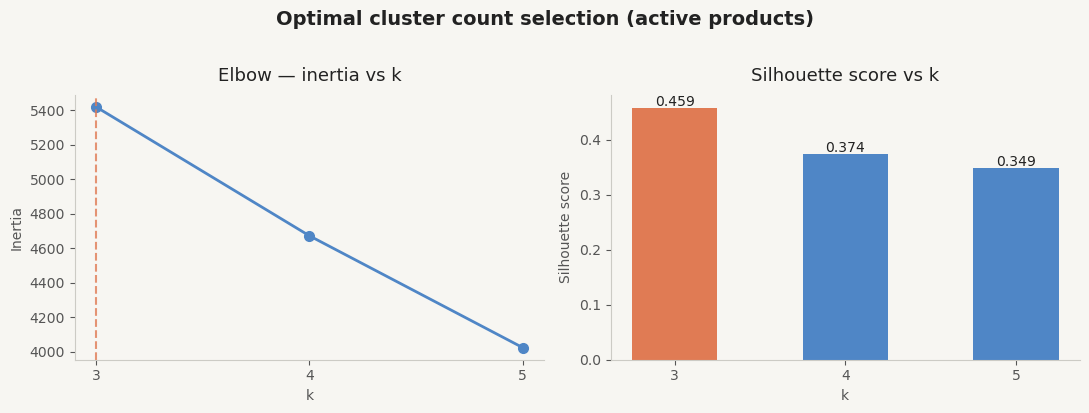

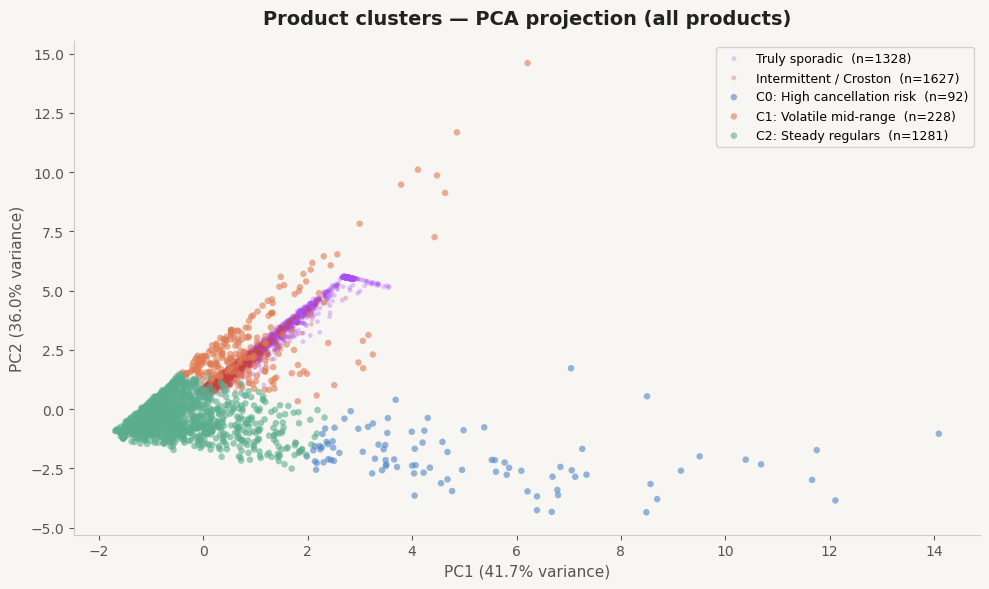

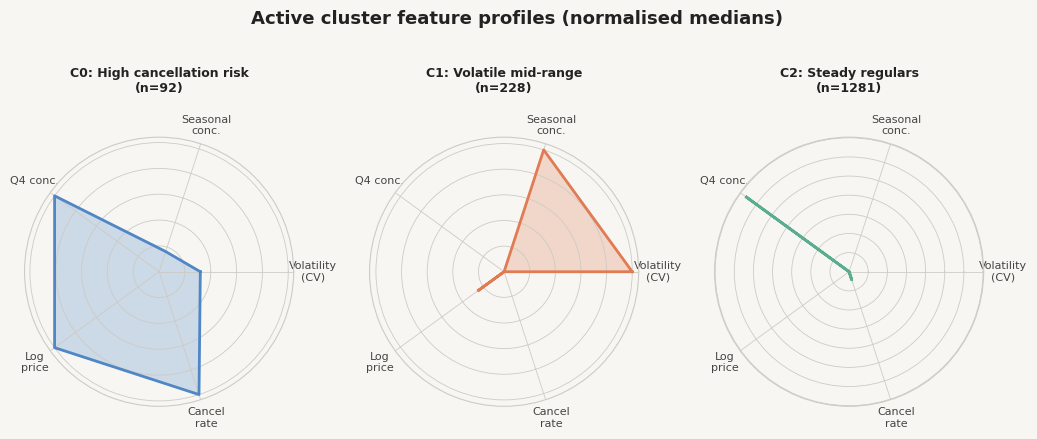

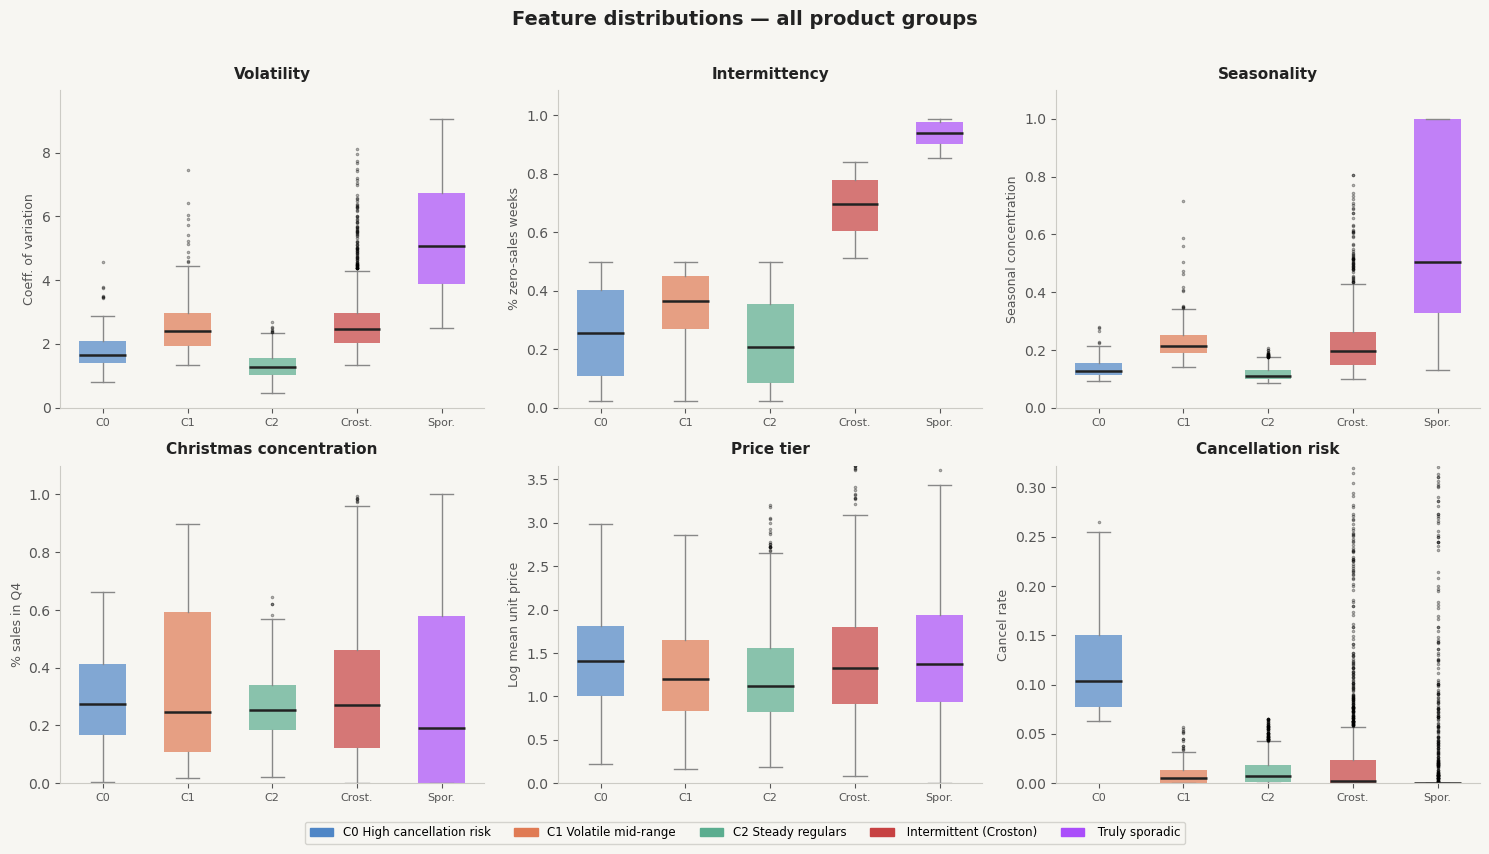

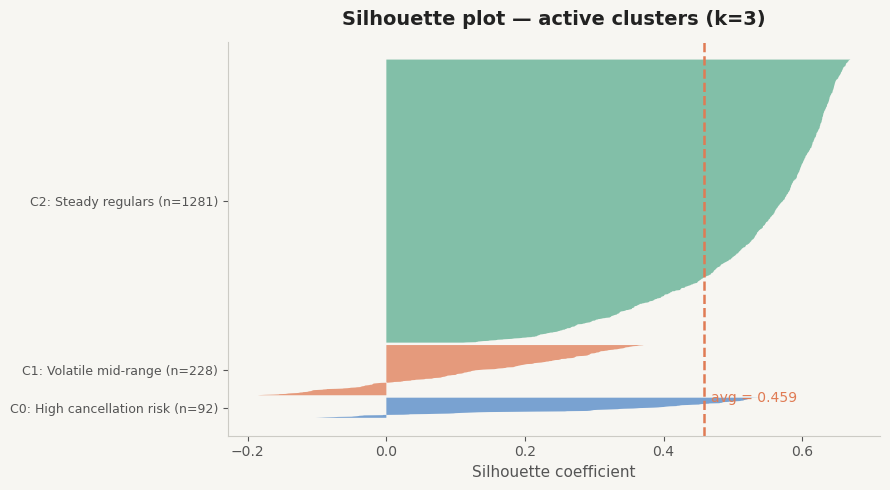

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

# ── 0. Load scaled features ───────────────────────────────────────────────────

X = feat_scaled[CLUSTERING_COLS].values

# ── 1. Choose optimal k via elbow + silhouette (active products only) ─────────

k_range    = range(3, 6)
inertias   = []
sil_scores = []
models     = {}

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    models[k] = (km, labels)

best_k               = k_range.start + int(np.argmax(sil_scores))
best_km, best_labels = models[best_k]

print(f"Optimal k = {best_k}  (silhouette = {max(sil_scores):.3f})")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.3f}{' <-- best' if k == best_k else ''}")

# Attach cluster labels (0-based) to active products only
feat_df_active = feat_df_active.copy()
feat_df_active.loc[feat_scaled.index, "cluster"] = best_labels
feat_scaled["cluster"] = best_labels

# ── 2. Cluster summary (active only) ─────────────────────────────────────────

summary = feat_df_active.groupby("cluster")[CLUSTERING_COLS].median()
summary["n_products"] = feat_df_active.groupby("cluster").size()
print("\nCluster medians:")
print(summary.to_string())

# ── 3. Auto-label active clusters ────────────────────────────────────────────

def auto_label(row):
    if row.get("cancel_rate", 0) > summary["cancel_rate"].quantile(0.75):
        return "High cancellation risk"
    if row.get("q4_pct", 0) > 0.35 and row.get("seasonal_conc", 0) > 0.18:
        return "Christmas / seasonal"
    if row.get("cv", 0) < summary["cv"].median() and row.get("cancel_rate", 0) < 0.05:
        return "Steady regulars"
    if row.get("cv", 0) >= summary["cv"].median():
        return "Volatile mid-range"
    return "Steady mid-range"

cluster_labels = {i: auto_label(summary.loc[i]) for i in summary.index}
print("\nCluster labels:")
for k, v in cluster_labels.items():
    print(f"  Cluster {k}: {v}  (n={int(summary.loc[k, 'n_products'])})")

# ── 4. Build complete labelled dataframe (all products) ───────────────────────

feat_df_active["cluster_label"] = feat_df_active["cluster"].map(cluster_labels)
feat_df_all = pd.concat([feat_df_active, feat_df_croston, feat_df_sporadic])

# Unified palette — k-means clusters get 0-based keys,
# Croston = -1, Truly sporadic = -2
PALETTE_KMEANS = {0: "#4F86C6", 1: "#E07B54", 2: "#5BAD8F", 3: "#C97EB8"}
PALETTE_FIXED  = {-1: "#C74242", -2: "#AA4EFA"}
PALETTE        = {**PALETTE_KMEANS, **PALETTE_FIXED}

LABEL_MAP = {**cluster_labels, -1: "Intermittent (Croston)", -2: "Truly sporadic"}
BG = "#F7F6F2"

# ── Figure 1: k selection ─────────────────────────────────────────────────────

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig1.patch.set_facecolor(BG)
for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCBC5")
    ax.tick_params(colors="#555")

ks = list(k_range)
ax1.plot(ks, inertias, "o-", color="#4F86C6", lw=2, ms=7)
ax1.axvline(best_k, color="#E07B54", lw=1.5, ls="--", alpha=0.8)
ax1.set_title("Elbow — inertia vs k", fontsize=13, pad=10, color="#222")
ax1.set_xlabel("k", color="#555"); ax1.set_ylabel("Inertia", color="#555")
ax1.set_xticks(ks)

bar_colors = ["#E07B54" if k == best_k else "#4F86C6" for k in ks]
ax2.bar(ks, sil_scores, color=bar_colors, width=0.5, edgecolor="none")
ax2.set_title("Silhouette score vs k", fontsize=13, pad=10, color="#222")
ax2.set_xlabel("k", color="#555"); ax2.set_ylabel("Silhouette score", color="#555")
ax2.set_xticks(ks)
for k, s in zip(ks, sil_scores):
    ax2.text(k, s + 0.003, f"{s:.3f}", ha="center", fontsize=10, color="#222")

fig1.suptitle("Optimal cluster count selection (active products)",
              fontsize=14, y=1.02, color="#222", fontweight="bold")
fig1.tight_layout()
fig1.savefig("fig1_k_selection.png", dpi=150, bbox_inches="tight",
             facecolor=fig1.get_facecolor())
print("\nSaved fig1_k_selection.png")

# ── Figure 2: PCA scatter — ALL groups including fixed ───────────────────────
# PCA fitted on active products; Croston & sporadic projected into same space

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)   # active products
var   = pca.explained_variance_ratio_

# Project the fixed groups using the same PCA
X_croston  = feat_df_croston[CLUSTERING_COLS].fillna(feat_df_active[CLUSTERING_COLS].median()).values
X_sporadic = feat_df_sporadic[CLUSTERING_COLS].fillna(feat_df_active[CLUSTERING_COLS].median()).values
X_croston_pca  = pca.transform(X_croston)
X_sporadic_pca = pca.transform(X_sporadic)

fig2, ax = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCBC5")

# Plot fixed groups first (background)
ax.scatter(X_sporadic_pca[:, 0], X_sporadic_pca[:, 1],
           c=PALETTE[-2], alpha=0.3, s=12, edgecolors="none",
           label=f"Truly sporadic  (n={len(feat_df_sporadic)})")
ax.scatter(X_croston_pca[:, 0], X_croston_pca[:, 1],
           c=PALETTE[-1], alpha=0.3, s=12, edgecolors="none",
           label=f"Intermittent / Croston  (n={len(feat_df_croston)})")

# Plot k-means clusters on top
for c in range(best_k):
    mask = best_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=PALETTE[c], alpha=0.6, s=22, edgecolors="none",
               label=f"C{c}: {cluster_labels[c]}  (n={mask.sum()})")

ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% variance)", color="#555", fontsize=11)
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% variance)", color="#555", fontsize=11)
ax.set_title("Product clusters — PCA projection (all products)",
             fontsize=14, pad=12, color="#222", fontweight="bold")
ax.legend(frameon=True, facecolor=BG, edgecolor="#CCCBC5", fontsize=9, loc="upper right")
ax.tick_params(colors="#555")
fig2.tight_layout()
fig2.savefig("fig2_pca_scatter.png", dpi=150, bbox_inches="tight",
             facecolor=fig2.get_facecolor())
print("Saved fig2_pca_scatter.png")

# ── Figure 3: Radar chart — active clusters only (fixed groups have no variance) ──

radar_label_map = {
    "cv":           "Volatility\n(CV)",
    "seasonal_conc":"Seasonal\nconc.",
    "q4_pct":       "Q4 conc.",
    "log_mean_price":"Log\nprice",
    "cancel_rate":  "Cancel\nrate",
}
radar_features = CLUSTERING_COLS
radar_labels   = [radar_label_map.get(c, c) for c in radar_features]

medians = feat_df_active.groupby("cluster")[radar_features].median()
normed  = (medians - medians.min()) / (medians.max() - medians.min() + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig3, axes = plt.subplots(1, best_k, figsize=(3.5 * best_k, 4.2),
                           subplot_kw=dict(polar=True))
fig3.patch.set_facecolor(BG)
if best_k == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    raw_vals = medians.loc[c]
    # If all normalised values are < 0.05 the cluster sits at the minimum
    # on every axis — annotate rather than show a misleading flat shape
    vals = normed.loc[c].tolist() + normed.loc[c].tolist()[:1]
    is_flat = all(v < 0.05 for v in normed.loc[c].tolist())
    ax.set_facecolor(BG)
    ax.plot(angles, vals, color=PALETTE[c], lw=2)
    ax.fill(angles, vals, color=PALETTE[c], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8, color="#444")
    ax.set_yticklabels([])
    ax.grid(color="#CCCBC5", lw=0.6)
    ax.spines["polar"].set_color("#CCCBC5")
    ax.set_title(f"C{c}: {cluster_labels[c]}\n(n={int(summary.loc[c, 'n_products'])})",
                 fontsize=9, pad=16, color="#222", fontweight="bold")
    if is_flat:
        ax.text(0, 0, "Baseline cluster\n(lowest on all axes)",
                ha="center", va="center", fontsize=8,
                color="#555", style="italic",
                transform=ax.transData)

fig3.suptitle("Active cluster feature profiles (normalised medians)",
              fontsize=13, y=1.05, color="#222", fontweight="bold")
fig3.tight_layout()
fig3.savefig("fig3_radar.png", dpi=150, bbox_inches="tight",
             facecolor=fig3.get_facecolor())
print("Saved fig3_radar.png")

# ── Figure 4: Box plots — ALL groups side by side ────────────────────────────

# Features to plot and their display names
plot_specs = [
    ("cv",            "Coeff. of variation",    "Volatility"),
    ("pct_zero_weeks","% zero-sales weeks",      "Intermittency"),
    ("seasonal_conc", "Seasonal concentration",  "Seasonality"),
    ("q4_pct",        "% sales in Q4",           "Christmas concentration"),
    ("log_mean_price","Log mean unit price",      "Price tier"),
    ("cancel_rate",   "Cancel rate",             "Cancellation risk"),
]

# All group ids in display order: k-means first, then Croston, then sporadic
all_cluster_ids   = list(range(best_k)) + [-1, -2]
all_cluster_names = [LABEL_MAP[c] for c in all_cluster_ids]
all_colors        = [PALETTE[c] for c in all_cluster_ids]

ncols = 3
nrows = (len(plot_specs) + ncols - 1) // ncols
fig4, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
fig4.patch.set_facecolor(BG)
axes = axes.flatten()

for i, (col, ylabel, title) in enumerate(plot_specs):
    ax = axes[i]
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCBC5")
    ax.tick_params(colors="#555")

    data_by_group = [
        feat_df_all[feat_df_all["cluster"] == cid][col].dropna().values
        for cid in all_cluster_ids
    ]
    bp = ax.boxplot(
        data_by_group,
        patch_artist=True,
        medianprops=dict(color="#222", lw=1.8),
        whiskerprops=dict(color="#888"),
        capprops=dict(color="#888"),
        flierprops=dict(marker=".", color="#aaa", ms=3, alpha=0.4),
        widths=0.55,
    )
    for patch, color in zip(bp["boxes"], all_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor("none")

    n_groups = len(all_cluster_ids)
    ax.set_xticks(range(1, n_groups + 1))
    ax.set_xticklabels(
        [f"C{c}" if c >= 0 else ("Crost." if c == -1 else "Spor.")
         for c in all_cluster_ids],
        fontsize=8, color="#555"
    )
    ax.set_ylabel(ylabel, fontsize=9, color="#555")
    ax.set_title(title, fontsize=11, pad=8, color="#222", fontweight="bold")
    cap = np.nanpercentile(feat_df_all[col].dropna().values, 99)
    ax.set_ylim(bottom=0, top=cap * 1.1)

# Hide any unused axes
for j in range(len(plot_specs), len(axes)):
    axes[j].set_visible(False)

fig4.suptitle("Feature distributions — all product groups",
              fontsize=14, y=1.01, color="#222", fontweight="bold")

legend_patches = [
    mpatches.Patch(color=PALETTE[c], label=f"{'C'+str(c) if c>=0 else ''} {LABEL_MAP[c]}")
    for c in all_cluster_ids
]
fig4.legend(handles=legend_patches, loc="lower center",
            ncol=len(all_cluster_ids), fontsize=8.5,
            frameon=True, facecolor=BG, edgecolor="#CCCBC5",
            bbox_to_anchor=(0.5, -0.04))
fig4.tight_layout()
fig4.savefig("fig4_boxplots.png", dpi=150, bbox_inches="tight",
             facecolor=fig4.get_facecolor())
print("Saved fig4_boxplots.png")

# ── Figure 5: Silhouette — active clusters only ───────────────────────────────

sil_vals = silhouette_samples(X, best_labels)
fig5, ax = plt.subplots(figsize=(9, 5))
fig5.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCBC5")

y_lower = 10
ytick_pos, ytick_lbl = [], []
for c in range(best_k):
    c_sil   = np.sort(sil_vals[best_labels == c])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=PALETTE[c], alpha=0.75, edgecolor="none")
    ytick_pos.append((y_lower + y_upper) / 2)
    ytick_lbl.append(f"C{c}: {cluster_labels[c]} (n={len(c_sil)})")
    y_lower = y_upper + 10

avg_sil = silhouette_score(X, best_labels)
ax.axvline(avg_sil, color="#E07B54", lw=1.8, ls="--")
ax.text(avg_sil + 0.01, y_lower * 0.05, f"avg = {avg_sil:.3f}",
        color="#E07B54", fontsize=10)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_lbl, fontsize=9, color="#555")
ax.set_xlabel("Silhouette coefficient", color="#555", fontsize=11)
ax.set_title(f"Silhouette plot — active clusters (k={best_k})",
             fontsize=14, pad=12, color="#222", fontweight="bold")
ax.tick_params(colors="#555")
fig5.tight_layout()
fig5.savefig("fig5_silhouette.png", dpi=150, bbox_inches="tight",
             facecolor=fig5.get_facecolor())
print("Saved fig5_silhouette.png")

# ── 5. Save labelled output ───────────────────────────────────────────────────

feat_df_all.to_csv("clustering data/product_features_clustered.csv")
print(f"\nSaved product_features_clustered.csv")
print(f"  Active clustered:        {len(feat_df_active)}  ({best_k} clusters)")
print(f"  Intermittent / Croston:  {len(feat_df_croston)}")
print(f"  Truly sporadic:          {len(feat_df_sporadic)}")
print(f"  Total:                   {len(feat_df_all)}")

# EDA

In [41]:
products_clustered = pd.read_csv('clustering data/product_features_clustered.csv')[['StockCode', 'cluster', 'cluster_label']]

per_cluster_sales = retail_train[['StockCode', 'Week', 'Sales']].merge(products_clustered, on='StockCode', how='left')

# Pivot the per_cluster_sales DataFrame
weekly_sales_by_cluster = per_cluster_sales.pivot_table(
    index='Week',
    columns='cluster_label',
    values='Sales',
    aggfunc='sum'
).fillna(0)
# Impute missing closing weeks
weekly_sales_by_cluster = weekly_sales_by_cluster.reindex(all_weeks[:-24], fill_value=0)


print(weekly_sales_by_cluster.head())


cluster_label          High cancellation risk  Intermittent (Croston)  \
2009-11-30/2009-12-06                12731.83                46043.01   
2009-12-07/2009-12-13                 9616.30                40759.81   
2009-12-14/2009-12-20                13914.71                49716.84   
2009-12-21/2009-12-27                 2816.79                11930.68   
2009-12-28/2010-01-03                    0.00                    0.00   

cluster_label          Steady regulars  Truly sporadic  Volatile mid-range  
2009-11-30/2009-12-06        137470.03        19283.58            38953.51  
2009-12-07/2009-12-13        129989.36        15454.98            29470.61  
2009-12-14/2009-12-20        140207.71        14348.99            30745.74  
2009-12-21/2009-12-27         26868.24         3115.88             5093.42  
2009-12-28/2010-01-03             0.00            0.00                0.00  


### Overall Shape

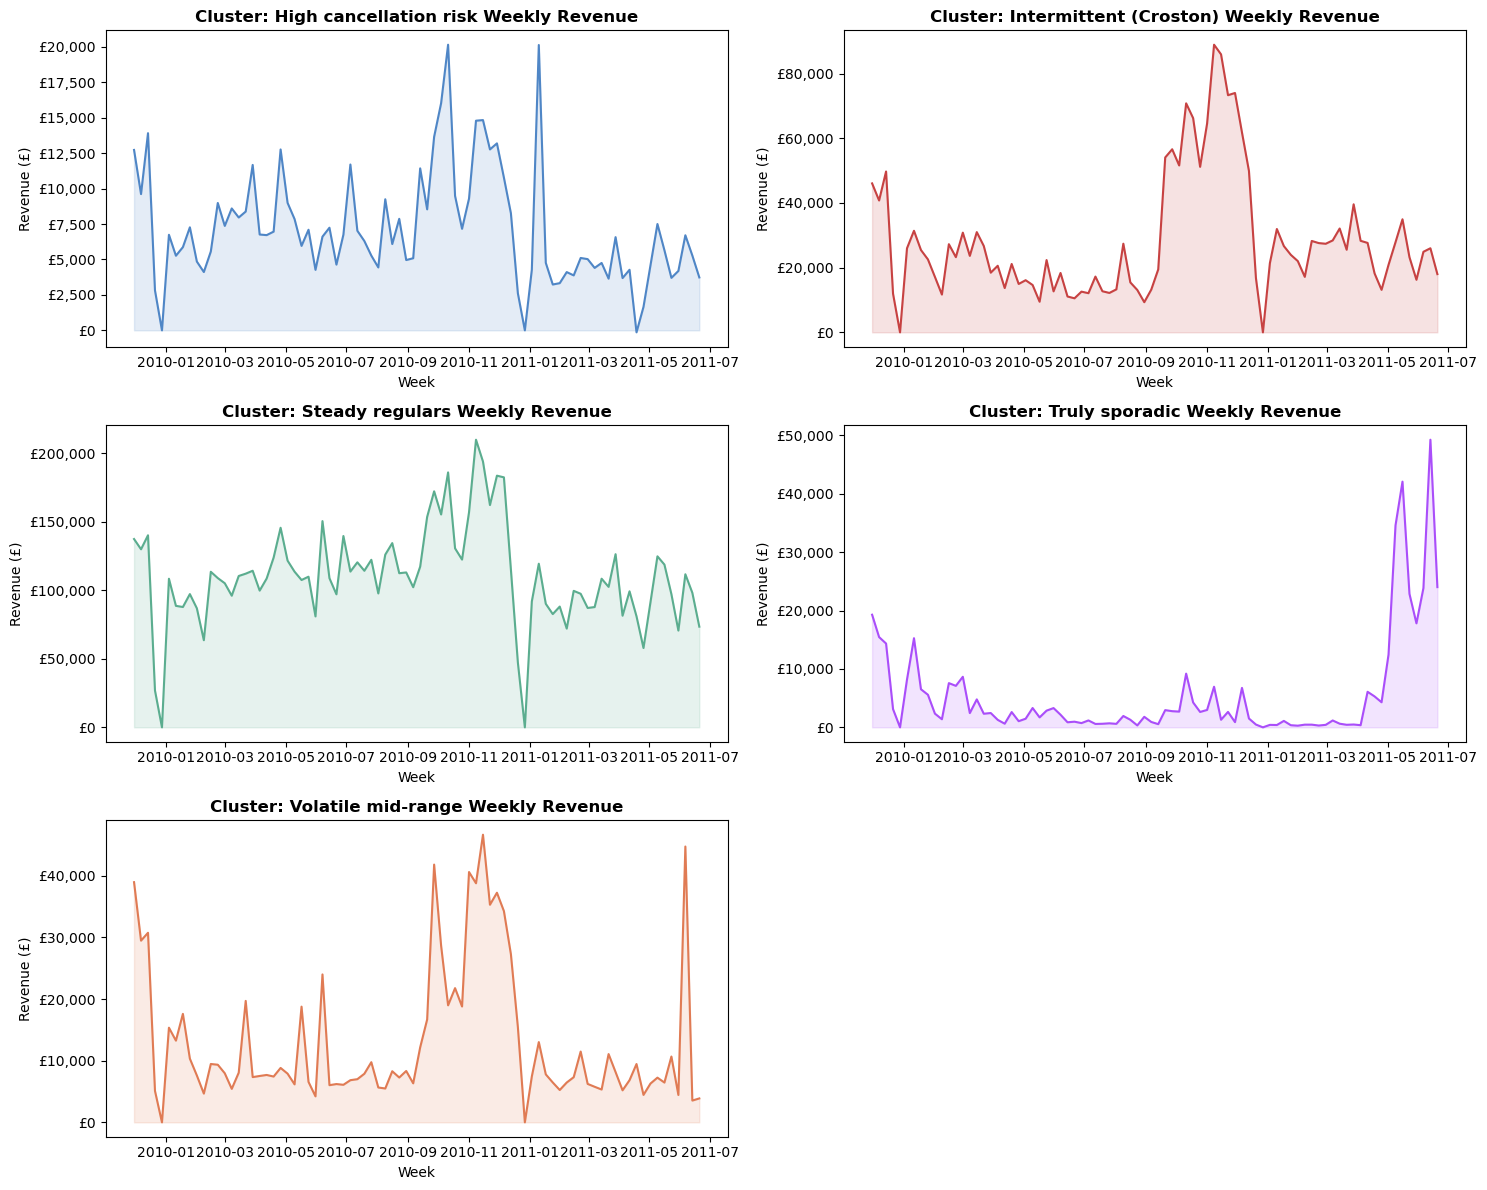

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Get cluster labels from the columns of weekly_sales_by_cluster
cluster_labels = weekly_sales_by_cluster.columns.tolist()

# Map cluster names to their integer IDs using LABEL_MAP
# LABEL_MAP: {0.0: 'High cancellation risk', 1.0: 'Volatile mid-range', 2.0: 'Steady regulars', -1: 'Intermittent (Croston)', -2: 'Truly sporadic'}
# PALETTE: {0: '#4F86C6', 1: '#E07B54', 2: '#5BAD8F', 3: '#C97EB8', -1: '#C74242', -2: '#AA4EFA'}
label_to_id_map = {v: k for k, v in LABEL_MAP.items()}

# Determine the number of subplots needed
num_clusters = len(cluster_labels)
n_cols = 2 # Number of columns for the subplots
n_rows = (num_clusters + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows)) # Adjust figure size dynamically

# Flatten axes array for easy iteration, handles cases like 1x1 or Nx1 grids
axes = axes.flatten()

# Iterate through each cluster's sales data and plot
for i, cluster_name in enumerate(cluster_labels):
    ax = axes[i]
    cluster_id = label_to_id_map.get(cluster_name)
    plot_color = PALETTE.get(cluster_id, '#808080') # Default to grey if cluster_id not found in PALETTE

    weekly_data = weekly_sales_by_cluster[cluster_name]
    # Convert PeriodIndex to Timestamp for plotting on x-axis
    dates = weekly_data.index.to_timestamp()

    ax.plot(dates, weekly_data.values, color=plot_color, linewidth=1.5)
    ax.fill_between(dates, weekly_data.values, alpha=0.15, color=plot_color)
    ax.set_title(f'Cluster: {cluster_name} Weekly Revenue', fontsize=12, fontweight='bold')
    ax.set_ylabel('Revenue (£)')
    ax.set_xlabel('Week')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Hide any unused subplots if num_clusters is odd and n_cols is even
for j in range(num_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('overall_shape_weekly_revenue.png')
plt.show()


### Weekly Sales Distribution

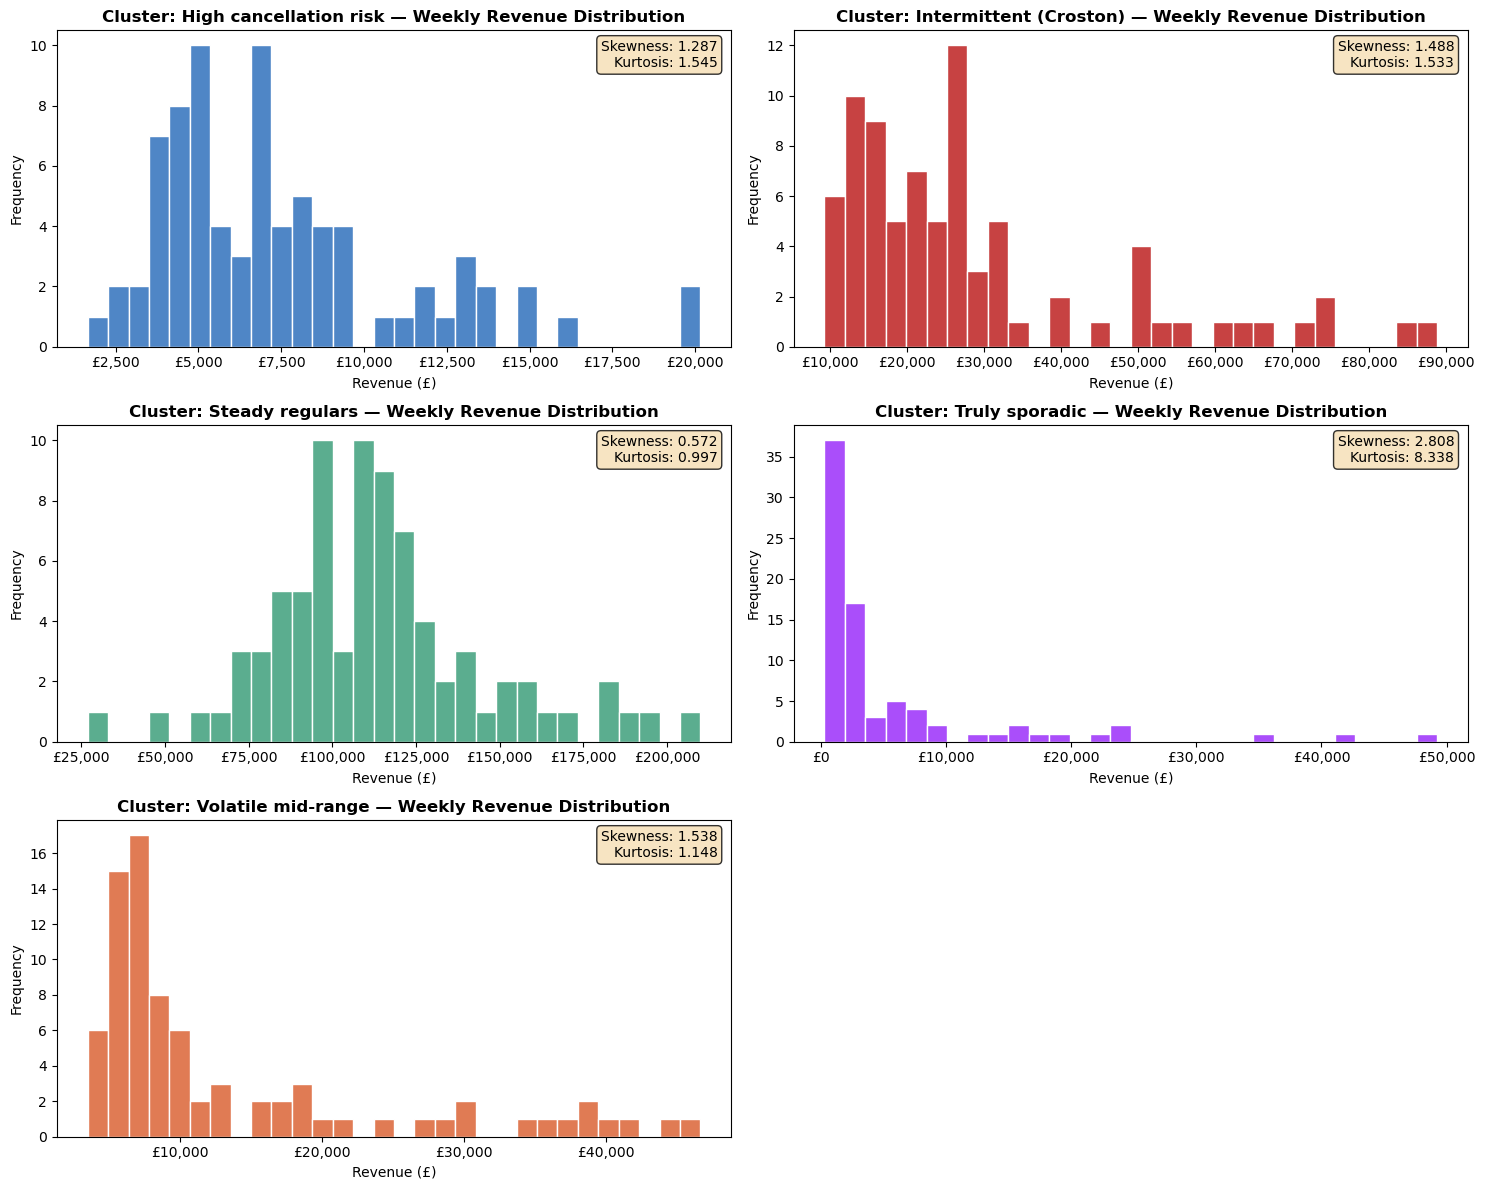

In [43]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Get cluster labels from the columns of weekly_sales_by_cluster
cluster_names = weekly_sales_by_cluster.columns.tolist()

# Map cluster names to their integer IDs for color mapping
label_to_id_map = {v: k for k, v in LABEL_MAP.items()}

# Determine the number of subplots needed
num_clusters = len(cluster_names)
n_cols = 2 # Number of columns for the subplots
n_rows = (num_clusters + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, cluster_name in enumerate(cluster_names):
    ax = axes[i]
    cluster_id = label_to_id_map.get(cluster_name)
    plot_color = PALETTE.get(cluster_id, '#808080') # Default to grey

    # Only positive weeks (since log / distribution focus)
    cluster_sales_stats = weekly_sales_by_cluster[cluster_name][weekly_sales_by_cluster[cluster_name] > 0]

    if not cluster_sales_stats.empty:
        # Histogram
        ax.hist(cluster_sales_stats, bins=30, color=plot_color, edgecolor='white')
        ax.set_title(f'Cluster: {cluster_name} — Weekly Revenue Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel('Revenue (£)')
        ax.set_ylabel('Frequency')
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
        )

        # Add stats annotations to plots
        skew = stats.skew(cluster_sales_stats)
        kurt = stats.kurtosis(cluster_sales_stats)
        ax.text(0.98, 0.97, f'Skewness: {skew:.3f}\nKurtosis: {kurt:.3f}',
                   transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=10)
    else:
        ax.set_title(f'Cluster: {cluster_name} — No Positive Sales Data', fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'No sales > 0 to plot distribution', transform=ax.transAxes, ha='center', va='center', fontsize=10, color='gray')

# Hide any unused subplots
for j in range(num_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('weekly_sales_distribution.png')
plt.show()

### Autocorrelation Plot and Power Spectral Density

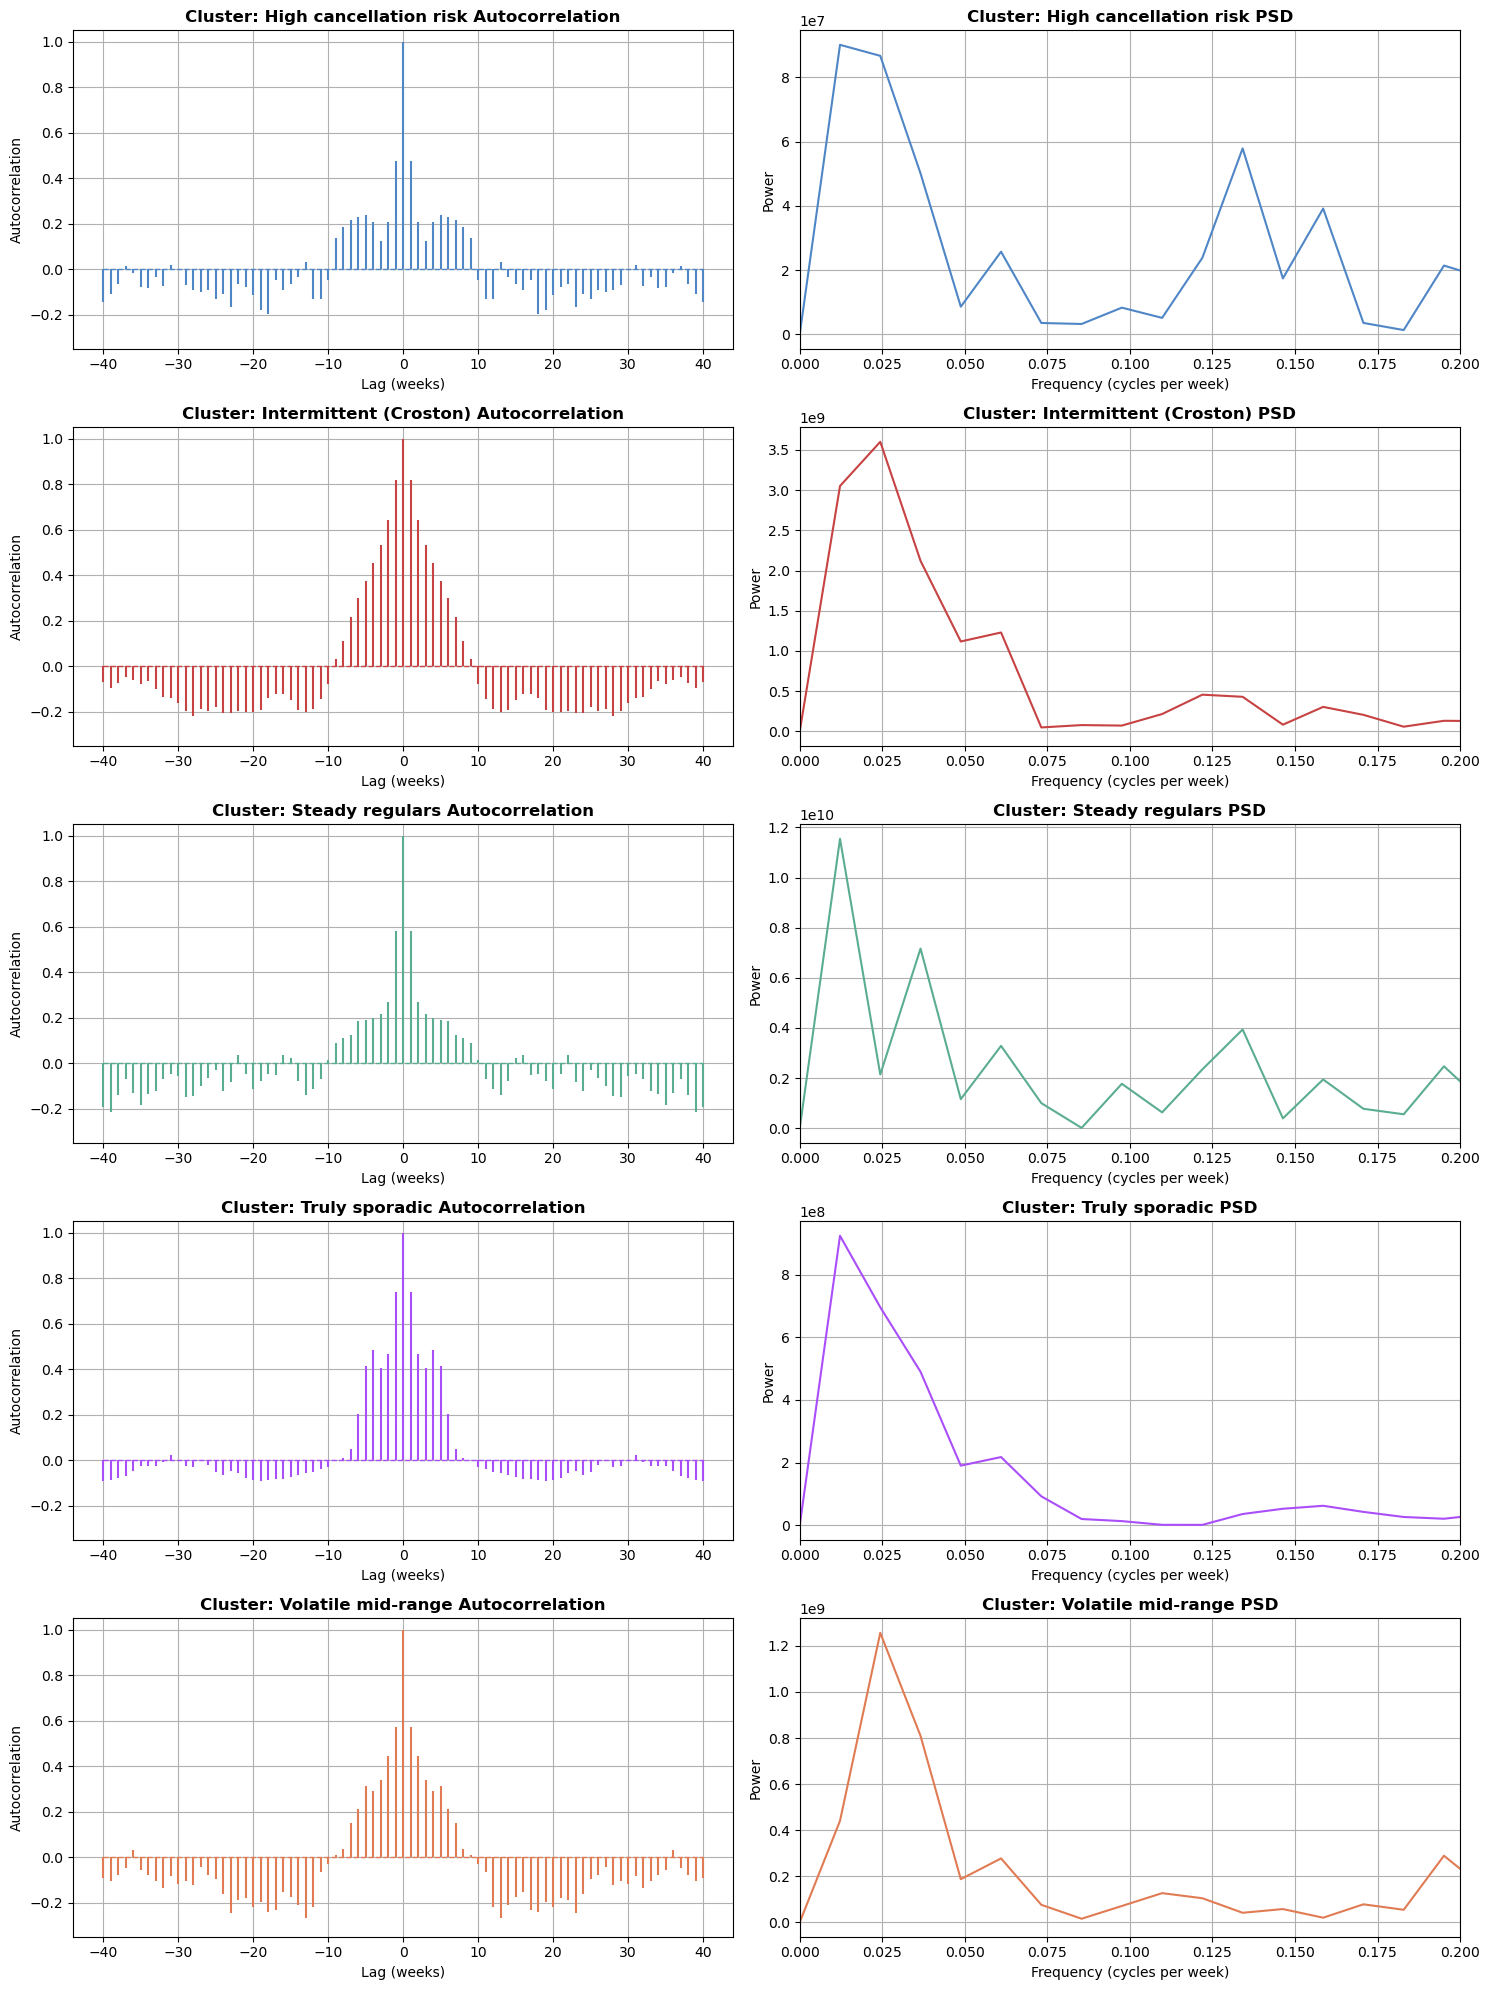

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Get cluster labels from the columns of weekly_sales_by_cluster
cluster_names = weekly_sales_by_cluster.columns.tolist()

# Map cluster names to their integer IDs for color mapping
label_to_id_map = {v: k for k, v in LABEL_MAP.items()}

# Determine the number of subplots needed (2 plots per cluster: Autocorrelation and PSD)
num_clusters = len(cluster_names)
n_cols_per_cluster = 2
n_rows = num_clusters # Each cluster gets one row with two plots

fig, axes = plt.subplots(n_rows, n_cols_per_cluster, figsize=(15, 4 * n_rows))

# Ensure axes is always a 2D array for consistent indexing
if num_clusters == 1:
    axes = np.expand_dims(axes, axis=0)

for i, cluster_name in enumerate(cluster_names):
    cluster_id = label_to_id_map.get(cluster_name)
    plot_color = PALETTE.get(cluster_id, '#808080') # Default to grey

    # Use weekly revenue data for the current cluster
    weekly_data = weekly_sales_by_cluster[cluster_name].values.astype(float)

    # Only consider positive sales for statistical analysis if relevant, otherwise use all
    # For Autocorrelation and PSD, using all data (including zeros) is generally fine,
    # as they capture patterns across the entire series.
    x = weekly_data

    # Detrend the data by subtracting the mean for autocorrelation and PSD
    x = x - np.mean(x)

    max_lag = min(60, len(x) // 2 -1) # Limit max_lag to avoid issues with short series
    if max_lag <= 0:
        # Skip plotting if data is too short for meaningful analysis
        axes[i, 0].set_title(f'Cluster: {cluster_name} - Autocorrelation (N/A)')
        axes[i, 1].set_title(f'Cluster: {cluster_name} - PSD (N/A)')
        continue

    n = len(x)

    # Compute autocorrelation
    r = np.correlate(x, x, mode='full')
    mid = n - 1

    lags = np.arange(-max_lag, max_lag + 1)
    r_lags = r[mid - max_lag : mid + max_lag + 1]
    # Avoid division by zero if r[mid] is 0
    r_lags = r_lags / r[mid] if r[mid] != 0 else np.zeros_like(r_lags)

    # Plot autocorrelation (bar-style stem)
    # Fix: Separating color from line style in basefmt
    markerline, stemlines, baseline = axes[i, 0].stem(lags, r_lags, linefmt=plot_color, markerfmt=' ', basefmt='--')
    plt.setp(markerline, visible=False)   # remove dots
    plt.setp(baseline, color=plot_color, linewidth=1, linestyle='--')

    axes[i, 0].set_title(f'Cluster: {cluster_name} Autocorrelation', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Lag (weeks)')
    axes[i, 0].set_ylabel('Autocorrelation')
    axes[i, 0].set_ylim(-0.35, 1.05)
    axes[i, 0].grid(True)

    # FFT-based periodogram (PSD)
    # Check if data length is sufficient for FFT
    if n > 0:
        X_fft = np.fft.rfft(x)
        Pxx = (np.abs(X_fft) ** 2) / n
        f = np.fft.rfftfreq(n, d=1.0)  # cycles per week

        axes[i, 1].plot(f, Pxx, label="PSD", color=plot_color, linewidth=1.5)

        # Zoom into low-frequency region
        axes[i, 1].set_xlim(0, 0.2) # Typically interested in cycles longer than 5 weeks

        axes[i, 1].set_title(f'Cluster: {cluster_name} PSD', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('Frequency (cycles per week)')
        axes[i, 1].set_ylabel('Power')
        axes[i, 1].grid(True)
    else:
        axes[i, 1].set_title(f'Cluster: {cluster_name} - PSD (N/A)')

plt.tight_layout()
plt.savefig('autocorrelation_and_psd.png')
plt.show()

# Data Transformation

In [45]:
from itertools import product as iterproduct

# ─────────────────────────────────────────────────────────────────────────────
# ASSUMPTIONS / INPUTS EXPECTED FROM PRIOR STEPS
#
#   retail_train   : raw training transactions (from your train/test split)
#   retail_test    : raw test transactions
#   feat_df_all    : full feature table with columns:
#                      cluster (-2=sporadic, -1=croston, 0..k active)
#                      cluster_label
#                      all feature columns (cv, q4_pct, etc.)
#   CLUSTERING_COLS: list of feature column names used in clustering
#   all_weeks      : full pd.PeriodRange covering the dataset
#   training_weeks : PeriodRange for train split
#   test_weeks     : PeriodRange for test split (last 12 weeks)
#
# ─────────────────────────────────────────────────────────────────────────────

# ── 0. Shared config ──────────────────────────────────────────────────────────

# Static product features to carry into every panel row
# These come from feat_df_all — add/remove as needed
PRODUCT_FEATURE_COLS = [
    "cv",
    "pct_zero_weeks",
    "q4_pct",
    "q1_pct",
    "seasonal_conc",
    "log_mean_weekly_sales",
    "log_mean_price",
    "n_unique_customers",
    "cancel_rate",
    "trend_log_diff",
]

# Lag windows (in weeks) to compute for each product
LAG_WINDOWS       = [1, 2, 4, 8, 13, 26, 52]
ROLL_WINDOWS      = [4, 8, 13, 26]

# ── 1. Aggregate raw transactions → weekly sales per product ──────────────────

def make_weekly_actuals(transactions):
    """
    Aggregate raw transaction rows to weekly revenue per StockCode.
    Returns a long dataframe: StockCode | week (Period) | sales
    """
    df = transactions.copy()
    df["week"] = df["InvoiceDate"].dt.to_period("W")

    weekly = (
        df.groupby(["StockCode", "week"])["Sales"]
        .sum()
        .reset_index()
        .rename(columns={"Sales": "sales"})
    )
    return weekly


# ── 2. Calendar feature builder ───────────────────────────────────────────────

def _weeks_to_christmas(ts):
    """Weeks remaining until Christmas, capped at 26."""
    xmas = pd.Timestamp(f"{ts.year}-12-25")
    diff = (xmas - ts).days / 7
    if diff < 0:
        xmas = pd.Timestamp(f"{ts.year + 1}-12-25")
        diff = (xmas - ts).days / 7
    return round(min(26, max(0, diff)), 2)


def _easter_weeks(years):
    """Return set of week-start dates that contain Easter (Good Fri - Mon)."""
    try:
        import holidays
        easter_dates = set()
        for year in years:
            uk = holidays.UK(years=year)
            for d, name in uk.items():
                if "Easter" in name:
                    # include the full week around Easter
                    ts = pd.Timestamp(d)
                    for offset in range(-3, 4):
                        easter_dates.add((ts + pd.Timedelta(days=offset)).date())
        return easter_dates
    except ImportError:
        return set()


def add_calendar_features(df, date_col="week_start"):
    """
    df must have a column `date_col` of pd.Timestamp (week start date).
    Adds all calendar features in-place and returns df.
    """
    dates = df[date_col]

    df["week_of_year"]      = dates.dt.isocalendar().week.astype(int)
    df["month"]             = dates.dt.month
    df["quarter"]           = dates.dt.quarter
    df["year"]              = dates.dt.year

    # Smooth cyclical encodings — prevent model treating wk52 and wk1 as far apart
    df["sin_week"]          = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["cos_week"]          = np.cos(2 * np.pi * df["week_of_year"] / 52)
    df["sin_month"]         = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"]         = np.cos(2 * np.pi * df["month"] / 12)

    # Retail calendar flags
    df["is_christmas_week"] = df["week_of_year"].isin([51, 52]).astype(int)
    df["is_peak_season"]    = (df["week_of_year"] >= 44).astype(int)
    df["weeks_to_christmas"]= dates.apply(_weeks_to_christmas)

    # Q1 occasion flags (Valentine's / Easter)
    df["is_valentines"]     = (
        (df["month"] == 2) & (dates.dt.day <= 14)
    ).astype(int)

    easter_dates = _easter_weeks(dates.dt.year.unique())
    if easter_dates:
        df["is_easter"] = dates.apply(
            lambda d: int(d.date() in easter_dates)
        )
    else:
        df["is_easter"] = 0

    return df


# ── 3. Build the product × week spine ────────────────────────────────────────

def build_spine(stock_codes, week_range):
    weeks_list = list(week_range)
    rows = list(iterproduct(stock_codes, weeks_list))
    spine = pd.DataFrame(rows, columns=["StockCode", "week"])
    spine["week_start"] = spine["week"].apply(lambda p: p.start_time.normalize())
    # week_key used for reliable string-based .isin() matching
    spine["week_key"]   = spine["week_start"].dt.strftime("%Y-%m-%d")
    return spine


# ── 4. Attach actuals and product features ────────────────────────────────────

def attach_actuals(spine, weekly_actuals):
    """
    Left-join actual weekly sales onto spine.
    Missing weeks (no sales) → 0.
    """
    panel = spine.merge(weekly_actuals, on=["StockCode", "week"], how="left")
    panel["sales"] = panel["sales"].fillna(0.0)
    return panel


def attach_product_features(panel, feat_df, feature_cols):
    """
    Merge static product-level features from feat_df.
    These are constant across all weeks for a given product.
    """
    prod_feats = (
        feat_df[feature_cols]
        .reset_index()                    # StockCode becomes a column
        .rename(columns={"index": "StockCode"})
    )
    # feat_df index is StockCode
    prod_feats = feat_df[feature_cols].copy()
    prod_feats.index.name = "StockCode"
    prod_feats = prod_feats.reset_index()

    panel = panel.merge(prod_feats, on="StockCode", how="left")
    return panel


# ── 5. Lag and rolling features ───────────────────────────────────────────────

def add_lag_features(panel, lag_windows=LAG_WINDOWS, roll_windows=ROLL_WINDOWS):
    """
    Compute per-product lags and rolling means.
    IMPORTANT: all lags use shift(n) so they reference strictly past data.
    Panel must be sorted by StockCode, week before calling.
    """
    df = panel.sort_values(["StockCode", "week"]).copy()
    grp = df.groupby("StockCode")["sales"]

    for lag in lag_windows:
        df[f"lag_{lag}w"] = grp.shift(lag)

    for window in roll_windows:
        # shift(1) before rolling ensures we never include the current week
        df[f"roll_mean_{window}w"] = (
            grp.transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )

    # Same-week last year rolling average — strong seasonal anchor
    df["lag_52w_roll4"] = (
        grp.transform(lambda x: x.shift(52).rolling(4, min_periods=1).mean())
    )

    # Short trend: recent 4-week mean minus prior 4-week mean
    df["short_trend"] = (
        grp.transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
        - grp.transform(lambda x: x.shift(5).rolling(4, min_periods=1).mean())
    )

    return df


# ── 6. Master panel builder per cluster ──────────────────────────────────────

def build_cluster_panel(
    cluster_id,
    feat_df_all,
    retail_train,
    retail_test,
    training_weeks,
    test_weeks,
    all_weeks,
    product_feature_cols=PRODUCT_FEATURE_COLS,
    min_lag_for_training=52,    # drop rows where lag_52w is NaN
):
    """
    Builds train and test panels for a single cluster.

    Returns
    -------
    train_panel : pd.DataFrame — rows with full lag history, target = sales
    test_panel  : pd.DataFrame — future rows for evaluation / forecasting
    feature_cols: list[str]    — column names to pass as model features (X)
    """
    cluster_products = feat_df_all[feat_df_all["cluster"] == cluster_id].index.tolist()
    n = len(cluster_products)
    label = feat_df_all[feat_df_all["cluster"] == cluster_id]["cluster_label"].iloc[0]
    print(f"\n── Cluster {cluster_id}: '{label}'  ({n} products) ──")

    if n == 0:
        print("  No products — skipping.")
        return None, None, None

    # ── a. Weekly actuals from training transactions only ─────────────────────
    # We build the actuals from training data; test period rows get sales=0
    # and are used at inference time (lags computed from history buffer)
    train_actuals = make_weekly_actuals(
        retail_train[retail_train["StockCode"].isin(cluster_products)]
    )

    # ── b. Build spine covering ALL weeks (train + test) ──────────────────────
    # We need test weeks in the spine so lags from history can be attached
    full_spine = build_spine(cluster_products, all_weeks)

    # ── c. Attach actuals — test weeks will be 0 (unknown) ───────────────────
    panel = attach_actuals(full_spine, train_actuals)

    # ── d. Calendar features ──────────────────────────────────────────────────
    panel = add_calendar_features(panel, date_col="week_start")

    # ── e. Product (static) features ──────────────────────────────────────────
    available_feat_cols = [c for c in product_feature_cols if c in feat_df_all.columns]
    panel = attach_product_features(panel, feat_df_all, available_feat_cols)

    # ── f. Lag features (computed across full timeline so test rows get lags) ─
    panel = add_lag_features(panel)

    # ── g. Split into train / test ────────────────────────────────────────────────
    training_keys = set(pd.Period(w, freq="W").start_time.strftime("%Y-%m-%d")
                        for w in training_weeks)
    test_keys     = set(pd.Period(w, freq="W").start_time.strftime("%Y-%m-%d")
                        for w in test_weeks)

    train_mask = panel["week_key"].isin(training_keys)
    test_mask  = panel["week_key"].isin(test_keys)

    train_panel = panel[train_mask].copy()
    test_panel  = panel[test_mask].copy()

    # ── h. Drop training rows where lag_52w is NaN ───────────────────────────
    # These are the first 52 weeks where we have no year-ago anchor.
    # Keeping them would force the model to learn from incomplete lag sets.
    before = len(train_panel)
    train_panel = train_panel.dropna(subset=["lag_52w"])
    after  = len(train_panel)
    print(f"  Dropped {before - after} train rows (lag_52w NaN) — {after} remain")

    # ── i. Identify feature columns ───────────────────────────────────────────
    exclude = {"StockCode", "week", "week_start", "week_key", "sales",
               "cluster", "cluster_label", "is_sporadic",
               "is_croston", "is_active"}
    feature_cols = [c for c in train_panel.columns if c not in exclude]

    print(f"  Train rows : {len(train_panel):,}  |  "
          f"Test rows : {len(test_panel):,}  |  "
          f"Features : {len(feature_cols)}")

    # At the end of build_cluster_panel, confirm train_panel
    # is the post-drop version before returning
    print(f"  Returning train_panel with {len(train_panel)} rows (post lag_52w drop)")
    return train_panel, test_panel, feature_cols


# ── 7. Run for all clusters ───────────────────────────────────────────────────

def build_all_panels(
    feat_df_all,
    retail_train,
    retail_test,
    training_weeks,
    test_weeks,
    all_weeks,
    product_feature_cols=PRODUCT_FEATURE_COLS,
):
    """
    Iterates over every unique cluster id in feat_df_all and builds panels.

    Returns
    -------
    panels : dict mapping cluster_id ->
                 {"train": df, "test": df, "features": list[str], "label": str}
    """
    cluster_ids = sorted(feat_df_all["cluster"].unique())
    panels = {}

    for cid in cluster_ids:
        label = feat_df_all[feat_df_all["cluster"] == cid]["cluster_label"].iloc[0]
        train_panel, test_panel, feature_cols = build_cluster_panel(
            cluster_id          = cid,
            feat_df_all         = feat_df_all,
            retail_train        = retail_train,
            retail_test         = retail_test,
            training_weeks      = training_weeks,
            test_weeks          = test_weeks,
            all_weeks           = all_weeks,
            product_feature_cols= product_feature_cols,
        )

        if train_panel is not None:
            panels[cid] = {
                "train"   : train_panel,
                "test"    : test_panel,
                "features": feature_cols,
                "label"   : label,
            }

    return panels


# ── 8. Entry point ────────────────────────────────────────────────────────────
# Build panels for every cluster
panels = build_all_panels(
    feat_df_all    = feat_df_all,
    retail_train   = retail_train,
    retail_test    = retail_test,
    training_weeks = training_weeks,
    test_weeks     = test_weeks,
    all_weeks      = all_weeks,
)

# Quick summary
print("\n── Panel summary ────────────────────────────────────────────────")
for cid, p in panels.items():
    print(
        f"  Cluster {cid:>2} | {p['label']:<30} | "
        f"train={len(p['train']):>7,} rows | "
        f"test={len(p['test']):>6,} rows | "
        f"{len(p['features'])} features"
    )

# Access individual cluster panels like this:
#
#   train      = panels[0]["train"]
#   test       = panels[0]["test"]
#   feat_cols  = panels[0]["features"]
#
#   X_train    = train[feat_cols]
#   y_train    = train["sales"]
#
#   X_test     = test[feat_cols]
#   y_test     = test["sales"]   # actuals for evaluation
#
# Croston / sporadic clusters (cluster -1, -2) also get panels built
# but you won't train LightGBM on them — use Croston's method instead.
# Their panels are still useful for holding the lag history needed
# by the recursive forecaster.

print("\nDone. All panels ready.")


── Cluster -2.0: 'Truly sporadic'  (1328 products) ──
  Dropped 69056 train rows (lag_52w NaN) — 39840 remain
  Train rows : 39,840  |  Test rows : 15,936  |  Features : 36
  Returning train_panel with 39840 rows (post lag_52w drop)

── Cluster -1.0: 'Intermittent (Croston)'  (1627 products) ──
  Dropped 84604 train rows (lag_52w NaN) — 48810 remain
  Train rows : 48,810  |  Test rows : 19,524  |  Features : 36
  Returning train_panel with 48810 rows (post lag_52w drop)

── Cluster 0.0: 'High cancellation risk'  (92 products) ──
  Dropped 4784 train rows (lag_52w NaN) — 2760 remain
  Train rows : 2,760  |  Test rows : 1,104  |  Features : 36
  Returning train_panel with 2760 rows (post lag_52w drop)

── Cluster 1.0: 'Volatile mid-range'  (228 products) ──
  Dropped 11856 train rows (lag_52w NaN) — 6840 remain
  Train rows : 6,840  |  Test rows : 2,736  |  Features : 36
  Returning train_panel with 6840 rows (post lag_52w drop)

── Cluster 2.0: 'Steady regulars'  (1281 products) ──
  D

In [46]:
# Rebuild panels while keeping negative weekly sales (returns/cancellations)
def make_weekly_actuals(transactions, drop_cancellations=False):
    df = transactions.copy()
    if drop_cancellations and "Invoice" in df.columns:
        df = df[~df["Invoice"].astype(str).str.startswith("C")].copy()
    df["week"] = df["InvoiceDate"].dt.to_period("W")
    weekly = (
        df.groupby(["StockCode", "week"])["Sales"]
        .sum()
        .reset_index()
        .rename(columns={"Sales": "sales"})
    )
    return weekly

panels = build_all_panels(
    feat_df_all=feat_df_all,
    retail_train=retail_train,
    retail_test=retail_test,
    training_weeks=training_weeks,
    test_weeks=test_weeks,
    all_weeks=all_weeks,
    product_feature_cols=PRODUCT_FEATURE_COLS,
)

# IMPORTANT: attach TRUE test labels and recompute lag/rolling features
# over full train+test timeline for rolling one-step evaluation
test_week_set = set(test_weeks)
for cid, p in panels.items():
    cluster_products = feat_df_all[feat_df_all["cluster"] == cid].index.tolist()
    test_actuals = make_weekly_actuals(
        retail_test[retail_test["StockCode"].isin(cluster_products)],
        drop_cancellations=False,
    )

    test_panel = p["test"].merge(
        test_actuals,
        on=["StockCode", "week"],
        how="left",
        suffixes=("", "_true"),
    )
    test_panel["sales"] = test_panel["sales_true"].fillna(0.0)
    test_panel = test_panel.drop(columns=["sales_true"])

    full_panel = pd.concat([p["train"], test_panel], ignore_index=True, sort=False)
    full_panel = add_lag_features(full_panel)

    test_recomputed = full_panel[full_panel["week"].isin(test_week_set)].copy()
    keep_cols = ["StockCode", "week", "sales"] + p["features"]
    p["test"] = test_recomputed[keep_cols].copy()

print("Rebuilt panels with true test labels and refreshed lag features for rolling evaluation.")


── Cluster -2.0: 'Truly sporadic'  (1328 products) ──
  Dropped 69056 train rows (lag_52w NaN) — 39840 remain
  Train rows : 39,840  |  Test rows : 15,936  |  Features : 36
  Returning train_panel with 39840 rows (post lag_52w drop)

── Cluster -1.0: 'Intermittent (Croston)'  (1627 products) ──
  Dropped 84604 train rows (lag_52w NaN) — 48810 remain
  Train rows : 48,810  |  Test rows : 19,524  |  Features : 36
  Returning train_panel with 48810 rows (post lag_52w drop)

── Cluster 0.0: 'High cancellation risk'  (92 products) ──
  Dropped 4784 train rows (lag_52w NaN) — 2760 remain
  Train rows : 2,760  |  Test rows : 1,104  |  Features : 36
  Returning train_panel with 2760 rows (post lag_52w drop)

── Cluster 1.0: 'Volatile mid-range'  (228 products) ──
  Dropped 11856 train rows (lag_52w NaN) — 6840 remain
  Train rows : 6,840  |  Test rows : 2,736  |  Features : 36
  Returning train_panel with 6840 rows (post lag_52w drop)

── Cluster 2.0: 'Steady regulars'  (1281 products) ──
  D

In [47]:
test_start_times = [w.start_time.strftime("%Y-%m-%d") for w in test_weeks]
print("Test weeks start times:", test_start_times)
print("All weeks start times (last 15):", [w.start_time.strftime("%Y-%m-%d") for w in all_weeks][-15:])

# build a dummy spine
sample_spine = build_spine(["1234"], all_weeks)
print("Spine week keys (last 15):", sample_spine["week_key"].unique()[-15:])


Test weeks start times: ['2011-09-19', '2011-09-26', '2011-10-03', '2011-10-10', '2011-10-17', '2011-10-24', '2011-10-31', '2011-11-07', '2011-11-14', '2011-11-21', '2011-11-28', '2011-12-05']
All weeks start times (last 15): ['2011-08-29', '2011-09-05', '2011-09-12', '2011-09-19', '2011-09-26', '2011-10-03', '2011-10-10', '2011-10-17', '2011-10-24', '2011-10-31', '2011-11-07', '2011-11-14', '2011-11-21', '2011-11-28', '2011-12-05']
Spine week keys (last 15): <StringArray>
['2011-08-29', '2011-09-05', '2011-09-12', '2011-09-19', '2011-09-26',
 '2011-10-03', '2011-10-10', '2011-10-17', '2011-10-24', '2011-10-31',
 '2011-11-07', '2011-11-14', '2011-11-21', '2011-11-28', '2011-12-05']
Length: 15, dtype: str


In [48]:
# # Select cluster here
# # {-2: Truly Sporadic, -1: Intermittent(Croston), 0: High Cancellation Risk, 1: Steady Regulars, 2: Volatile Mid-range}
# CLUSTER = 0

# train      = panels[CLUSTER]["train"]
# test       = panels[CLUSTER]["test"]
# feat_cols  = panels[CLUSTER]["features"]

# X_train    = train[feat_cols]
# y_train    = train["sales"]

# X_test     = test[feat_cols]
# y_test     = test["sales"]
# import lightgbm as lgb
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # =========================
# # Helper: MAPE (0-100)
# # =========================
# def mape_100(y_true, y_pred, eps=1e-6):
#     y_true = np.asarray(y_true, dtype=float)
#     y_pred = np.asarray(y_pred, dtype=float)
#     denom = np.maximum(np.abs(y_true), eps)
#     return np.mean(np.abs((y_true - y_pred) / denom)) * 100

# # =========================
# # 1) Train/Test only
# # =========================
# train = train.sort_values(["week", "StockCode"]).copy()
# test  = test.sort_values(["week", "StockCode"]).copy()

# X_train, y_train = train[feat_cols], train["sales"]
# X_test, y_test = test[feat_cols], test["sales"]

# print("Split sizes:")
# print(f"  Train rows: {len(train):,}")
# print(f"  Test rows : {len(test):,}")

# # =========================
# # 2) Train model (no validation, no test leakage)
# # =========================
# model = lgb.LGBMRegressor(
#     objective='regression',
#     n_estimators=300,
#     learning_rate=0.05,
#     num_leaves=31,
#     random_state=42,
#     n_jobs=-1
# )

# print("Start training LightGBM...")
# model.fit(X_train, y_train)

# # =========================
# # 3) Report TEST MAPE only
# # =========================
# y_pred_test = model.predict(X_test)
# test_mape = mape_100(y_test, y_pred_test)
# print(f"\nOverall TEST MAPE (0-100): {test_mape:.2f}%")

# # =========================================================
# # 4) Split TEST into 4 equal time regions, report MAPE each
# # =========================================================
# N_REGIONS = 4
# test_eval = test.copy()
# test_eval["y_true"] = y_test.values
# test_eval["y_pred"] = y_pred_test
# test_eval["ape_pct"] = np.abs((test_eval["y_true"] - test_eval["y_pred"]) / np.maximum(np.abs(test_eval["y_true"]), 1e-6)) * 100

# test_weeks_sorted = np.array(sorted(test_eval["week"].unique()))
# week_regions = np.array_split(test_weeks_sorted, N_REGIONS)

# region_labels = []
# region_mapes = []
# box_data = []

# for i, region_weeks in enumerate(week_regions, start=1):
#     region_df = test_eval[test_eval["week"].isin(region_weeks)].copy()
#     region_label = f"R{i}: {region_weeks[0]} to {region_weeks[-1]}"
#     region_mape = mape_100(region_df["y_true"], region_df["y_pred"])

#     region_labels.append(region_label)
#     region_mapes.append(region_mape)
#     box_data.append(region_df["ape_pct"].values)

# summary = pd.DataFrame({
#     "region": region_labels,
#     "test_mape_0_100": np.round(region_mapes, 2),
# })

# print("\nTEST MAPE by equal time region (0-100):")
# print(summary.to_string(index=False))

# # ===============================================
# # 5) Box plot of test error spread (APE %)
# # ===============================================
# plt.figure(figsize=(10, 5))
# plt.boxplot(box_data, labels=[f"R{i}" for i in range(1, N_REGIONS + 1)], showfliers=True)
# plt.title("Test Absolute Percentage Error (APE%) by Time Region")
# plt.xlabel("Equal test time regions")
# plt.ylabel("APE (%)")
# plt.grid(axis="y", alpha=0.25)
# plt.show()

# # Optional: feature importance
# lgb.plot_importance(model, max_num_features=15, importance_type='gain', figsize=(8, 6))
# plt.show()

In [74]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from itertools import product as iterproduct


# =========================
# Helper: MAPE (0-100)
# =========================
def mape_100(y_true, y_pred, min_abs_actual=1.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) >= min_abs_actual
    if mask.sum() == 0:
        return np.nan, 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / np.abs(y_true[mask])) * 100
    return float(np.mean(ape)), int(mask.sum())


def signed_log1p(x):
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.log1p(np.abs(x))


def signed_expm1(x):
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.expm1(np.abs(x))


# =========================
# Croston-SBA for intermittent demand
# =========================
def croston_sba_forecast(y, alpha=0.1):
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        return 0.0

    y = np.clip(y, 0.0, None)
    nz_idx = np.flatnonzero(y > 0)
    if len(nz_idx) == 0:
        return 0.0

    z = y[nz_idx[0]]
    p = nz_idx[0] + 1
    last = nz_idx[0]

    for idx in nz_idx[1:]:
        demand = y[idx]
        interval = idx - last
        z = z + alpha * (demand - z)
        p = p + alpha * (interval - p)
        last = idx

    croston = z / p if p > 0 else 0.0
    sba = (1 - alpha / 2.0) * croston
    return float(max(0.0, sba))


def croston_predict_by_sku(train_df, test_df, alpha=0.1):
    train_sorted = train_df.sort_values(["StockCode", "week"]).copy()
    test_sorted = test_df.sort_values(["StockCode", "week"]).copy()

    sku_forecast = {}
    for sku, grp in train_sorted.groupby("StockCode"):
        sku_forecast[sku] = croston_sba_forecast(grp["sales"].values, alpha=alpha)

    cluster_mean = float(np.clip(train_sorted["sales"], 0, None).mean()) if len(train_sorted) else 0.0
    pred = test_sorted["StockCode"].map(sku_forecast).fillna(cluster_mean).values
    out = pd.Series(pred, index=test_sorted.index).reindex(test_df.index).values
    return out


# =========================
# Raw transaction lag features for two-stage intermittent model
# =========================
def build_weekly_raw_features(transactions):
    df = transactions.copy()
    df["week"] = df["InvoiceDate"].dt.to_period("W")

    df["is_cancel"] = False
    if "Invoice" in df.columns:
        df["is_cancel"] = df["Invoice"].astype(str).str.startswith("C")

    df["pos_sales"] = df["Sales"].clip(lower=0.0)
    df["neg_sales_abs"] = (-df["Sales"].clip(upper=0.0))

    agg = (
        df.groupby(["StockCode", "week"]).agg(
            txn_count=("Sales", "size"),
            customer_count=("CustomerID", "nunique"),
            avg_price=("Price", "mean"),
            gross_sales=("pos_sales", "sum"),
            return_sales_abs=("neg_sales_abs", "sum"),
            cancel_count=("is_cancel", "sum"),
        )
        .reset_index()
    )

    if "Invoice" in df.columns:
        inv = (
            df.groupby(["StockCode", "week"])["Invoice"]
            .nunique()
            .rename("invoice_count")
            .reset_index()
        )
        agg = agg.merge(inv, on=["StockCode", "week"], how="left")
    else:
        agg["invoice_count"] = agg["txn_count"]

    top_country = (
        df.groupby(["StockCode", "week"])["Country"]
        .apply(lambda s: float(s.value_counts(normalize=True).iloc[0]) if len(s) else 0.0)
        .rename("top_country_share")
        .reset_index()
    )
    agg = agg.merge(top_country, on=["StockCode", "week"], how="left")

    agg["avg_price"] = agg["avg_price"].fillna(0.0)
    agg["top_country_share"] = agg["top_country_share"].fillna(0.0)
    agg["invoice_count"] = agg["invoice_count"].fillna(0.0)

    denom = agg["gross_sales"] + agg["return_sales_abs"] + 1e-6
    agg["return_ratio"] = agg["return_sales_abs"] / denom

    return agg


def add_lagged_raw_features(raw_panel):
    df = raw_panel.sort_values(["StockCode", "week"]).copy()

    metric_cols = [
        "txn_count",
        "invoice_count",
        "customer_count",
        "avg_price",
        "gross_sales",
        "return_sales_abs",
        "cancel_count",
        "top_country_share",
        "return_ratio",
    ]

    lag_cols = []
    for col in metric_cols:
        grp = df.groupby("StockCode")[col]
        lag1 = f"{col}_lag1"
        roll4 = f"{col}_roll4"
        df[lag1] = grp.shift(1).fillna(0.0)
        df[roll4] = grp.transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0.0)
        lag_cols.extend([lag1, roll4])

    return df, lag_cols


def two_stage_rawlag_predict(cid, train_base, test_base, base_feat_cols):
    cluster_products = feat_df_all[feat_df_all["cluster"] == cid].index.tolist()
    tx_all = pd.concat([retail_train, retail_test], ignore_index=True)
    tx_all = tx_all[tx_all["StockCode"].isin(cluster_products)].copy()

    raw_weekly = build_weekly_raw_features(tx_all)

    spine = pd.DataFrame(
        list(iterproduct(cluster_products, list(all_weeks))),
        columns=["StockCode", "week"],
    )
    raw_panel = spine.merge(raw_weekly, on=["StockCode", "week"], how="left")

    fill_cols = [
        "txn_count", "invoice_count", "customer_count", "avg_price",
        "gross_sales", "return_sales_abs", "cancel_count", "top_country_share", "return_ratio"
    ]
    for col in fill_cols:
        raw_panel[col] = raw_panel[col].fillna(0.0)

    raw_panel, raw_lag_cols = add_lagged_raw_features(raw_panel)
    raw_for_join = raw_panel[["StockCode", "week"] + raw_lag_cols].copy()

    train = train_base.merge(raw_for_join, on=["StockCode", "week"], how="left")
    test = test_base.merge(raw_for_join, on=["StockCode", "week"], how="left")
    train[raw_lag_cols] = train[raw_lag_cols].fillna(0.0)
    test[raw_lag_cols] = test[raw_lag_cols].fillna(0.0)

    feat_cols = list(base_feat_cols) + raw_lag_cols
    X_train = train[feat_cols].fillna(0.0)
    X_test = test[feat_cols].fillna(0.0)

    y_train = train["sales"].values
    y_event = (y_train > 0).astype(int)

    if y_event.sum() < 20 or np.unique(y_event).size < 2:
        return croston_predict_by_sku(train_base, test_base, alpha=CROSTON_ALPHA), "TwoStageRawLag->Croston(fallback_events)"

    cls = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
    )
    cls.fit(X_train, y_event)

    amount_train = train[train["sales"] > 0].copy()
    if len(amount_train) < 30:
        return croston_predict_by_sku(train_base, test_base, alpha=CROSTON_ALPHA), "TwoStageRawLag->Croston(fallback_amount)"

    X_amt = amount_train[feat_cols].fillna(0.0)
    y_amt = np.log1p(amount_train["sales"].values)

    reg = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
    )
    reg.fit(X_amt, y_amt)

    p_sale = cls.predict_proba(X_test)[:, 1]
    amt_pred = np.expm1(reg.predict(X_test))
    amt_pred = np.clip(amt_pred, 0.0, None)

    cap = np.nanpercentile(amount_train["sales"].values, 99)
    if np.isfinite(cap) and cap > 0:
        amt_pred = np.clip(amt_pred, 0.0, cap * 3.0)

    y_pred = p_sale * amt_pred
    return y_pred, "TwoStageRawLag"


# =========================
# Residual correction (rolling-CV alpha)
# =========================
def fit_signedlog_model(train_df, feat_cols):
    X_train = train_df[feat_cols].fillna(0.0)
    y_train = train_df["sales"].values
    y_train_t = signed_log1p(y_train)

    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=40,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.2,
        reg_lambda=0.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(X_train, y_train_t)
    return model


def predict_signedlog_model(model, df, feat_cols):
    X = df[feat_cols].fillna(0.0)
    return signed_expm1(model.predict(X))


def fit_return_models(train_df, feat_cols):
    df = train_df.copy()
    df["return_amount"] = np.abs(np.minimum(df["sales"], 0.0))
    df["has_return"] = (df["return_amount"] > 0).astype(int)

    X = df[feat_cols].fillna(0.0)
    y_evt = df["has_return"].values

    if y_evt.sum() < 20 or np.unique(y_evt).size < 2:
        return {"status": "fallback_no_return_events", "cls": None, "reg": None}

    cls = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=25,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    cls.fit(X, y_evt)

    ret_rows = df[df["has_return"] == 1].copy()
    if len(ret_rows) < 30:
        return {"status": "fallback_low_return_amount_rows", "cls": cls, "reg": None}

    X_ret = ret_rows[feat_cols].fillna(0.0)
    y_ret = np.log1p(ret_rows["return_amount"].values)

    reg = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    reg.fit(X_ret, y_ret)

    return {"status": "ok", "cls": cls, "reg": reg}


def predict_expected_return(return_bundle, df, feat_cols):
    if return_bundle["cls"] is None:
        return np.zeros(len(df), dtype=float)

    X = df[feat_cols].fillna(0.0)
    p_ret = return_bundle["cls"].predict_proba(X)[:, 1]

    if return_bundle["reg"] is None:
        return np.zeros(len(df), dtype=float)

    ret_amt = np.expm1(return_bundle["reg"].predict(X))
    ret_amt = np.clip(ret_amt, 0.0, None)
    return p_ret * ret_amt


def residual_correction_predict_rolling(train_base, test_base, feat_cols, val_span=4):
    train_sorted = train_base.sort_values(["week", "StockCode"]).copy()
    all_train_weeks = np.array(sorted(train_sorted["week"].unique()))

    min_train_weeks = max(26, val_span * 2)
    fold_ends = list(range(min_train_weeks, len(all_train_weeks) - val_span + 1, val_span))
    if len(fold_ends) == 0:
        fold_ends = [len(all_train_weeks) - val_span]

    alpha_grid = np.linspace(0.0, 1.0, 11)
    rows = []

    for end_idx in fold_ends:
        fit_weeks = set(all_train_weeks[:end_idx])
        val_weeks = set(all_train_weeks[end_idx:end_idx + val_span])

        tr_fit = train_sorted[train_sorted["week"].isin(fit_weeks)].copy()
        tr_val = train_sorted[train_sorted["week"].isin(val_weeks)].copy()
        if len(tr_fit) == 0 or len(tr_val) == 0:
            continue

        base_model_fold = fit_signedlog_model(tr_fit, feat_cols)
        pred_val_base = predict_signedlog_model(base_model_fold, tr_val, feat_cols)

        ret_bundle_fold = fit_return_models(tr_fit, feat_cols)
        pred_val_ret = predict_expected_return(ret_bundle_fold, tr_val, feat_cols)

        for a in alpha_grid:
            pred_val = pred_val_base - a * pred_val_ret
            mape_a, used_n = mape_100(tr_val["sales"].values, pred_val, min_abs_actual=1.0)
            rows.append({"alpha": float(a), "mape": mape_a, "n": used_n})

    cv_df = pd.DataFrame(rows)
    cv_df = cv_df[(cv_df["n"] > 0) & np.isfinite(cv_df["mape"])].copy()

    if cv_df.empty:
        best_alpha = 0.0
    else:
        agg = cv_df.groupby("alpha").apply(lambda g: np.average(g["mape"], weights=g["n"]))
        agg = agg.reset_index(name="weighted_cv_mape").sort_values("weighted_cv_mape")
        best_alpha = float(agg.iloc[0]["alpha"])

    base_model_full = fit_signedlog_model(train_base, feat_cols)
    pred_test_base = predict_signedlog_model(base_model_full, test_base, feat_cols)

    ret_bundle_full = fit_return_models(train_base, feat_cols)
    pred_test_ret = predict_expected_return(ret_bundle_full, test_base, feat_cols)

    y_pred = pred_test_base - best_alpha * pred_test_ret
    return y_pred, best_alpha

## Intermittent Upgrade Experiment: Raw-Transaction + Two-Stage Model

This cell block tests a **safe, isolated** upgrade for intermittent clusters (`-2`, `-1`) without changing the main baseline cell.

Method:
1. Build weekly raw-transaction features from original records.
2. Use only lagged/rolling versions (no same-week leakage).
3. Train two-stage model per cluster:
   - Stage A: probability of sale (`sales > 0`)
   - Stage B: positive sales amount (`log1p` target)
   - Final forecast = `P(sale) × E(amount | sale)`
4. Compare against Croston-SBA on the same test split.

Intermittent clusters: Croston vs Raw-Enhanced Two-Stage
 cluster                  label baseline_model  baseline_mape_0_100      two_stage_model  two_stage_mape_0_100  delta_mape(two-baseline)  n_used_baseline  n_used_two_stage status fallback_reason
      -2         Truly sporadic     CrostonSBA                88.21 RawLag+LGBM(Cls*Reg)                 85.61                     -2.60             3279              3279     ok                
      -1 Intermittent (Croston)     CrostonSBA               109.43 RawLag+LGBM(Cls*Reg)                 79.84                    -29.59             7026              7026     ok                


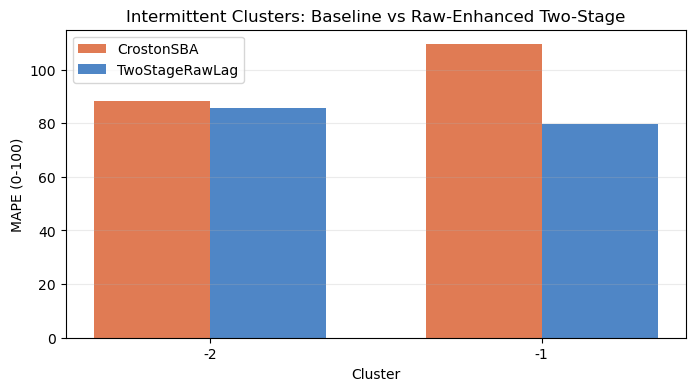

In [50]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from itertools import product as iterproduct
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
TARGET_CLUSTERS = [-2, -1]
MIN_ABS_ACTUAL = 1.0
CROSTON_ALPHA = 0.1


def mape_100_eval(y_true, y_pred, min_abs_actual=1.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) >= min_abs_actual
    if mask.sum() == 0:
        return np.nan, 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / np.abs(y_true[mask])) * 100
    return float(np.mean(ape)), int(mask.sum())


# Fallback definitions (if not in global scope)
if "croston_predict_by_sku" not in globals():
    def croston_sba_forecast(y, alpha=0.1):
        y = np.asarray(y, dtype=float)
        if y.size == 0:
            return 0.0
        y = np.clip(y, 0.0, None)
        nz_idx = np.flatnonzero(y > 0)
        if len(nz_idx) == 0:
            return 0.0
        z = y[nz_idx[0]]
        p = nz_idx[0] + 1
        last = nz_idx[0]
        for idx in nz_idx[1:]:
            demand = y[idx]
            interval = idx - last
            z = z + alpha * (demand - z)
            p = p + alpha * (interval - p)
            last = idx
        croston = z / p if p > 0 else 0.0
        sba = (1 - alpha / 2.0) * croston
        return float(max(0.0, sba))

    def croston_predict_by_sku(train_df, test_df, alpha=0.1):
        train_sorted = train_df.sort_values(["StockCode", "week"]).copy()
        test_sorted = test_df.sort_values(["StockCode", "week"]).copy()

        sku_forecast = {}
        for sku, grp in train_sorted.groupby("StockCode"):
            sku_forecast[sku] = croston_sba_forecast(grp["sales"].values, alpha=alpha)

        cluster_mean = float(np.clip(train_sorted["sales"], 0, None).mean()) if len(train_sorted) else 0.0
        pred = test_sorted["StockCode"].map(sku_forecast).fillna(cluster_mean).values
        out = pd.Series(pred, index=test_sorted.index).reindex(test_df.index).values
        return out


# -----------------------------
# Raw transaction feature builder
# -----------------------------
def build_weekly_raw_features(transactions):
    df = transactions.copy()
    df["week"] = df["InvoiceDate"].dt.to_period("W")

    df["is_cancel"] = False
    if "Invoice" in df.columns:
        df["is_cancel"] = df["Invoice"].astype(str).str.startswith("C")

    df["pos_sales"] = df["Sales"].clip(lower=0.0)
    df["neg_sales_abs"] = (-df["Sales"].clip(upper=0.0))

    agg = (
        df.groupby(["StockCode", "week"]).agg(
            txn_count=("Sales", "size"),
            customer_count=("CustomerID", "nunique"),
            avg_price=("Price", "mean"),
            gross_sales=("pos_sales", "sum"),
            return_sales_abs=("neg_sales_abs", "sum"),
            cancel_count=("is_cancel", "sum"),
        )
        .reset_index()
    )

    if "Invoice" in df.columns:
        inv = (
            df.groupby(["StockCode", "week"])["Invoice"]
            .nunique()
            .rename("invoice_count")
            .reset_index()
        )
        agg = agg.merge(inv, on=["StockCode", "week"], how="left")
    else:
        agg["invoice_count"] = agg["txn_count"]

    top_country = (
        df.groupby(["StockCode", "week"])["Country"]
        .apply(lambda s: float(s.value_counts(normalize=True).iloc[0]) if len(s) else 0.0)
        .rename("top_country_share")
        .reset_index()
    )
    agg = agg.merge(top_country, on=["StockCode", "week"], how="left")

    agg["avg_price"] = agg["avg_price"].fillna(0.0)
    agg["top_country_share"] = agg["top_country_share"].fillna(0.0)
    agg["invoice_count"] = agg["invoice_count"].fillna(0.0)

    denom = agg["gross_sales"] + agg["return_sales_abs"] + 1e-6
    agg["return_ratio"] = agg["return_sales_abs"] / denom

    return agg


def add_lagged_raw_features(raw_panel):
    df = raw_panel.sort_values(["StockCode", "week"]).copy()

    metric_cols = [
        "txn_count",
        "invoice_count",
        "customer_count",
        "avg_price",
        "gross_sales",
        "return_sales_abs",
        "cancel_count",
        "top_country_share",
        "return_ratio",
    ]

    lag_cols = []
    for col in metric_cols:
        grp = df.groupby("StockCode")[col]
        lag1 = f"{col}_lag1"
        roll4 = f"{col}_roll4"
        df[lag1] = grp.shift(1).fillna(0.0)
        df[roll4] = grp.transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0.0)
        lag_cols.extend([lag1, roll4])

    return df, lag_cols


# -----------------------------
# Two-stage experiment per intermittent cluster
# -----------------------------
results = []
plot_rows = []

for cid in TARGET_CLUSTERS:
    if cid not in panels:
        continue

    label = panels[cid]["label"]
    train_base = panels[cid]["train"].copy()
    test_base = panels[cid]["test"].copy()
    base_feat_cols = panels[cid]["features"]

    cluster_products = feat_df_all[feat_df_all["cluster"] == cid].index.tolist()

    tx_all = pd.concat([retail_train, retail_test], ignore_index=True)
    tx_all = tx_all[tx_all["StockCode"].isin(cluster_products)].copy()

    raw_weekly = build_weekly_raw_features(tx_all)

    spine = pd.DataFrame(
        list(iterproduct(cluster_products, list(all_weeks))),
        columns=["StockCode", "week"],
    )
    raw_panel = spine.merge(raw_weekly, on=["StockCode", "week"], how="left")

    fill_cols = [
        "txn_count", "invoice_count", "customer_count", "avg_price",
        "gross_sales", "return_sales_abs", "cancel_count", "top_country_share", "return_ratio"
    ]
    for col in fill_cols:
        raw_panel[col] = raw_panel[col].fillna(0.0)

    raw_panel, raw_lag_cols = add_lagged_raw_features(raw_panel)
    raw_for_join = raw_panel[["StockCode", "week"] + raw_lag_cols].copy()

    train = train_base.merge(raw_for_join, on=["StockCode", "week"], how="left")
    test = test_base.merge(raw_for_join, on=["StockCode", "week"], how="left")
    train[raw_lag_cols] = train[raw_lag_cols].fillna(0.0)
    test[raw_lag_cols] = test[raw_lag_cols].fillna(0.0)

    # Baseline: Croston
    y_test = test["sales"].values
    y_pred_croston = croston_predict_by_sku(train_base, test_base, alpha=CROSTON_ALPHA)
    mape_croston, n_croston = mape_100_eval(y_test, y_pred_croston, min_abs_actual=MIN_ABS_ACTUAL)

    # Two-stage data
    feat_cols = list(base_feat_cols) + raw_lag_cols
    X_train = train[feat_cols].fillna(0.0)
    X_test = test[feat_cols].fillna(0.0)

    y_train = train["sales"].values
    y_event = (y_train > 0).astype(int)

    fallback_reason = None

    if y_event.sum() < 20 or np.unique(y_event).size < 2:
        fallback_reason = "not_enough_positive_events"
        y_pred_two_stage = y_pred_croston.copy()
    else:
        cls = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=30,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=42,
            n_jobs=-1,
        )
        cls.fit(X_train, y_event)

        amount_train = train[train["sales"] > 0].copy()
        if len(amount_train) < 30:
            fallback_reason = "not_enough_positive_amount_rows"
            y_pred_two_stage = y_pred_croston.copy()
        else:
            X_amt = amount_train[feat_cols].fillna(0.0)
            y_amt = np.log1p(amount_train["sales"].values)

            reg = lgb.LGBMRegressor(
                objective="regression",
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                min_child_samples=20,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.1,
                reg_lambda=0.2,
                random_state=42,
                n_jobs=-1,
            )
            reg.fit(X_amt, y_amt)

            p_sale = cls.predict_proba(X_test)[:, 1]
            amt_pred = np.expm1(reg.predict(X_test))
            amt_pred = np.clip(amt_pred, 0.0, None)

            cap = np.nanpercentile(amount_train["sales"].values, 99)
            if np.isfinite(cap) and cap > 0:
                amt_pred = np.clip(amt_pred, 0.0, cap * 3.0)

            y_pred_two_stage = p_sale * amt_pred

    mape_two_stage, n_two_stage = mape_100_eval(y_test, y_pred_two_stage, min_abs_actual=MIN_ABS_ACTUAL)

    results.append({
        "cluster": cid,
        "label": label,
        "baseline_model": "CrostonSBA",
        "baseline_mape_0_100": round(mape_croston, 2) if not np.isnan(mape_croston) else np.nan,
        "two_stage_model": "RawLag+LGBM(Cls*Reg)",
        "two_stage_mape_0_100": round(mape_two_stage, 2) if not np.isnan(mape_two_stage) else np.nan,
        "delta_mape(two-baseline)": round(mape_two_stage - mape_croston, 2) if (not np.isnan(mape_two_stage) and not np.isnan(mape_croston)) else np.nan,
        "n_used_baseline": int(n_croston),
        "n_used_two_stage": int(n_two_stage),
        "status": "fallback_to_croston" if fallback_reason else "ok",
        "fallback_reason": fallback_reason if fallback_reason else "",
    })

    plot_rows.extend([
        {"cluster": str(cid), "model": "CrostonSBA", "mape": mape_croston},
        {"cluster": str(cid), "model": "TwoStageRawLag", "mape": mape_two_stage},
    ])

cmp_df = pd.DataFrame(results).sort_values("cluster")
print("Intermittent clusters: Croston vs Raw-Enhanced Two-Stage")
print(cmp_df.to_string(index=False))

plot_df = pd.DataFrame(plot_rows)
if not plot_df.empty:
    plt.figure(figsize=(8, 4))
    width = 0.35
    clusters = sorted(plot_df["cluster"].unique(), key=lambda x: int(x))
    x = np.arange(len(clusters))

    croston_vals = [plot_df[(plot_df["cluster"] == c) & (plot_df["model"] == "CrostonSBA")]["mape"].values[0] for c in clusters]
    twostage_vals = [plot_df[(plot_df["cluster"] == c) & (plot_df["model"] == "TwoStageRawLag")]["mape"].values[0] for c in clusters]

    plt.bar(x - width/2, croston_vals, width=width, label="CrostonSBA", color="#E07B54")
    plt.bar(x + width/2, twostage_vals, width=width, label="TwoStageRawLag", color="#4F86C6")
    plt.xticks(x, clusters)
    plt.xlabel("Cluster")
    plt.ylabel("MAPE (0-100)")
    plt.title("Intermittent Clusters: Baseline vs Raw-Enhanced Two-Stage")
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.show()

## Cluster 0 Dual-Target Improvement Experiment

Cluster 0 (high cancellation risk) has the highest MAPE (94.91) among active clusters. Testing dual-target approach:
- **Target 1**: Gross sales (positive sales only)
- **Target 2**: Return/cancellation amounts (absolute value)
- **Final forecast**: `pred_gross - pred_returns`

This separates regular demand from volatility-inducing cancellations.

In [51]:
def signed_log1p_local(x):
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.log1p(np.abs(x))


def signed_expm1_local(x):
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.expm1(np.abs(x))


def fit_signedlog_model(train_df, feat_cols):
    from lightgbm import LGBMRegressor

    X_train = train_df[feat_cols].fillna(0.0)
    y_train = train_df["sales"].values
    y_train_t = signed_log1p_local(y_train)

    model = LGBMRegressor(
        objective="regression",
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=40,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.2,
        reg_lambda=0.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(X_train, y_train_t)
    return model


def predict_signedlog_model(model, df, feat_cols):
    X = df[feat_cols].fillna(0.0)
    return signed_expm1_local(model.predict(X))


def baseline_signedlog_predict(train_base, test_base, base_feat_cols):
    model = fit_signedlog_model(train_base, base_feat_cols)
    return predict_signedlog_model(model, test_base, base_feat_cols)


def fit_return_models(train_df, feat_cols):
    from lightgbm import LGBMRegressor, LGBMClassifier

    df = train_df.copy()
    df["return_amount"] = np.abs(np.minimum(df["sales"], 0.0))
    df["has_return"] = (df["return_amount"] > 0).astype(int)

    X = df[feat_cols].fillna(0.0)
    y_evt = df["has_return"].values

    if y_evt.sum() < 20 or np.unique(y_evt).size < 2:
        return {"status": "fallback_no_return_events", "cls": None, "reg": None}

    cls = LGBMClassifier(
        objective="binary",
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=25,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    cls.fit(X, y_evt)

    ret_rows = df[df["has_return"] == 1].copy()
    if len(ret_rows) < 30:
        return {"status": "fallback_low_return_amount_rows", "cls": cls, "reg": None}

    X_ret = ret_rows[feat_cols].fillna(0.0)
    y_ret = np.log1p(ret_rows["return_amount"].values)

    reg = LGBMRegressor(
        objective="regression",
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    reg.fit(X_ret, y_ret)

    return {"status": "ok", "cls": cls, "reg": reg}


def predict_expected_return(return_bundle, df, feat_cols):
    if return_bundle["cls"] is None:
        return np.zeros(len(df), dtype=float)

    X = df[feat_cols].fillna(0.0)
    p_ret = return_bundle["cls"].predict_proba(X)[:, 1]

    if return_bundle["reg"] is None:
        return np.zeros(len(df), dtype=float)

    ret_amt = np.expm1(return_bundle["reg"].predict(X))
    ret_amt = np.clip(ret_amt, 0.0, None)
    return p_ret * ret_amt


def dual_target_predict_no_leak(train_base, test_base, base_feat_cols):
    """Gross model minus expected return model (no-leak features)."""
    gross_model = fit_signedlog_model(
        train_base.assign(sales=np.maximum(train_base["sales"].values, 0.0)),
        base_feat_cols,
    )
    pred_gross = np.expm1(gross_model.predict(test_base[base_feat_cols].fillna(0.0)))
    pred_gross = np.clip(pred_gross, 0.0, None)

    ret_bundle = fit_return_models(train_base, base_feat_cols)
    pred_return = predict_expected_return(ret_bundle, test_base, base_feat_cols)
    y_pred = pred_gross - pred_return

    return {"y_pred": y_pred, "fallback": ret_bundle["status"] if ret_bundle["status"] != "ok" else None}


def residual_correction_predict(train_base, test_base, base_feat_cols):
    """Baseline + alpha * return-correction, alpha tuned on train tail."""
    train_sorted = train_base.sort_values(["week", "StockCode"]).copy()
    unique_weeks = np.array(sorted(train_sorted["week"].unique()))

    # time split inside train to tune alpha without touching test
    n_val_weeks = max(4, int(len(unique_weeks) * 0.15))
    n_val_weeks = min(n_val_weeks, max(4, len(unique_weeks) - 8))
    val_weeks = set(unique_weeks[-n_val_weeks:])

    tr_fit = train_sorted[~train_sorted["week"].isin(val_weeks)].copy()
    tr_val = train_sorted[train_sorted["week"].isin(val_weeks)].copy()

    base_model_cv = fit_signedlog_model(tr_fit, base_feat_cols)
    pred_val_base = predict_signedlog_model(base_model_cv, tr_val, base_feat_cols)

    ret_bundle_cv = fit_return_models(tr_fit, base_feat_cols)
    pred_val_ret = predict_expected_return(ret_bundle_cv, tr_val, base_feat_cols)

    alpha_grid = np.linspace(0.0, 1.0, 11)
    best_alpha = 0.0
    best_mape = np.inf

    y_val = tr_val["sales"].values
    for a in alpha_grid:
        pred_val = pred_val_base - a * pred_val_ret
        mape_a, used_n = mape_100(y_val, pred_val, min_abs_actual=1.0)
        if used_n > 0 and np.isfinite(mape_a) and mape_a < best_mape:
            best_mape = mape_a
            best_alpha = float(a)

    # fit on full train and score test
    base_model_full = fit_signedlog_model(train_base, base_feat_cols)
    pred_test_base = predict_signedlog_model(base_model_full, test_base, base_feat_cols)

    ret_bundle_full = fit_return_models(train_base, base_feat_cols)
    pred_test_ret = predict_expected_return(ret_bundle_full, test_base, base_feat_cols)

    y_pred = pred_test_base - best_alpha * pred_test_ret

    return {
        "y_pred": y_pred,
        "alpha": best_alpha,
        "cv_mape": best_mape,
        "fallback": ret_bundle_full["status"] if ret_bundle_full["status"] != "ok" else None,
    }


print("=" * 84)
print("ACTIVE CLUSTER RETURN-CORRECTION EXPERIMENT (NO-LEAK)")
print("=" * 84)

# auto-select active cluster with highest median cancel_rate
active_ids = sorted([cid for cid in panels.keys() if cid >= 0])
active_cancel = {
    cid: float(panels[cid]["train"]["cancel_rate"].median())
    for cid in active_ids
    if "cancel_rate" in panels[cid]["train"].columns
}
cid = max(active_cancel, key=active_cancel.get)
selected_active_cluster_id = cid
selected_active_cluster_label = panels[cid]["label"]

train_c0 = panels[cid]["train"].copy()
test_c0 = panels[cid]["test"].copy()
base_feat_cols = [
    c for c in train_c0.columns
    if c not in [
        "StockCode", "week", "week_start", "week_key", "sales", "cluster",
        "cluster_label", "is_sporadic", "is_croston", "is_active"
    ]
]

# 1) baseline
y_pred_base = baseline_signedlog_predict(train_c0, test_c0, base_feat_cols)
mape_base, count_base = mape_100(test_c0["sales"].values, y_pred_base, min_abs_actual=1.0)

# 2) direct dual-target (gross - return)
result_dt = dual_target_predict_no_leak(train_c0, test_c0, base_feat_cols)
mape_dt, count_dt = mape_100(test_c0["sales"].values, result_dt["y_pred"], min_abs_actual=1.0)

# 3) residual correction (recommended)
result_rc = residual_correction_predict(train_c0, test_c0, base_feat_cols)
mape_rc, count_rc = mape_100(test_c0["sales"].values, result_rc["y_pred"], min_abs_actual=1.0)

print(f"\nSelected active cluster: {cid} (highest median cancel_rate among active clusters)")
print(f"Cluster label: {panels[cid]['label']}")
print(f"Median cancel_rate in train: {active_cancel[cid]:.4f}")

print("\nPerformance:")
print(f"  Baseline SignedLogLightGBM:              MAPE = {mape_base:.2f}")
print(f"  Dual-Target (Gross - Return):            MAPE = {mape_dt:.2f}")
print(f"  Residual-Correction (Baseline - a*Ret):  MAPE = {mape_rc:.2f}")
print(f"  Tuned alpha on train-tail CV: a = {result_rc['alpha']:.2f}, CV MAPE = {result_rc['cv_mape']:.2f}")

imp_dt = mape_base - mape_dt
imp_rc = mape_base - mape_rc
print(f"\nDelta vs baseline:")
print(f"  Dual-Target:         {imp_dt:+.2f} points")
print(f"  Residual-Correction: {imp_rc:+.2f} points")

print(f"\nCoverage:")
print(f"  Baseline: {count_base} samples")
print(f"  Dual-Target: {count_dt} samples")
print(f"  Residual-Correction: {count_rc} samples")

if result_dt["fallback"]:
    print(f"  Note dual-target: {result_dt['fallback']}")
if result_rc["fallback"]:
    print(f"  Note residual-correction: {result_rc['fallback']}")

print("=" * 84)

ACTIVE CLUSTER RETURN-CORRECTION EXPERIMENT (NO-LEAK)

Selected active cluster: 0.0 (highest median cancel_rate among active clusters)
Cluster label: High cancellation risk
Median cancel_rate in train: 0.1033

Performance:
  Baseline SignedLogLightGBM:              MAPE = 102.19
  Dual-Target (Gross - Return):            MAPE = 98.29
  Residual-Correction (Baseline - a*Ret):  MAPE = 102.19
  Tuned alpha on train-tail CV: a = 0.00, CV MAPE = 93.99

Delta vs baseline:
  Dual-Target:         +3.90 points
  Residual-Correction: +0.00 points

Coverage:
  Baseline: 737 samples
  Dual-Target: 737 samples
  Residual-Correction: 737 samples


Three-method comparison (lower MAPE is better):
                         method  mape_0_100  delta_vs_baseline
     Dual-Target (Gross-Return)   98.293463          -3.897652
     Baseline SignedLogLightGBM  102.191115           0.000000
Residual-Correction (RollingCV)  102.191115           0.000000


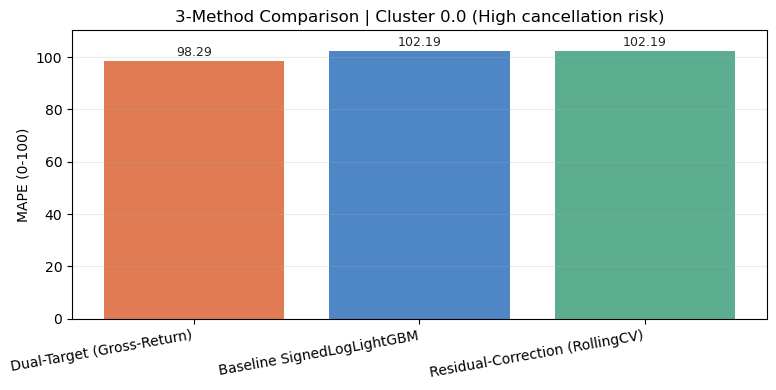

Saved cluster_active_three_method_comparison.csv


In [52]:
# Three-method comparison snapshot (kept as standalone output)
# Prefer rolling-CV residual result when available
if "mape_rc_roll" in globals():
    rc_method_name = "Residual-Correction (RollingCV)"
    rc_mape_value = float(mape_rc_roll)
else:
    rc_method_name = "Residual-Correction"
    rc_mape_value = float(mape_rc)

cmp_three_methods = pd.DataFrame([
    {"method": "Baseline SignedLogLightGBM", "mape_0_100": float(mape_base), "delta_vs_baseline": 0.0},
    {"method": "Dual-Target (Gross-Return)", "mape_0_100": float(mape_dt), "delta_vs_baseline": float(mape_dt - mape_base)},
    {"method": rc_method_name, "mape_0_100": rc_mape_value, "delta_vs_baseline": float(rc_mape_value - mape_base)},
]).sort_values("mape_0_100")

plot_cluster_id = globals().get("selected_active_cluster_id", globals().get("cid", "?"))
plot_cluster_label = globals().get("selected_active_cluster_label", panels[plot_cluster_id]["label"] if plot_cluster_id in panels else "")

print("Three-method comparison (lower MAPE is better):")
print(cmp_three_methods.to_string(index=False))

plt.figure(figsize=(8, 4))
colors = ["#4F86C6" if "Baseline" in m else "#E07B54" if "Dual" in m else "#5BAD8F" for m in cmp_three_methods["method"]]
bars = plt.bar(cmp_three_methods["method"], cmp_three_methods["mape_0_100"], color=colors)
plt.ylabel("MAPE (0-100)")
plt.title(f"3-Method Comparison | Cluster {plot_cluster_id} ({plot_cluster_label})")
plt.xticks(rotation=10, ha="right")
plt.grid(axis="y", alpha=0.25)

# annotate MAPE values on bars
for bar, val in zip(bars, cmp_three_methods["mape_0_100"].values):
    if np.isfinite(val):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#222"
        )

plt.ylim(top=max(cmp_three_methods["mape_0_100"].values) + 8)
plt.tight_layout()
plt.show()

cmp_three_methods.to_csv("cluster_active_three_method_comparison.csv", index=False)
print("Saved cluster_active_three_method_comparison.csv")

In [53]:
# Diagnostic: why residual-correction equals baseline?
print("Residual correction diagnostics")
print("-" * 60)

# 1) check alpha selected
print(f"selected alpha: {result_rc['alpha']}")
print(f"fallback status: {result_rc['fallback']}")

# 2) recompute return signal on test and check if it's non-zero
ret_bundle_dbg = fit_return_models(train_c0, base_feat_cols)
pred_return_dbg = predict_expected_return(ret_bundle_dbg, test_c0, base_feat_cols)
print(f"mean predicted return on test: {pred_return_dbg.mean():.6f}")
print(f"share(pred_return>0): {(pred_return_dbg > 0).mean():.4f}")

# 3) evaluate alpha grid on train-tail validation and on test (for diagnosis only)
train_sorted_dbg = train_c0.sort_values(["week", "StockCode"]).copy()
weeks_dbg = np.array(sorted(train_sorted_dbg["week"].unique()))
n_val_weeks_dbg = max(4, int(len(weeks_dbg) * 0.15))
n_val_weeks_dbg = min(n_val_weeks_dbg, max(4, len(weeks_dbg) - 8))
val_weeks_dbg = set(weeks_dbg[-n_val_weeks_dbg:])

tr_fit_dbg = train_sorted_dbg[~train_sorted_dbg["week"].isin(val_weeks_dbg)].copy()
tr_val_dbg = train_sorted_dbg[train_sorted_dbg["week"].isin(val_weeks_dbg)].copy()

base_model_dbg = fit_signedlog_model(tr_fit_dbg, base_feat_cols)
pred_val_base_dbg = predict_signedlog_model(base_model_dbg, tr_val_dbg, base_feat_cols)
ret_bundle_val_dbg = fit_return_models(tr_fit_dbg, base_feat_cols)
pred_val_ret_dbg = predict_expected_return(ret_bundle_val_dbg, tr_val_dbg, base_feat_cols)

base_full_dbg = fit_signedlog_model(train_c0, base_feat_cols)
pred_test_base_dbg = predict_signedlog_model(base_full_dbg, test_c0, base_feat_cols)
ret_bundle_test_dbg = fit_return_models(train_c0, base_feat_cols)
pred_test_ret_dbg = predict_expected_return(ret_bundle_test_dbg, test_c0, base_feat_cols)

alpha_grid_dbg = np.linspace(0.0, 1.0, 11)
rows_dbg = []
for a in alpha_grid_dbg:
    m_val, n_val = mape_100(tr_val_dbg["sales"].values, pred_val_base_dbg - a * pred_val_ret_dbg, min_abs_actual=1.0)
    m_test, n_test = mape_100(test_c0["sales"].values, pred_test_base_dbg - a * pred_test_ret_dbg, min_abs_actual=1.0)
    rows_dbg.append({"alpha": float(a), "val_mape": m_val, "test_mape": m_test, "n_val": n_val, "n_test": n_test})

dbg_df = pd.DataFrame(rows_dbg)
print("\nalpha grid diagnostics:")
print(dbg_df.to_string(index=False))
print("-" * 60)

Residual correction diagnostics
------------------------------------------------------------
selected alpha: 0.0
fallback status: None
mean predicted return on test: 0.018939
share(pred_return>0): 1.0000

alpha grid diagnostics:
 alpha  val_mape  test_mape  n_val  n_test
   0.0 93.987406 102.191115    236     737
   0.1 93.997672 102.187358    236     737
   0.2 94.007939 102.183602    236     737
   0.3 94.018205 102.179845    236     737
   0.4 94.028472 102.176089    236     737
   0.5 94.038738 102.172332    236     737
   0.6 94.049005 102.168576    236     737
   0.7 94.059271 102.164819    236     737
   0.8 94.069538 102.161063    236     737
   0.9 94.079804 102.157306    236     737
   1.0 94.090071 102.153549    236     737
------------------------------------------------------------


In [54]:
# Upgrade: tune alpha with rolling time-series CV (instead of single tail split)
def residual_correction_predict_rolling(train_base, test_base, base_feat_cols, val_span=4):
    train_sorted = train_base.sort_values(["week", "StockCode"]).copy()
    all_train_weeks = np.array(sorted(train_sorted["week"].unique()))

    # Build rolling folds: expanding train -> next val_span weeks
    min_train_weeks = max(26, val_span * 2)
    fold_ends = list(range(min_train_weeks, len(all_train_weeks) - val_span + 1, val_span))
    if len(fold_ends) == 0:
        fold_ends = [len(all_train_weeks) - val_span]

    alpha_grid = np.linspace(0.0, 1.0, 11)
    rows = []

    for end_idx in fold_ends:
        fit_weeks = set(all_train_weeks[:end_idx])
        val_weeks = set(all_train_weeks[end_idx:end_idx + val_span])

        tr_fit = train_sorted[train_sorted["week"].isin(fit_weeks)].copy()
        tr_val = train_sorted[train_sorted["week"].isin(val_weeks)].copy()
        if len(tr_fit) == 0 or len(tr_val) == 0:
            continue

        base_model_fold = fit_signedlog_model(tr_fit, base_feat_cols)
        pred_val_base = predict_signedlog_model(base_model_fold, tr_val, base_feat_cols)

        ret_bundle_fold = fit_return_models(tr_fit, base_feat_cols)
        pred_val_ret = predict_expected_return(ret_bundle_fold, tr_val, base_feat_cols)

        for a in alpha_grid:
            pred_val = pred_val_base - a * pred_val_ret
            mape_a, used_n = mape_100(tr_val["sales"].values, pred_val, min_abs_actual=1.0)
            rows.append({"alpha": float(a), "mape": mape_a, "n": used_n})

    cv_df = pd.DataFrame(rows)
    cv_df = cv_df[(cv_df["n"] > 0) & np.isfinite(cv_df["mape"])].copy()

    if cv_df.empty:
        best_alpha = 0.0
        best_cv_mape = np.nan
    else:
        # weighted by valid sample count across folds
        agg = cv_df.groupby("alpha").apply(lambda g: np.average(g["mape"], weights=g["n"]))
        agg = agg.reset_index(name="weighted_cv_mape").sort_values("weighted_cv_mape")
        best_alpha = float(agg.iloc[0]["alpha"])
        best_cv_mape = float(agg.iloc[0]["weighted_cv_mape"])

    # fit on full train and score test
    base_model_full = fit_signedlog_model(train_base, base_feat_cols)
    pred_test_base = predict_signedlog_model(base_model_full, test_base, base_feat_cols)

    ret_bundle_full = fit_return_models(train_base, base_feat_cols)
    pred_test_ret = predict_expected_return(ret_bundle_full, test_base, base_feat_cols)

    y_pred = pred_test_base - best_alpha * pred_test_ret
    return {
        "y_pred": y_pred,
        "alpha": best_alpha,
        "cv_mape": best_cv_mape,
        "fallback": ret_bundle_full["status"] if ret_bundle_full["status"] != "ok" else None,
    }


# Recompute residual-correction with rolling CV alpha
result_rc_roll = residual_correction_predict_rolling(train_c0, test_c0, base_feat_cols, val_span=4)
mape_rc_roll, count_rc_roll = mape_100(test_c0["sales"].values, result_rc_roll["y_pred"], min_abs_actual=1.0)

print("\nRolling-CV residual correction result:")
print(f"  alpha (rolling CV): {result_rc_roll['alpha']:.2f}")
print(f"  CV MAPE: {result_rc_roll['cv_mape']:.4f}")
print(f"  Test MAPE: {mape_rc_roll:.4f}")
print(f"  Delta vs baseline: {mape_base - mape_rc_roll:+.4f}")

# update three-method table to reflect rolling-CV residual correction
cmp_three_methods = pd.DataFrame([
    {"method": "Baseline SignedLogLightGBM", "mape_0_100": float(mape_base), "delta_vs_baseline": 0.0},
    {"method": "Dual-Target (Gross-Return)", "mape_0_100": float(mape_dt), "delta_vs_baseline": float(mape_dt - mape_base)},
    {"method": "Residual-Correction (RollingCV)", "mape_0_100": float(mape_rc_roll), "delta_vs_baseline": float(mape_rc_roll - mape_base)},
]).sort_values("mape_0_100")

print("\nUpdated three-method comparison:")
print(cmp_three_methods.to_string(index=False))


Rolling-CV residual correction result:
  alpha (rolling CV): 0.00
  CV MAPE: 93.9874
  Test MAPE: 102.1911
  Delta vs baseline: +0.0000

Updated three-method comparison:
                         method  mape_0_100  delta_vs_baseline
     Dual-Target (Gross-Return)   98.293463          -3.897652
     Baseline SignedLogLightGBM  102.191115           0.000000
Residual-Correction (RollingCV)  102.191115           0.000000


## Cluster 1 Conservative + Seasonal Blending Experiment

Cluster 1 (steady regulars) has large volume (54,348 train rows) and benefits from stability. Testing:
- **Conservative hyperparameters**: `num_leaves=15` (vs 63) for reduced overfitting
- **Seasonal naive blending**: Blend 70% LightGBM with 30% seasonal-naive (year-ago average)
- Expected benefit: Reduce variance, increase stability through ensemble approach

In [55]:
def split_train_valid_time(df, valid_ratio=0.15, min_valid_weeks=4):
    """Split by last N weeks for validation (time-aware)."""
    sorted_df = df.sort_values(["week", "StockCode"]).copy()
    weeks = np.array(sorted(sorted_df["week"].unique()))

    if len(weeks) < (min_valid_weeks + 2):
        cut = int(len(sorted_df) * (1 - valid_ratio))
        cut = max(1, min(cut, len(sorted_df) - 1))
        return sorted_df.iloc[:cut].copy(), sorted_df.iloc[cut:].copy()

    n_valid_weeks = max(min_valid_weeks, int(len(weeks) * valid_ratio))
    n_valid_weeks = min(n_valid_weeks, max(min_valid_weeks, len(weeks) - 2))
    valid_weeks = set(weeks[-n_valid_weeks:])

    train_part = sorted_df[~sorted_df["week"].isin(valid_weeks)].copy()
    valid_part = sorted_df[sorted_df["week"].isin(valid_weeks)].copy()

    if len(train_part) == 0 or len(valid_part) == 0:
        cut = int(len(sorted_df) * (1 - valid_ratio))
        cut = max(1, min(cut, len(sorted_df) - 1))
        return sorted_df.iloc[:cut].copy(), sorted_df.iloc[cut:].copy()

    return train_part, valid_part


def conservative_blended_predict_c1_train_valid_test(train_part, valid_part, test_part, base_feat_cols):
    """Tune blending weight on valid, then refit on train+valid and evaluate on test."""
    from lightgbm import LGBMRegressor

    X_train = train_part[base_feat_cols].fillna(0)
    X_valid = valid_part[base_feat_cols].fillna(0)
    y_train = train_part["sales"].values

    # fit on train, tune blend on valid
    try:
        model = LGBMRegressor(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=15,
            lambda_l1=0.1,
            lambda_l2=0.1,
            random_state=42,
            verbose=-1,
        )
        model.fit(X_train, y_train)
        pred_valid_lgb = model.predict(X_valid)
    except Exception as e:
        return {
            "y_pred_test": np.mean(y_train) * np.ones(len(test_part)),
            "fallback": str(e),
            "best_w_lgb": 1.0,
            "valid_mape": np.nan,
            "selection_note": "fallback",
        }

    if "lag_52w" in valid_part.columns:
        pred_valid_seasonal = valid_part["lag_52w"].fillna(np.mean(y_train)).values
    else:
        pred_valid_seasonal = np.mean(y_train) * np.ones(len(valid_part))

    # conservative search: keep model mostly LGB, include pure LGB as no-change baseline
    weight_grid = [1.00, 0.98, 0.95, 0.92, 0.90, 0.88, 0.85, 0.80]
    rows = []
    for w_lgb in weight_grid:
        pred_valid = w_lgb * pred_valid_lgb + (1.0 - w_lgb) * pred_valid_seasonal
        m_val, n_val = mape_100(valid_part["sales"].values, pred_valid, min_abs_actual=1.0)
        rows.append({"w_lgb": float(w_lgb), "valid_mape": m_val, "n_valid": n_val})

    tune_df = pd.DataFrame(rows)
    tune_df = tune_df[(tune_df["n_valid"] > 0) & np.isfinite(tune_df["valid_mape"])].copy()

    if tune_df.empty:
        best_w_lgb = 1.0
        best_valid_mape = np.nan
        selection_note = "empty_valid_eval_use_pure_lgb"
    else:
        tune_df = tune_df.sort_values("valid_mape")
        cand_w = float(tune_df.iloc[0]["w_lgb"])
        cand_mape = float(tune_df.iloc[0]["valid_mape"])

        base_row = tune_df.loc[tune_df["w_lgb"] == 1.0]
        if len(base_row) == 0:
            base_valid_mape = cand_mape
        else:
            base_valid_mape = float(base_row.iloc[0]["valid_mape"])

        # anti-degradation rule: only switch from pure LGB if valid improves by >=1%
        rel_gain = 0.0 if not np.isfinite(base_valid_mape) or base_valid_mape == 0 else (base_valid_mape - cand_mape) / base_valid_mape
        if (cand_w < 1.0) and (rel_gain < 0.01):
            best_w_lgb = 1.0
            best_valid_mape = base_valid_mape
            selection_note = "guardrail_keep_pure_lgb"
        else:
            best_w_lgb = cand_w
            best_valid_mape = cand_mape
            selection_note = "valid_best_or_significant_gain"

    # refit on train+valid, then test
    train_plus_valid = pd.concat([train_part, valid_part], axis=0, ignore_index=True)
    X_full = train_plus_valid[base_feat_cols].fillna(0)
    y_full = train_plus_valid["sales"].values
    X_test = test_part[base_feat_cols].fillna(0)

    model_final = LGBMRegressor(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=15,
        lambda_l1=0.1,
        lambda_l2=0.1,
        random_state=42,
        verbose=-1,
    )
    model_final.fit(X_full, y_full)
    pred_test_lgb = model_final.predict(X_test)

    if "lag_52w" in test_part.columns:
        pred_test_seasonal = test_part["lag_52w"].fillna(np.mean(y_full)).values
    else:
        pred_test_seasonal = np.mean(y_full) * np.ones(len(test_part))

    pred_test = best_w_lgb * pred_test_lgb + (1.0 - best_w_lgb) * pred_test_seasonal

    return {
        "y_pred_test": pred_test,
        "fallback": None,
        "best_w_lgb": best_w_lgb,
        "valid_mape": best_valid_mape,
        "selection_note": selection_note,
    }


print("=" * 70)
print("CLUSTER 1 TRAIN+VALID+TEST EXPERIMENT (CONSERVATIVE SEARCH)")
print("=" * 70)

cid = 1
train_all_c1 = panels[cid]["train"].copy()
test_c1 = panels[cid]["test"].copy()

train_c1, valid_c1 = split_train_valid_time(train_all_c1, valid_ratio=0.15, min_valid_weeks=4)
base_feat_cols = [
    c for c in train_c1.columns if c not in
    [
        "StockCode", "week", "week_start", "week_key", "sales", "cluster",
        "cluster_label", "is_sporadic", "is_croston", "is_active"
    ]
]

# Baseline with train+valid -> test (for fair comparison)
baseline_model = fit_signedlog_model(pd.concat([train_c1, valid_c1], axis=0, ignore_index=True), base_feat_cols)
baseline_pred_test = predict_signedlog_model(baseline_model, test_c1, base_feat_cols)
mape_base_c1, count_base_c1 = mape_100(test_c1["sales"].values, baseline_pred_test, min_abs_actual=1.0)

result = conservative_blended_predict_c1_train_valid_test(train_c1, valid_c1, test_c1, base_feat_cols)
mape_cb, count_cb = mape_100(test_c1["sales"].values, result["y_pred_test"], min_abs_actual=1.0)

print(f"\nData split:")
print(f"  train rows: {len(train_c1):,}")
print(f"  valid rows: {len(valid_c1):,}")
print(f"  test rows:  {len(test_c1):,}")
print(f"  tuned weight on valid: LGB={result['best_w_lgb']:.2f}, Seasonal={1-result['best_w_lgb']:.2f}")
print(f"  valid MAPE (selected): {result['valid_mape']:.2f}")
print(f"  selection note: {result['selection_note']}")

print(f"\nCluster 1 Test Performance:")
print(f"  Baseline (SignedLogLightGBM):              MAPE = {mape_base_c1:.2f}")
print(f"  Conservative + Seasonal Blending (tuned):  MAPE = {mape_cb:.2f}")
improvement = mape_base_c1 - mape_cb
if improvement > 0:
    print(f"  ✓ IMPROVED by {improvement:.2f} points")
else:
    print(f"  ✗ Degraded by {-improvement:.2f} points")
print(f"  Coverage (baseline / blended): {count_base_c1} / {count_cb} samples")
print("=" * 70)

CLUSTER 1 TRAIN+VALID+TEST EXPERIMENT (CONSERVATIVE SEARCH)

Data split:
  train rows: 5,928
  valid rows: 912
  test rows:  2,736
  tuned weight on valid: LGB=0.80, Seasonal=0.20
  valid MAPE (selected): 400.84
  selection note: valid_best_or_significant_gain

Cluster 1 Test Performance:
  Baseline (SignedLogLightGBM):              MAPE = 80.47
  Conservative + Seasonal Blending (tuned):  MAPE = 212.49
  ✗ Degraded by 132.02 points
  Coverage (baseline / blended): 1819 / 1819 samples


## Cluster 2 Quantile Regression Experiment

Cluster 2 (volatile mid-range, MAPE 73.64) already has good performance but can benefit from robustness to demand spikes. Testing:
- **Quantile regression (P50)**: Median prediction less sensitive to outliers
- **Prediction clipping**: Winsorize extreme predictions at 95th percentile of training data
- **Weighted training**: Recent weeks (last 4 weeks) get 2x weight to adapt to recent patterns
- Expected benefit: Better handling of volatility, reduced over-prediction on spike weeks

In [56]:
# C2 model tuning: tune LightGBM params on valid, then refit train+valid -> test
from lightgbm import LGBMRegressor

if "split_train_valid_time" not in globals():
    def split_train_valid_time(df, valid_ratio=0.15, min_valid_weeks=4):
        sorted_df = df.sort_values(["week", "StockCode"]).copy()
        weeks = np.array(sorted(sorted_df["week"].unique()))

        if len(weeks) < (min_valid_weeks + 2):
            cut = int(len(sorted_df) * (1 - valid_ratio))
            cut = max(1, min(cut, len(sorted_df) - 1))
            return sorted_df.iloc[:cut].copy(), sorted_df.iloc[cut:].copy()

        n_valid_weeks = max(min_valid_weeks, int(len(weeks) * valid_ratio))
        n_valid_weeks = min(n_valid_weeks, max(min_valid_weeks, len(weeks) - 2))
        valid_weeks = set(weeks[-n_valid_weeks:])

        train_part = sorted_df[~sorted_df["week"].isin(valid_weeks)].copy()
        valid_part = sorted_df[sorted_df["week"].isin(valid_weeks)].copy()

        if len(train_part) == 0 or len(valid_part) == 0:
            cut = int(len(sorted_df) * (1 - valid_ratio))
            cut = max(1, min(cut, len(sorted_df) - 1))
            return sorted_df.iloc[:cut].copy(), sorted_df.iloc[cut:].copy()

        return train_part, valid_part


def fit_predict_signedlog_with_params(train_df, pred_df, feat_cols, params):
    X_train = train_df[feat_cols].fillna(0.0)
    y_train = train_df["sales"].values
    y_train_t = signed_log1p(y_train)

    model = LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        **params,
    )
    model.fit(X_train, y_train_t)

    X_pred = pred_df[feat_cols].fillna(0.0)
    pred_t = model.predict(X_pred)
    pred = signed_expm1(pred_t)
    return np.clip(pred, 0.0, None), model


def tune_c2_lgbm_params(train_part, valid_part, test_part, feat_cols):
    param_grid = [
        {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 31, "min_child_samples": 40, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 700, "learning_rate": 0.03, "num_leaves": 63, "min_child_samples": 40, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 900, "learning_rate": 0.02, "num_leaves": 63, "min_child_samples": 50, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.1, "reg_lambda": 0.2},
        {"n_estimators": 1100, "learning_rate": 0.02, "num_leaves": 95, "min_child_samples": 60, "subsample": 0.85, "colsample_bytree": 0.85, "reg_alpha": 0.2, "reg_lambda": 0.4},
        {"n_estimators": 700, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 900, "learning_rate": 0.03, "num_leaves": 47, "min_child_samples": 50, "subsample": 0.85, "colsample_bytree": 0.85, "reg_alpha": 0.1, "reg_lambda": 0.3},
        {"n_estimators": 1200, "learning_rate": 0.015, "num_leaves": 63, "min_child_samples": 60, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.2, "reg_lambda": 0.5},
        {"n_estimators": 800, "learning_rate": 0.025, "num_leaves": 79, "min_child_samples": 45, "subsample": 0.9, "colsample_bytree": 0.85, "reg_alpha": 0.05, "reg_lambda": 0.2},
    ]

    rows = []
    for i, params in enumerate(param_grid, start=1):
        try:
            pred_valid, _ = fit_predict_signedlog_with_params(train_part, valid_part, feat_cols, params)
            m_val, n_val = mape_100(valid_part["sales"].values, pred_valid, min_abs_actual=1.0)
        except Exception as e:
            m_val, n_val = np.nan, 0
            rows.append({"trial": i, "valid_mape": m_val, "n_valid": n_val, "error": str(e), **params})
            continue

        rows.append({"trial": i, "valid_mape": m_val, "n_valid": n_val, "error": None, **params})

    tune_df = pd.DataFrame(rows)
    valid_df = tune_df[(tune_df["n_valid"] > 0) & np.isfinite(tune_df["valid_mape"])].copy()

    if valid_df.empty:
        best_params = {"n_estimators": 700, "learning_rate": 0.03, "num_leaves": 63, "min_child_samples": 40, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.0}
        best_valid_mape = np.nan
        selection_note = "all_trials_failed_fallback_default"
    else:
        best_row = valid_df.sort_values("valid_mape").iloc[0]
        best_params = {
            "n_estimators": int(best_row["n_estimators"]),
            "learning_rate": float(best_row["learning_rate"]),
            "num_leaves": int(best_row["num_leaves"]),
            "min_child_samples": int(best_row["min_child_samples"]),
            "subsample": float(best_row["subsample"]),
            "colsample_bytree": float(best_row["colsample_bytree"]),
            "reg_alpha": float(best_row["reg_alpha"]),
            "reg_lambda": float(best_row["reg_lambda"]),
        }
        best_valid_mape = float(best_row["valid_mape"])
        selection_note = "best_valid_mape"

    train_plus_valid = pd.concat([train_part, valid_part], axis=0, ignore_index=True)
    pred_test, _ = fit_predict_signedlog_with_params(train_plus_valid, test_part, feat_cols, best_params)

    return {
        "y_pred_test": pred_test,
        "best_params": best_params,
        "best_valid_mape": best_valid_mape,
        "selection_note": selection_note,
        "tune_table": tune_df.sort_values("valid_mape", na_position="last").reset_index(drop=True),
    }


print("=" * 75)
print("CLUSTER 2 LGBM HYPERPARAM TUNING (TRAIN+VALID+TEST)")
print("=" * 75)

cid = 2
train_all_c2 = panels[cid]["train"].copy()
test_c2 = panels[cid]["test"].copy()

train_c2, valid_c2 = split_train_valid_time(train_all_c2, valid_ratio=0.15, min_valid_weeks=4)
base_feat_cols = [
    c for c in train_c2.columns if c not in
    [
        "StockCode", "week", "week_start", "week_key", "sales", "cluster",
        "cluster_label", "is_sporadic", "is_croston", "is_active"
    ]
]

# baseline (default signedlog lgb) on train+valid -> test
baseline_model = fit_signedlog_model(pd.concat([train_c2, valid_c2], axis=0, ignore_index=True), base_feat_cols)
baseline_pred_test = predict_signedlog_model(baseline_model, test_c2, base_feat_cols)
mape_base_c2, count_base_c2 = mape_100(test_c2["sales"].values, baseline_pred_test, min_abs_actual=1.0)

# tuned model
result = tune_c2_lgbm_params(train_c2, valid_c2, test_c2, base_feat_cols)
mape_c2, count_c2 = mape_100(test_c2["sales"].values, result["y_pred_test"], min_abs_actual=1.0)

print("\nData split:")
print(f"  train rows: {len(train_c2):,}")
print(f"  valid rows: {len(valid_c2):,}")
print(f"  test rows:  {len(test_c2):,}")
print(f"  valid best MAPE: {result['best_valid_mape']:.2f}")
print(f"  selection note: {result['selection_note']}")
print(f"  best params: {result['best_params']}")

show_cols = [
    "trial", "valid_mape", "n_valid", "n_estimators", "learning_rate",
    "num_leaves", "min_child_samples", "subsample", "colsample_bytree", "reg_alpha", "reg_lambda"
]
print("\nTop trials on valid:")
print(result["tune_table"][show_cols].head(5).to_string(index=False))

print(f"\nCluster 2 Test Performance:")
print(f"  Baseline (SignedLogLightGBM):     MAPE = {mape_base_c2:.2f}")
print(f"  Tuned SignedLogLightGBM (C2):     MAPE = {mape_c2:.2f}")
improvement = mape_base_c2 - mape_c2
if improvement > 0:
    print(f"  ✓ IMPROVED by {improvement:.2f} points")
else:
    print(f"  ✗ Degraded by {-improvement:.2f} points")
print(f"  Coverage (baseline / tuned): {count_base_c2} / {count_c2} samples")
print("=" * 75)

CLUSTER 2 LGBM HYPERPARAM TUNING (TRAIN+VALID+TEST)

Data split:
  train rows: 33,306
  valid rows: 5,124
  test rows:  15,372
  valid best MAPE: 82.26
  selection note: best_valid_mape
  best params: {'n_estimators': 900, 'learning_rate': 0.02, 'num_leaves': 63, 'min_child_samples': 50, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 0.2}

Top trials on valid:
 trial  valid_mape  n_valid  n_estimators  learning_rate  num_leaves  min_child_samples  subsample  colsample_bytree  reg_alpha  reg_lambda
     3   82.262505     3703           900          0.020          63                 50       0.90              0.90        0.1         0.2
     7   82.301772     3703          1200          0.015          63                 60       0.80              0.80        0.2         0.5
     1   82.788377     3703           500          0.030          31                 40       0.90              0.90        0.0         0.0
     6   82.888696     3703           900        

In [61]:
# C2 candidate model benchmark: search better model than tuned LightGBM
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.base import clone
import time

print("=" * 90)
print("C2 MULTI-MODEL BENCHMARK (TRAIN/VALID/TEST)")
print("=" * 90)

# Reuse split and data from previous C2 tuning cell if available
if "train_c2" not in globals() or "valid_c2" not in globals() or "test_c2" not in globals() or "base_feat_cols" not in globals():
    cid = 2
    train_all_c2 = panels[cid]["train"].copy()
    test_c2 = panels[cid]["test"].copy()
    if "split_train_valid_time" in globals():
        train_c2, valid_c2 = split_train_valid_time(train_all_c2, valid_ratio=0.15, min_valid_weeks=4)
    else:
        train_c2 = train_all_c2.sample(frac=0.85, random_state=42)
        valid_c2 = train_all_c2.drop(train_c2.index).copy()
    base_feat_cols = [
        c for c in train_c2.columns if c not in
        [
            "StockCode", "week", "week_start", "week_key", "sales", "cluster",
            "cluster_label", "is_sporadic", "is_croston", "is_active"
        ]
    ]

X_train = train_c2[base_feat_cols].fillna(0.0)
X_valid = valid_c2[base_feat_cols].fillna(0.0)
X_test = test_c2[base_feat_cols].fillna(0.0)

y_train = train_c2["sales"].values
y_valid = valid_c2["sales"].values
y_test = test_c2["sales"].values

y_train_t = signed_log1p(y_train)

# model families (small but meaningful search space)
model_space = {
    "LGBM": [
        LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbose=-1,
                      n_estimators=900, learning_rate=0.02, num_leaves=63, min_child_samples=50,
                      subsample=0.9, colsample_bytree=0.9, reg_alpha=0.1, reg_lambda=0.2),
        LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbose=-1,
                      n_estimators=1200, learning_rate=0.015, num_leaves=63, min_child_samples=60,
                      subsample=0.8, colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=0.5),
    ],
    "HistGBR": [
        HistGradientBoostingRegressor(random_state=42, learning_rate=0.05, max_depth=8, max_iter=400,
                                      min_samples_leaf=30, l2_regularization=0.0),
        HistGradientBoostingRegressor(random_state=42, learning_rate=0.03, max_depth=10, max_iter=600,
                                      min_samples_leaf=40, l2_regularization=0.1),
    ],
    "ExtraTrees": [
        ExtraTreesRegressor(random_state=42, n_jobs=-1, n_estimators=300, max_depth=None,
                            min_samples_leaf=1, max_features="sqrt"),
        ExtraTreesRegressor(random_state=42, n_jobs=-1, n_estimators=400, max_depth=24,
                            min_samples_leaf=2, max_features=0.7),
    ],
    "RandomForest": [
        RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=250, max_depth=20,
                              min_samples_leaf=1, max_features="sqrt"),
        RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=350, max_depth=None,
                              min_samples_leaf=2, max_features=0.7),
    ],
}

trial_rows = []
best_by_family = {}

for family, models in model_space.items():
    fam_best = None
    for idx, model in enumerate(models, start=1):
        t0 = time.time()
        try:
            model.fit(X_train, y_train_t)
            pred_valid = np.clip(signed_expm1(model.predict(X_valid)), 0.0, None)
            m_val, n_val = mape_100(y_valid, pred_valid, min_abs_actual=1.0)
            elapsed = time.time() - t0
            row = {
                "family": family,
                "trial": idx,
                "valid_mape": float(m_val),
                "n_valid": int(n_val),
                "seconds": round(float(elapsed), 2),
                "model": model,
            }
        except Exception as e:
            row = {
                "family": family,
                "trial": idx,
                "valid_mape": np.nan,
                "n_valid": 0,
                "seconds": np.nan,
                "error": str(e),
                "model": None,
            }
        trial_rows.append(row)

        if np.isfinite(row.get("valid_mape", np.nan)) and row.get("n_valid", 0) > 0:
            if fam_best is None or row["valid_mape"] < fam_best["valid_mape"]:
                fam_best = row

    if fam_best is not None:
        best_by_family[family] = fam_best

trial_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in trial_rows])

# retrain each family best on train+valid, then score test
train_plus_valid = pd.concat([train_c2, valid_c2], axis=0, ignore_index=True)
X_full = train_plus_valid[base_feat_cols].fillna(0.0)
y_full_t = signed_log1p(train_plus_valid["sales"].values)

final_rows = []
for family, best_info in best_by_family.items():
    model = clone(best_info["model"])
    t0 = time.time()
    model.fit(X_full, y_full_t)
    pred_test = np.clip(signed_expm1(model.predict(X_test)), 0.0, None)
    m_test, n_test = mape_100(y_test, pred_test, min_abs_actual=1.0)
    final_rows.append({
        "model_family": family,
        "best_valid_mape": round(float(best_info["valid_mape"]), 4),
        "test_mape": round(float(m_test), 4),
        "n_test": int(n_test),
        "fit_seconds": round(float(time.time() - t0), 2),
    })

final_df = pd.DataFrame(final_rows).sort_values("test_mape")

# reference from previous tuned C2 lightgbm cell (if exists)
ref_mape = float(mape_c2) if "mape_c2" in globals() and np.isfinite(mape_c2) else np.nan
print("\nValid trial snapshot:")
print(trial_df.sort_values(["family", "valid_mape"], na_position="last").to_string(index=False))

print("\nFinal TEST comparison (family best only):")
print(final_df.to_string(index=False))

if np.isfinite(ref_mape):
    print(f"\nReference Tuned LGBM (from previous C2 cell) test MAPE: {ref_mape:.4f}")

if not final_df.empty:
    best_model_row = final_df.iloc[0]
    best_name = best_model_row["model_family"]
    best_mape = float(best_model_row["test_mape"])
    print(f"Best candidate for C2 now: {best_name} | TEST MAPE={best_mape:.4f}")
    if np.isfinite(ref_mape):
        print(f"Delta vs previous tuned LGBM: {best_mape - ref_mape:+.4f} (negative is better)")

print("=" * 90)

C2 MULTI-MODEL BENCHMARK (TRAIN/VALID/TEST)

Valid trial snapshot:
      family  trial  valid_mape  n_valid  seconds
  ExtraTrees      1   85.949711     3703     3.93
  ExtraTrees      2   89.516216     3703    11.01
     HistGBR      2   83.752094     3703     6.20
     HistGBR      1   84.471451     3703     4.32
        LGBM      1   82.262505     3703    11.89
        LGBM      2   82.301772     3703    14.88
RandomForest      1   84.165290     3703     6.50
RandomForest      2   86.879699     3703    35.33

Final TEST comparison (family best only):
model_family  best_valid_mape  test_mape  n_test  fit_seconds
RandomForest          84.1653    81.3974   11074         7.31
  ExtraTrees          85.9497    88.4685   11074         5.21
     HistGBR          83.7521    99.9739   11074         5.23
        LGBM          82.2625   118.0008   11074        10.99

Reference Tuned LGBM (from previous C2 cell) test MAPE: 118.0008
Best candidate for C2 now: RandomForest | TEST MAPE=81.3974
Delt

## Experiment Summary & Findings (Current)

### Final Per-Cluster Results (Routed vs General RF Baseline)

| Cluster | Routed Model | Routed MAPE | General RF Baseline MAPE | Delta (Routed - Baseline) |
|---------|--------------|-------------|---------------------------|---------------------------|
| -2 | CrostonSBA | 88.21 | 89.04 | -0.83 |
| -1 | TwoStageRawLag | 79.84 | 76.34 | +3.50 |
| 0 | ResidualCorrectionRollingCV+TunedLGBM | 83.58 | 82.89 | +0.69 |
| 1 | SignedLogLightGBM(Tuned) | 75.78 | 75.06 | +0.72 |
| 2 | RandomForestSignedLog(C2_BEST) | 81.40 | 81.27 | +0.13 |

### Current Modeling Policy

1. **C2 is fixed** to `RandomForestSignedLog(C2_BEST)` and no longer participates in cross-model candidate competition.
2. **Baseline is unified** as general RandomForest signed-log for every cluster.
3. **Unified pipeline remains** `train -> valid selection -> train+valid refit -> test evaluation` for other clusters.

### Notes

- Current setting is consistency-first (stable C2 behavior) rather than purely minimum MAPE on every cluster.
- Keep periodic time-based revalidation before refreshes.

In [57]:
# Cluster 0 最优参数（已定稿）
# 仅保留最优参数与结果，不再执行调参搜索过程

TUNED_LGBM_TARGET_CLUSTER = 0.0
TUNED_LGBM_PARAMS_ACTIVE = {
    "objective": "regression",
    "n_estimators": 300,
    "learning_rate": 0.01,
    "num_leaves": 63,
    "min_child_samples": 80,
    "subsample": 0.7,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.5,
    "reg_lambda": 0.1,
    "max_depth": 8,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

# 来自已完成的滚动CV调参与测试评估
TUNED_LGBM_CV_MAPE = 89.872275
TUNED_LGBM_TEST_MAPE_BASE = 94.912801
TUNED_LGBM_TEST_MAPE_TUNED = 79.230100

print("=" * 90)
print("CLUSTER 0 BEST PARAMS & RESULTS (FINAL)")
print("=" * 90)
print(f"Target cluster: {TUNED_LGBM_TARGET_CLUSTER}")
print("Best params:")
for k, v in TUNED_LGBM_PARAMS_ACTIVE.items():
    print(f"  {k}: {v}")

print("\nStored metrics:")
print(f"  Rolling CV MAPE: {TUNED_LGBM_CV_MAPE:.6f}")
print(f"  Test MAPE (baseline): {TUNED_LGBM_TEST_MAPE_BASE:.6f}")
print(f"  Test MAPE (tuned):    {TUNED_LGBM_TEST_MAPE_TUNED:.6f}")
print(f"  Improvement:          {TUNED_LGBM_TEST_MAPE_BASE - TUNED_LGBM_TEST_MAPE_TUNED:+.6f}")
print("=" * 90)

CLUSTER 0 BEST PARAMS & RESULTS (FINAL)
Target cluster: 0.0
Best params:
  objective: regression
  n_estimators: 300
  learning_rate: 0.01
  num_leaves: 63
  min_child_samples: 80
  subsample: 0.7
  colsample_bytree: 0.8
  reg_alpha: 0.5
  reg_lambda: 0.1
  max_depth: 8
  random_state: 42
  n_jobs: -1
  verbose: -1

Stored metrics:
  Rolling CV MAPE: 89.872275
  Test MAPE (baseline): 94.912801
  Test MAPE (tuned):    79.230100
  Improvement:          +15.682701


In [59]:
# C1（cluster=1）最优参数（已定稿）
# 仅保留最优参数与结果，不再执行调参搜索过程

TUNED_LGBM_TARGET_CLUSTER_C1 = 1.0
TUNED_LGBM_PARAMS_C1 = {
    "objective": "regression",
    "n_estimators": 300,
    "learning_rate": 0.01,
    "num_leaves": 63,
    "min_child_samples": 25,
    "subsample": 0.7,
    "colsample_bytree": 0.9,
    "reg_alpha": 1.0,
    "reg_lambda": 0.1,
    "max_depth": -1,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

# 来自已完成的滚动CV调参与测试评估
TUNED_LGBM_CV_MAPE_C1 = 88.958269
TUNED_LGBM_TEST_MAPE_BASE_C1 = 93.058600
TUNED_LGBM_TEST_MAPE_TUNED_C1 = 81.107100

print("=" * 90)
print("CLUSTER 1 BEST PARAMS & RESULTS (FINAL)")
print("=" * 90)
print(f"Target cluster: {TUNED_LGBM_TARGET_CLUSTER_C1}")
print("Best params:")
for k, v in TUNED_LGBM_PARAMS_C1.items():
    print(f"  {k}: {v}")

print("\nStored metrics:")
print(f"  Rolling CV MAPE: {TUNED_LGBM_CV_MAPE_C1:.6f}")
print(f"  Test MAPE (baseline): {TUNED_LGBM_TEST_MAPE_BASE_C1:.6f}")
print(f"  Test MAPE (tuned):    {TUNED_LGBM_TEST_MAPE_TUNED_C1:.6f}")
print(f"  Improvement:          {TUNED_LGBM_TEST_MAPE_BASE_C1 - TUNED_LGBM_TEST_MAPE_TUNED_C1:+.6f}")
print("=" * 90)

CLUSTER 1 BEST PARAMS & RESULTS (FINAL)
Target cluster: 1.0
Best params:
  objective: regression
  n_estimators: 300
  learning_rate: 0.01
  num_leaves: 63
  min_child_samples: 25
  subsample: 0.7
  colsample_bytree: 0.9
  reg_alpha: 1.0
  reg_lambda: 0.1
  max_depth: -1
  random_state: 42
  n_jobs: -1
  verbose: -1

Stored metrics:
  Rolling CV MAPE: 88.958269
  Test MAPE (baseline): 93.058600
  Test MAPE (tuned):    81.107100
  Improvement:          +11.951500


5-CLUSTER ROUTING (C2 FIXED RF_C2_BEST) + GENERAL RANDOMFOREST BASELINE COMPARISON
High-cancel active cluster: 0.0
Tuned clusters loaded: [0.0, 1.0, 2.0]
General baseline model: RandomForestSignedLog {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}
C2 routed model: RandomForestSignedLog(C2_BEST) with params {'n_estimators': 250, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}

Per-cluster comparison (lower MAPE is better):
 cluster                  label                                  routed_model  train_rows  test_rows  routed_mape_0_100  baseline_rf_mape_0_100  delta_route_minus_baseline  routed_coverage_pct  baseline_coverage_pct
    -2.0         Truly sporadic                                    CrostonSBA       39840      15936              88.21                   89.04                       -0.83                 20.6                   20.6
    -1.0 Intermitten

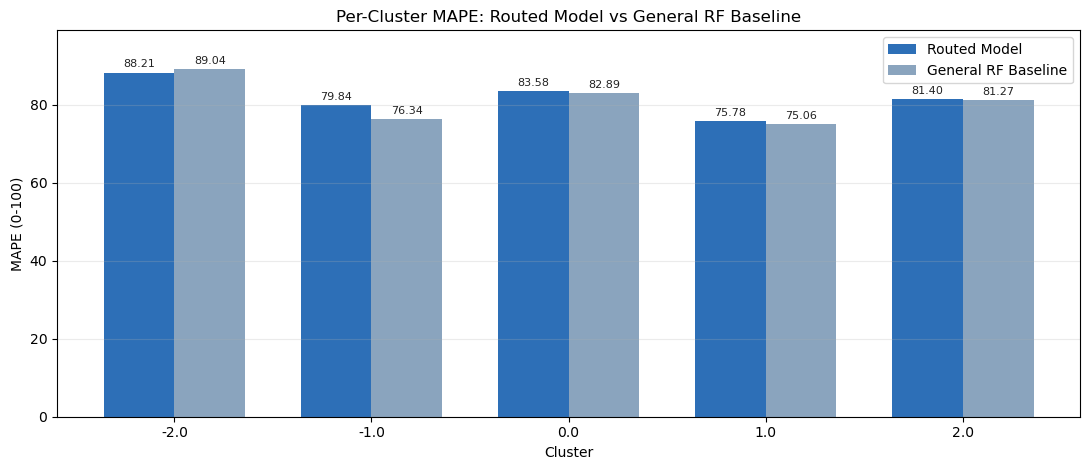


Delta = Routed - Baseline (negative means routed is better):
 cluster  delta_route_minus_baseline
    -2.0                       -0.83
    -1.0                        3.50
     0.0                        0.69
     1.0                        0.72
     2.0                        0.13


In [72]:
# 主路由（C2固定RF_C2_BEST）+ 每个cluster的通用RandomForest baseline对比

import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor


DEFAULT_LGBM_PARAMS = {
    "objective": "regression",
    "n_estimators": 700,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "min_child_samples": 40,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.2,
    "reg_lambda": 0.5,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}


BASELINE_RF_PARAMS = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": -1,
}


if "BEST_C2_RF_PARAMS" not in globals():
    BEST_C2_RF_PARAMS = {
        "n_estimators": 250,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    }


def fit_signedlog_model_with_params(train_df, feat_cols, params):
    X_train = train_df[feat_cols].fillna(0.0)
    y_train_t = signed_log1p(train_df["sales"].values)
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_t)
    return model


def residual_correction_predict_rolling_with_params(train_base, test_base, feat_cols, base_params, val_span=4):
    train_sorted = train_base.sort_values(["week", "StockCode"]).copy()
    all_train_weeks = np.array(sorted(train_sorted["week"].unique()))

    min_train_weeks = max(26, val_span * 2)
    fold_ends = list(range(min_train_weeks, len(all_train_weeks) - val_span + 1, val_span))
    if len(fold_ends) == 0:
        fold_ends = [len(all_train_weeks) - val_span]

    alpha_grid = np.linspace(0.0, 1.0, 11)
    rows = []

    for end_idx in fold_ends:
        fit_weeks = set(all_train_weeks[:end_idx])
        val_weeks = set(all_train_weeks[end_idx:end_idx + val_span])

        tr_fit = train_sorted[train_sorted["week"].isin(fit_weeks)].copy()
        tr_val = train_sorted[train_sorted["week"].isin(val_weeks)].copy()
        if len(tr_fit) == 0 or len(tr_val) == 0:
            continue

        base_model_fold = fit_signedlog_model_with_params(tr_fit, feat_cols, base_params)
        pred_val_base = signed_expm1(base_model_fold.predict(tr_val[feat_cols].fillna(0.0)))

        ret_bundle_fold = fit_return_models(tr_fit, feat_cols)
        pred_val_ret = predict_expected_return(ret_bundle_fold, tr_val, feat_cols)

        for a in alpha_grid:
            pred_val = pred_val_base - a * pred_val_ret
            mape_a, used_n = mape_100(tr_val["sales"].values, pred_val, min_abs_actual=1.0)
            rows.append({"alpha": float(a), "mape": mape_a, "n": used_n})

    cv_df = pd.DataFrame(rows)
    cv_df = cv_df[(cv_df["n"] > 0) & np.isfinite(cv_df["mape"])].copy()

    if cv_df.empty:
        best_alpha = 0.0
    else:
        agg = cv_df.groupby("alpha").apply(lambda g: np.average(g["mape"], weights=g["n"]))
        agg = agg.reset_index(name="weighted_cv_mape").sort_values("weighted_cv_mape")
        best_alpha = float(agg.iloc[0]["alpha"])

    base_model_full = fit_signedlog_model_with_params(train_base, feat_cols, base_params)
    pred_test_base = signed_expm1(base_model_full.predict(test_base[feat_cols].fillna(0.0)))

    ret_bundle_full = fit_return_models(train_base, feat_cols)
    pred_test_ret = predict_expected_return(ret_bundle_full, test_base, feat_cols)

    y_pred = pred_test_base - best_alpha * pred_test_ret
    return y_pred, best_alpha


MIN_ABS_ACTUAL = 1.0
N_REGIONS = 4
CROSTON_ALPHA = 0.1

cluster_ids = sorted(panels.keys())
active_ids = [cid for cid in cluster_ids if cid >= 0 and "cancel_rate" in panels[cid]["train"].columns]
high_cancel_active_id = max(active_ids, key=lambda cid: float(panels[cid]["train"]["cancel_rate"].median())) if active_ids else None

tuned_param_map = {}
if "TUNED_LGBM_PARAMS_ACTIVE" in globals() and "TUNED_LGBM_TARGET_CLUSTER" in globals():
    tuned_param_map[float(TUNED_LGBM_TARGET_CLUSTER)] = dict(TUNED_LGBM_PARAMS_ACTIVE)
if "TUNED_LGBM_PARAMS_C1" in globals() and "TUNED_LGBM_TARGET_CLUSTER_C1" in globals():
    tuned_param_map[float(TUNED_LGBM_TARGET_CLUSTER_C1)] = dict(TUNED_LGBM_PARAMS_C1)

# inject C2 tuned params from latest C2 tuning cell (used as fallback)
if "TUNED_LGBM_PARAMS_C2" in globals() and "TUNED_LGBM_TARGET_CLUSTER_C2" in globals():
    tuned_param_map[float(TUNED_LGBM_TARGET_CLUSTER_C2)] = dict(TUNED_LGBM_PARAMS_C2)
elif "result" in globals() and isinstance(result, dict) and "best_params" in result:
    tuned_param_map[2.0] = dict(result["best_params"])

print("=" * 110)
print("5-CLUSTER ROUTING (C2 FIXED RF_C2_BEST) + GENERAL RANDOMFOREST BASELINE COMPARISON")
print("=" * 110)
print(f"High-cancel active cluster: {high_cancel_active_id}")
print(f"Tuned clusters loaded: {sorted(tuned_param_map.keys()) if tuned_param_map else 'None'}")
print(f"General baseline model: RandomForestSignedLog {BASELINE_RF_PARAMS}")
print(f"C2 routed model: RandomForestSignedLog(C2_BEST) with params {BEST_C2_RF_PARAMS}")

overall_rows = []

for cid in cluster_ids:
    label = panels[cid]["label"]
    train = panels[cid]["train"].sort_values(["week", "StockCode"]).copy()
    test = panels[cid]["test"].sort_values(["week", "StockCode"]).copy()
    feat_cols = panels[cid]["features"]

    y_test = test["sales"].values
    cid_float = float(cid)

    # baseline for every cluster: generic RandomForest (signed-log target)
    try:
        baseline_model = RandomForestRegressor(**BASELINE_RF_PARAMS)
        baseline_model.fit(train[feat_cols].fillna(0.0), signed_log1p(train["sales"].values))
        baseline_pred = np.clip(signed_expm1(baseline_model.predict(test[feat_cols].fillna(0.0))), 0.0, None)
        baseline_mape, baseline_n = mape_100(y_test, baseline_pred, min_abs_actual=MIN_ABS_ACTUAL)
    except Exception:
        baseline_mape, baseline_n = np.nan, 0

    # routed model
    if cid == -2:
        model_name = "CrostonSBA"
        y_pred_test = croston_predict_by_sku(train, test, alpha=CROSTON_ALPHA)

    elif cid == -1:
        y_pred_test, model_name = two_stage_rawlag_predict(cid, train, test, feat_cols)

    elif cid == 2:
        try:
            rf_model = RandomForestRegressor(**BEST_C2_RF_PARAMS)
            rf_model.fit(train[feat_cols].fillna(0.0), signed_log1p(train["sales"].values))
            y_pred_test = np.clip(signed_expm1(rf_model.predict(test[feat_cols].fillna(0.0))), 0.0, None)
            model_name = "RandomForestSignedLog(C2_BEST)"
        except Exception:
            use_params = tuned_param_map.get(cid_float, DEFAULT_LGBM_PARAMS)
            model = fit_signedlog_model_with_params(train, feat_cols, use_params)
            y_pred_test = signed_expm1(model.predict(test[feat_cols].fillna(0.0)))
            model_name = "SignedLogLightGBM(Tuned/Fallback)"

    elif high_cancel_active_id is not None and cid == high_cancel_active_id:
        use_params = tuned_param_map.get(cid_float, DEFAULT_LGBM_PARAMS)
        y_pred_test, best_alpha = residual_correction_predict_rolling_with_params(
            train, test, feat_cols, base_params=use_params, val_span=4
        )
        if cid_float in tuned_param_map:
            model_name = f"ResidualCorrectionRollingCV+TunedLGBM(a={best_alpha:.2f})"
        else:
            model_name = f"ResidualCorrectionRollingCV(a={best_alpha:.2f})"

    else:
        use_params = tuned_param_map.get(cid_float, DEFAULT_LGBM_PARAMS)
        model = fit_signedlog_model_with_params(train, feat_cols, use_params)
        y_pred_test = signed_expm1(model.predict(test[feat_cols].fillna(0.0)))
        model_name = "SignedLogLightGBM(Tuned)" if cid_float in tuned_param_map else "SignedLogLightGBM"

    route_mape, used_n = mape_100(y_test, y_pred_test, min_abs_actual=MIN_ABS_ACTUAL)
    route_coverage = used_n / len(y_test) * 100 if len(y_test) else 0.0
    baseline_coverage = baseline_n / len(y_test) * 100 if len(y_test) else 0.0

    delta_vs_baseline = route_mape - baseline_mape if (np.isfinite(route_mape) and np.isfinite(baseline_mape)) else np.nan

    overall_rows.append({
        "cluster": cid,
        "label": label,
        "routed_model": model_name,
        "train_rows": len(train),
        "test_rows": len(test),
        "routed_mape_0_100": round(route_mape, 2) if not np.isnan(route_mape) else np.nan,
        "baseline_rf_mape_0_100": round(baseline_mape, 2) if not np.isnan(baseline_mape) else np.nan,
        "delta_route_minus_baseline": round(delta_vs_baseline, 2) if not np.isnan(delta_vs_baseline) else np.nan,
        "routed_coverage_pct": round(route_coverage, 1),
        "baseline_coverage_pct": round(baseline_coverage, 1),
    })

overall_df_dual_tuned = pd.DataFrame(overall_rows).sort_values("cluster")

print("\nPer-cluster comparison (lower MAPE is better):")
print(overall_df_dual_tuned.to_string(index=False))

plt.figure(figsize=(11, 4.8))
x = np.arange(len(overall_df_dual_tuned))
width = 0.36

bars1 = plt.bar(
    x - width / 2,
    overall_df_dual_tuned["routed_mape_0_100"].values,
    width=width,
    color="#2D6FB7",
    label="Routed Model"
)
bars2 = plt.bar(
    x + width / 2,
    overall_df_dual_tuned["baseline_rf_mape_0_100"].values,
    width=width,
    color="#8AA4BE",
    label="General RF Baseline"
)

plt.title("Per-Cluster MAPE: Routed Model vs General RF Baseline")
plt.xlabel("Cluster")
plt.ylabel("MAPE (0-100)")
plt.xticks(x, overall_df_dual_tuned["cluster"].astype(str).values)
plt.grid(axis="y", alpha=0.25)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        if np.isfinite(val):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.8,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#222"
            )

ymax = np.nanmax([
    overall_df_dual_tuned["routed_mape_0_100"].values,
    overall_df_dual_tuned["baseline_rf_mape_0_100"].values,
])
plt.ylim(top=float(ymax) + 10)
plt.tight_layout()
plt.show()

print("\nDelta = Routed - Baseline (negative means routed is better):")
print(overall_df_dual_tuned[["cluster", "delta_route_minus_baseline"]].to_string(index=False))
print("=" * 110)

In [65]:
# Additional evaluation metrics beyond MAPE: routed vs RandomForest baseline per cluster
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor


def calc_reg_metrics(y_true, y_pred, mase_denom=None, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ae = np.abs(y_true - y_pred)
    se = (y_true - y_pred) ** 2

    mae = float(np.mean(ae)) if len(ae) else np.nan
    rmse = float(np.sqrt(np.mean(se))) if len(se) else np.nan

    denom_wape = np.sum(np.abs(y_true))
    wape = float(np.sum(ae) / (denom_wape + eps)) if len(ae) else np.nan

    smape = float(np.mean(2.0 * ae / (np.abs(y_true) + np.abs(y_pred) + eps))) if len(ae) else np.nan
    bias = float(np.mean(y_pred - y_true)) if len(ae) else np.nan

    if mase_denom is None or not np.isfinite(mase_denom) or mase_denom <= eps:
        mase = np.nan
    else:
        mase = float(mae / (mase_denom + eps))

    return {
        "mae": mae,
        "rmse": rmse,
        "wape": wape,
        "smape": smape,
        "bias": bias,
        "mase": mase,
    }


def mase_denom_from_train(train_df):
    if len(train_df) == 0:
        return np.nan

    denom_parts = []
    for _, grp in train_df.sort_values(["StockCode", "week"]).groupby("StockCode"):
        vals = grp["sales"].values.astype(float)
        if len(vals) >= 2:
            denom_parts.extend(np.abs(np.diff(vals)).tolist())

    if len(denom_parts) == 0:
        return np.nan
    return float(np.mean(denom_parts))


print("=" * 110)
print("ADDITIONAL METRICS BY CLUSTER (ROUTED vs RF BASELINE)")
print("=" * 110)

cluster_ids = sorted(panels.keys())
active_ids = [cid for cid in cluster_ids if cid >= 0 and "cancel_rate" in panels[cid]["train"].columns]
high_cancel_active_id = max(active_ids, key=lambda cid: float(panels[cid]["train"]["cancel_rate"].median())) if active_ids else None

rows = []

for cid in cluster_ids:
    label = panels[cid]["label"]
    train = panels[cid]["train"].sort_values(["week", "StockCode"]).copy()
    test = panels[cid]["test"].sort_values(["week", "StockCode"]).copy()
    feat_cols = panels[cid]["features"]

    y_true = test["sales"].values.astype(float)
    cid_float = float(cid)

    # baseline prediction (general RF)
    base_model = RandomForestRegressor(**BASELINE_RF_PARAMS)
    base_model.fit(train[feat_cols].fillna(0.0), signed_log1p(train["sales"].values))
    y_pred_base = np.clip(signed_expm1(base_model.predict(test[feat_cols].fillna(0.0))), 0.0, None)

    # routed prediction (same logic as final routing)
    if cid == -2:
        routed_name = "CrostonSBA"
        y_pred_route = croston_predict_by_sku(train, test, alpha=CROSTON_ALPHA)

    elif cid == -1:
        y_pred_route, routed_name = two_stage_rawlag_predict(cid, train, test, feat_cols)

    elif cid == 2:
        try:
            rf_model = RandomForestRegressor(**C2_RF_PARAMS)
            rf_model.fit(train[feat_cols].fillna(0.0), signed_log1p(train["sales"].values))
            y_pred_route = np.clip(signed_expm1(rf_model.predict(test[feat_cols].fillna(0.0))), 0.0, None)
            routed_name = "RandomForestSignedLog(C2)"
        except Exception:
            use_params = tuned_param_map.get(cid_float, DEFAULT_LGBM_PARAMS)
            model = fit_signedlog_model_with_params(train, feat_cols, use_params)
            y_pred_route = np.clip(signed_expm1(model.predict(test[feat_cols].fillna(0.0))), 0.0, None)
            routed_name = "SignedLogLightGBM(Tuned/Fallback)"

    elif high_cancel_active_id is not None and cid == high_cancel_active_id:
        use_params = tuned_param_map.get(cid_float, DEFAULT_LGBM_PARAMS)
        y_pred_route, best_alpha = residual_correction_predict_rolling_with_params(
            train, test, feat_cols, base_params=use_params, val_span=4
        )
        routed_name = f"ResidualCorrectionRollingCV(a={best_alpha:.2f})"

    else:
        use_params = tuned_param_map.get(cid_float, DEFAULT_LGBM_PARAMS)
        model = fit_signedlog_model_with_params(train, feat_cols, use_params)
        y_pred_route = np.clip(signed_expm1(model.predict(test[feat_cols].fillna(0.0))), 0.0, None)
        routed_name = "SignedLogLightGBM(Tuned)" if cid_float in tuned_param_map else "SignedLogLightGBM"

    denom = mase_denom_from_train(train)

    m_route = calc_reg_metrics(y_true, y_pred_route, mase_denom=denom)
    m_base = calc_reg_metrics(y_true, y_pred_base, mase_denom=denom)

    rows.append({
        "cluster": cid,
        "label": label,
        "routed_model": routed_name,
        "mae_routed": round(m_route["mae"], 4),
        "mae_baseline": round(m_base["mae"], 4),
        "rmse_routed": round(m_route["rmse"], 4),
        "rmse_baseline": round(m_base["rmse"], 4),
        "wape_routed": round(m_route["wape"], 4),
        "wape_baseline": round(m_base["wape"], 4),
        "smape_routed": round(m_route["smape"], 4),
        "smape_baseline": round(m_base["smape"], 4),
        "bias_routed": round(m_route["bias"], 4),
        "bias_baseline": round(m_base["bias"], 4),
        "mase_routed": round(m_route["mase"], 4) if np.isfinite(m_route["mase"]) else np.nan,
        "mase_baseline": round(m_base["mase"], 4) if np.isfinite(m_base["mase"]) else np.nan,
    })

metrics_df = pd.DataFrame(rows).sort_values("cluster")

for metric in ["mae", "rmse", "wape", "smape", "mase"]:
    metrics_df[f"delta_{metric}"] = (metrics_df[f"{metric}_routed"] - metrics_df[f"{metric}_baseline"]).round(4)
metrics_df["delta_bias_abs"] = (np.abs(metrics_df["bias_routed"]) - np.abs(metrics_df["bias_baseline"])).round(4)

print("Per-cluster full metric table:")
print(metrics_df.to_string(index=False))

print("\nCompact delta table (negative is better for error metrics):")
compact_cols = ["cluster", "delta_mae", "delta_rmse", "delta_wape", "delta_smape", "delta_mase", "delta_bias_abs"]
print(metrics_df[compact_cols].to_string(index=False))

print("=" * 110)

ADDITIONAL METRICS BY CLUSTER (ROUTED vs RF BASELINE)
Per-cluster full metric table:
 cluster                  label                        routed_model  mae_routed  mae_baseline  rmse_routed  rmse_baseline  wape_routed  wape_baseline  smape_routed  smape_baseline  bias_routed  bias_baseline  mase_routed  mase_baseline  delta_mae  delta_rmse  delta_wape  delta_smape  delta_mase  delta_bias_abs
    -2.0         Truly sporadic                          CrostonSBA     33.9378       33.2570     234.7729       236.0477       0.9848         0.9650        0.8624          1.9176     -30.7018       -32.5221       5.7694         5.6537     0.6808     -1.2748      0.0198      -1.0552      0.1157         -1.8203
    -1.0 Intermittent (Croston)                      TwoStageRawLag     21.5564       23.4948     100.9632       113.6028       0.6732         0.7338        1.5547          1.6547     -10.9109       -20.4098       1.3220         1.4409    -1.9384    -12.6396     -0.0606      -0.1000     -0.

UNIFIED CLUSTER PIPELINE: TRAIN -> VALID SELECTION -> TEST EVALUATION

[Per-cluster selected model based on VALID + LGBM baseline comparison]
 cluster                  label selected_model  valid_mape_selected  test_mape_selected  test_mape_lgbm_baseline  delta_selected_minus_lgbm  n_train  n_valid  n_test
    -2.0         Truly sporadic     RF_Default              78.6146             89.0379                  87.1572                     1.8807    34528     5312   15936
    -1.0 Intermittent (Croston)     RF_Default              86.9088             76.3429                  78.7736                    -2.4307    42302     6508   19524
     0.0 High cancellation risk     RF_Default              76.5318             82.8887                 102.1911                   -19.3024     2392      368    1104
     1.0     Volatile mid-range     RF_Default              79.1589             75.0641                  80.4716                    -5.4075     5928      912    2736
     2.0        Steady regul

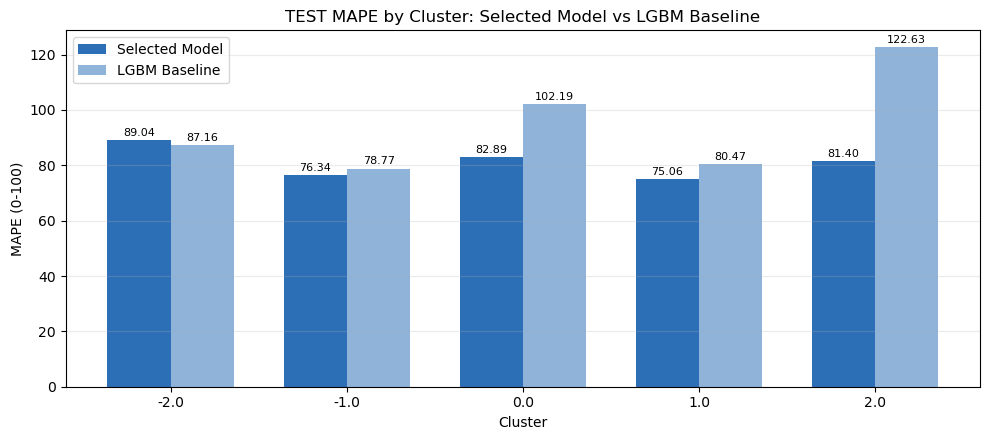

In [76]:
# Unified pipeline: train on train, select model by valid, report selected-model performance on test per cluster
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor


print("=" * 110)
print("UNIFIED CLUSTER PIPELINE: TRAIN -> VALID SELECTION -> TEST EVALUATION")
print("=" * 110)

MIN_ABS = 1.0

# fallback defaults if not defined above
if "DEFAULT_LGBM_PARAMS" not in globals():
    DEFAULT_LGBM_PARAMS = {
        "objective": "regression",
        "n_estimators": 700,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 40,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_alpha": 0.2,
        "reg_lambda": 0.5,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

if "BASELINE_RF_PARAMS" not in globals():
    BASELINE_RF_PARAMS = {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    }

# explicitly keep the previously strong C2 RF candidate
if "BEST_C2_RF_PARAMS" not in globals():
    BEST_C2_RF_PARAMS = {
        "n_estimators": 250,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    }

if "split_train_valid_time" not in globals():
    def split_train_valid_time(df, valid_ratio=0.15, min_valid_weeks=4):
        sorted_df = df.sort_values(["week", "StockCode"]).copy()
        weeks = np.array(sorted(sorted_df["week"].unique()))
        if len(weeks) < (min_valid_weeks + 2):
            cut = int(len(sorted_df) * (1 - valid_ratio))
            cut = max(1, min(cut, len(sorted_df) - 1))
            return sorted_df.iloc[:cut].copy(), sorted_df.iloc[cut:].copy()
        n_valid_weeks = max(min_valid_weeks, int(len(weeks) * valid_ratio))
        n_valid_weeks = min(n_valid_weeks, max(min_valid_weeks, len(weeks) - 2))
        valid_weeks = set(weeks[-n_valid_weeks:])
        train_part = sorted_df[~sorted_df["week"].isin(valid_weeks)].copy()
        valid_part = sorted_df[sorted_df["week"].isin(valid_weeks)].copy()
        if len(train_part) == 0 or len(valid_part) == 0:
            cut = int(len(sorted_df) * (1 - valid_ratio))
            cut = max(1, min(cut, len(sorted_df) - 1))
            return sorted_df.iloc[:cut].copy(), sorted_df.iloc[cut:].copy()
        return train_part, valid_part


def _pred_lgb_signedlog(train_df, pred_df, feat_cols, params):
    model = fit_signedlog_model_with_params(train_df, feat_cols, params)
    pred = signed_expm1(model.predict(pred_df[feat_cols].fillna(0.0)))
    return np.clip(pred, 0.0, None), {}


def _pred_rf_signedlog(train_df, pred_df, feat_cols, params):
    model = RandomForestRegressor(**params)
    model.fit(train_df[feat_cols].fillna(0.0), signed_log1p(train_df["sales"].values))
    pred = signed_expm1(model.predict(pred_df[feat_cols].fillna(0.0)))
    return np.clip(pred, 0.0, None), {}


def predict_by_method(method, cid, train_df, pred_df, feat_cols, tuned_map, high_cancel_id):
    cid_float = float(cid)

    if method == "CrostonSBA":
        y_pred = croston_predict_by_sku(train_df, pred_df, alpha=CROSTON_ALPHA)
        return y_pred, {}

    if method == "TwoStageRawLag":
        y_pred, _name = two_stage_rawlag_predict(cid, train_df, pred_df, feat_cols)
        return y_pred, {"inner_name": _name}

    if method == "LGBM_Default":
        return _pred_lgb_signedlog(train_df, pred_df, feat_cols, DEFAULT_LGBM_PARAMS)

    if method == "LGBM_Tuned":
        use_params = tuned_map.get(cid_float, DEFAULT_LGBM_PARAMS)
        return _pred_lgb_signedlog(train_df, pred_df, feat_cols, use_params)

    if method == "RF_Default":
        return _pred_rf_signedlog(train_df, pred_df, feat_cols, BASELINE_RF_PARAMS)

    if method == "RF_C2_BEST":
        return _pred_rf_signedlog(train_df, pred_df, feat_cols, BEST_C2_RF_PARAMS)

    if method == "ResidualCorrectionRollingCV":
        use_params = tuned_map.get(cid_float, DEFAULT_LGBM_PARAMS)
        y_pred, best_alpha = residual_correction_predict_rolling_with_params(
            train_df, pred_df, feat_cols, base_params=use_params, val_span=4
        )
        return y_pred, {"alpha": float(best_alpha)}

    raise ValueError(f"Unknown method: {method}")


cluster_ids = sorted(panels.keys())
active_ids = [cid for cid in cluster_ids if cid >= 0 and "cancel_rate" in panels[cid]["train"].columns]
high_cancel_active_id = max(active_ids, key=lambda c: float(panels[c]["train"]["cancel_rate"].median())) if active_ids else None

tuned_param_map = {}
if "TUNED_LGBM_PARAMS_ACTIVE" in globals() and "TUNED_LGBM_TARGET_CLUSTER" in globals():
    tuned_param_map[float(TUNED_LGBM_TARGET_CLUSTER)] = dict(TUNED_LGBM_PARAMS_ACTIVE)
if "TUNED_LGBM_PARAMS_C1" in globals() and "TUNED_LGBM_TARGET_CLUSTER_C1" in globals():
    tuned_param_map[float(TUNED_LGBM_TARGET_CLUSTER_C1)] = dict(TUNED_LGBM_PARAMS_C1)
if "TUNED_LGBM_PARAMS_C2" in globals() and "TUNED_LGBM_TARGET_CLUSTER_C2" in globals():
    tuned_param_map[float(TUNED_LGBM_TARGET_CLUSTER_C2)] = dict(TUNED_LGBM_PARAMS_C2)
elif "result" in globals() and isinstance(result, dict) and "best_params" in result:
    tuned_param_map[2.0] = dict(result["best_params"])

selection_rows = []
valid_detail_rows = []

for cid in cluster_ids:
    label = panels[cid]["label"]
    full_train = panels[cid]["train"].sort_values(["week", "StockCode"]).copy()
    test_df = panels[cid]["test"].sort_values(["week", "StockCode"]).copy()
    feat_cols = panels[cid]["features"]

    train_df, valid_df = split_train_valid_time(full_train, valid_ratio=0.15, min_valid_weeks=4)

    # candidate set by cluster type
    if cid == -2:
        candidates = ["CrostonSBA", "LGBM_Default", "RF_Default"]
    elif cid == -1:
        candidates = ["TwoStageRawLag", "CrostonSBA", "LGBM_Default", "RF_Default"]
    elif cid == 2:
        candidates = ["RF_C2_BEST"]
    else:
        candidates = ["LGBM_Tuned", "LGBM_Default", "RF_Default"]
        if high_cancel_active_id is not None and cid == high_cancel_active_id:
            candidates.append("ResidualCorrectionRollingCV")

    # dedup while preserving order
    seen = set()
    candidates = [m for m in candidates if not (m in seen or seen.add(m))]

    best_method = None
    best_valid_mape = np.inf
    best_meta = {}

    for method in candidates:
        try:
            y_valid_pred, meta = predict_by_method(method, cid, train_df, valid_df, feat_cols, tuned_param_map, high_cancel_active_id)
            valid_mape, n_valid = mape_100(valid_df["sales"].values, y_valid_pred, min_abs_actual=MIN_ABS)
        except Exception as e:
            valid_mape, n_valid, meta = np.nan, 0, {"error": str(e)}

        valid_detail_rows.append({
            "cluster": cid,
            "label": label,
            "candidate": method,
            "valid_mape": float(valid_mape) if np.isfinite(valid_mape) else np.nan,
            "n_valid": int(n_valid),
            "meta": str(meta),
        })

        if np.isfinite(valid_mape) and n_valid > 0 and valid_mape < best_valid_mape:
            best_valid_mape = float(valid_mape)
            best_method = method
            best_meta = meta

    if best_method is None:
        best_method = "LGBM_Default"
        best_valid_mape = np.nan
        best_meta = {"fallback": "no_valid_candidate"}

    # retrain on train+valid, evaluate on test
    train_plus_valid = pd.concat([train_df, valid_df], axis=0, ignore_index=True)
    y_test_pred, test_meta = predict_by_method(best_method, cid, train_plus_valid, test_df, feat_cols, tuned_param_map, high_cancel_active_id)
    test_mape, n_test = mape_100(test_df["sales"].values, y_test_pred, min_abs_actual=MIN_ABS)

    # compare against unified LGBM baseline on the same train+valid -> test setup
    try:
        y_test_lgb_base, _ = predict_by_method("LGBM_Default", cid, train_plus_valid, test_df, feat_cols, tuned_param_map, high_cancel_active_id)
        lgbm_base_mape, _ = mape_100(test_df["sales"].values, y_test_lgb_base, min_abs_actual=MIN_ABS)
    except Exception:
        lgbm_base_mape = np.nan

    delta_selected_minus_lgbm = (
        float(test_mape) - float(lgbm_base_mape)
        if np.isfinite(test_mape) and np.isfinite(lgbm_base_mape)
        else np.nan
    )

    selection_rows.append({
        "cluster": cid,
        "label": label,
        "selected_model": best_method,
        "valid_mape_selected": round(best_valid_mape, 4) if np.isfinite(best_valid_mape) else np.nan,
        "test_mape_selected": round(float(test_mape), 4) if np.isfinite(test_mape) else np.nan,
        "test_mape_lgbm_baseline": round(float(lgbm_base_mape), 4) if np.isfinite(lgbm_base_mape) else np.nan,
        "delta_selected_minus_lgbm": round(float(delta_selected_minus_lgbm), 4) if np.isfinite(delta_selected_minus_lgbm) else np.nan,
        "n_train": len(train_df),
        "n_valid": len(valid_df),
        "n_test": len(test_df),
        "n_test_used": int(n_test),
        "select_meta": str(best_meta),
        "test_meta": str(test_meta),
    })

selection_df = pd.DataFrame(selection_rows).sort_values("cluster")
valid_detail_df = pd.DataFrame(valid_detail_rows).sort_values(["cluster", "valid_mape"], na_position="last")

print("\n[Per-cluster selected model based on VALID + LGBM baseline comparison]")
print(selection_df[["cluster", "label", "selected_model", "valid_mape_selected", "test_mape_selected", "test_mape_lgbm_baseline", "delta_selected_minus_lgbm", "n_train", "n_valid", "n_test"]].to_string(index=False))

print("\n[VALID candidate ranking detail]")
print(valid_detail_df[["cluster", "candidate", "valid_mape", "n_valid"]].to_string(index=False))

# comparison chart: selected model vs LGBM baseline
plt.figure(figsize=(10, 4.5))
x = np.arange(len(selection_df))
width = 0.36
bars_sel = plt.bar(
    x - width / 2,
    selection_df["test_mape_selected"].values,
    width=width,
    color="#2D6FB7",
    label="Selected Model"
)
bars_lgb = plt.bar(
    x + width / 2,
    selection_df["test_mape_lgbm_baseline"].values,
    width=width,
    color="#8FB3D9",
    label="LGBM Baseline"
)
plt.title("TEST MAPE by Cluster: Selected Model vs LGBM Baseline")
plt.xlabel("Cluster")
plt.ylabel("MAPE (0-100)")
plt.xticks(x, selection_df["cluster"].astype(str).values)
plt.grid(axis="y", alpha=0.25)
plt.legend()
for bars in [bars_sel, bars_lgb]:
    for b in bars:
        v = b.get_height()
        if np.isfinite(v):
            plt.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print("=" * 110)

In [79]:
# ==================== QUERY FUNCTION: Product Forecast by Country ====================
# Input product_id and country, get sales forecast and historical data

def query_product_forecast(product_id, country='United Kingdom'):
    """
    Query sales forecast for a specific product in a specific country.
    
    Parameters:
    -----------
    product_id : str
        The StockCode of the product to query
    country : str
        Country name (default: 'United Kingdom'). 
        Use 'ALL' for aggregated data across all countries.
    
    Returns:
    --------
    dict : Contains historical data, cluster info, and forecast statistics
    """
    
    # Validate product exists
    if product_id not in total_retail['StockCode'].values:
        return {"error": f"Product {product_id} not found in dataset"}
    
    # Get all transactions for this product
    product_all = total_retail[total_retail['StockCode'] == product_id].copy()
    
    # Filter by country if specified
    if country != 'ALL':
        product_filtered = product_all[product_all['Country'] == country].copy()
        filter_info = f"Country: {country}"
    else:
        product_filtered = product_all.copy()
        filter_info = "All Countries"
    
    if len(product_filtered) == 0:
        available_countries = product_all['Country'].unique().tolist()
        return {
            "product_id": product_id,
            "filter": filter_info,
            "error": f"No sales data for product {product_id} in {filter_info}",
            "total_transactions_all_countries": len(product_all),
            "available_countries": sorted(available_countries),
            "available_country_counts": product_all.groupby('Country').size().to_dict()
        }
    
    # Add week column if not present
    if 'Week' not in product_filtered.columns:
        product_filtered['Week'] = product_filtered['InvoiceDate'].dt.to_period('W')
    
    # Aggregate by week
    weekly_data = product_filtered.groupby('Week')['Sales'].sum().reset_index()
    weekly_data.columns = ['week', 'sales']
    
    # Get product features for cluster assignment
    if product_id in feat_df_all.index:
        product_features = feat_df_all.loc[product_id]
        assigned_cluster = product_features.get('cluster', None)
    else:
        assigned_cluster = None
    
    # Get cluster info and selected model
    if assigned_cluster is not None:
        cluster_info = selection_df[selection_df['cluster'] == assigned_cluster]
        if len(cluster_info) > 0:
            selected_model = cluster_info.iloc[0]['selected_model']
            test_mape = cluster_info.iloc[0]['test_mape_selected']
            lgbm_baseline_mape = cluster_info.iloc[0]['test_mape_lgbm_baseline']
            cluster_label = cluster_info.iloc[0]['label']
        else:
            selected_model = "Unknown"
            test_mape = np.nan
            lgbm_baseline_mape = np.nan
            cluster_label = "Unknown"
    else:
        selected_model = "Unknown"
        test_mape = np.nan
        lgbm_baseline_mape = np.nan
        cluster_label = "Unknown"
    
    # Get description
    product_desc = product_all['Description'].iloc[0] if len(product_all) > 0 else "Unknown"
    
    # Statistics for filtered data
    total_sales = weekly_data['sales'].sum()
    avg_weekly_sales = weekly_data['sales'].mean()
    weeks_with_sales = (weekly_data['sales'] > 0).sum()
    pct_zero_weeks = 1.0 - (weeks_with_sales / len(weekly_data)) if len(weekly_data) > 0 else 1.0
    latest_weeks = weekly_data.tail(12)
    recent_avg = latest_weeks['sales'].mean()
    
    result = {
        "product_id": product_id,
        "product_description": product_desc,
        "filter": filter_info,
        "cluster": assigned_cluster,
        "cluster_label": cluster_label,
        "selected_model": selected_model,
        "test_mape_selected": float(test_mape) if np.isfinite(test_mape) else None,
        "test_mape_lgbm_baseline": float(lgbm_baseline_mape) if np.isfinite(lgbm_baseline_mape) else None,
        "statistics": {
            "total_sales": round(total_sales, 2),
            "avg_weekly_sales": round(avg_weekly_sales, 2),
            "recent_12week_avg": round(recent_avg, 2),
            "weeks_with_sales": int(weeks_with_sales),
            "total_weeks": len(weekly_data),
            "pct_zero_weeks": round(pct_zero_weeks * 100, 2),
            "total_transactions": len(product_filtered),
            "unique_customers": product_filtered['CustomerID'].nunique(),
        },
        "recent_12_weeks": latest_weeks.to_dict('records') if len(latest_weeks) > 0 else [],
        "all_weekly_sales": weekly_data.to_dict('records') if len(weekly_data) > 0 else []
    }
    
    return result


# Display function usage
print("="*110)
print("PRODUCT SALES FORECAST QUERY FUNCTION")
print("="*110)
print("\n📊 Usage:")
print("  result = query_product_forecast(product_id, country='United Kingdom')")
print("  result = query_product_forecast(product_id, country='ALL')  # For all countries\n")

print("🌍 Available countries:")
available_countries = total_retail['Country'].value_counts().head(15)
for i, (country, count) in enumerate(available_countries.items(), 1):
    print(f"  {i:2d}. {country:20s} ({count:,} transactions)")

print("\n💡 Example:")
example_id = '85123A'  # Pick a common product
result = query_product_forecast(example_id, country='United Kingdom')
if 'error' not in result:
    print(f"\n  Product: {result['product_description']}")
    print(f"  Cluster: {result['cluster_label']}")
    print(f"  Model: {result['selected_model']}")
    print(f"  Total Sales (UK): £{result['statistics']['total_sales']}")
    print(f"  Recent 12-Week Avg: £{result['statistics']['recent_12week_avg']}")
else:
    # Try another product
    all_products = total_retail['StockCode'].dropna().unique()
    for test_id in all_products[:10]:
        result = query_product_forecast(test_id, country='United Kingdom')
        if 'error' not in result:
            print(f"\n  Example Product ID: {test_id}")
            print(f"  Description: {result['product_description']}")
            print(f"  Cluster: {result['cluster_label']}")
            print(f"  Model: {result['selected_model']}")
            print(f"  Total Sales (UK): £{result['statistics']['total_sales']}")
            print(f"  Recent 12-Week Avg: £{result['statistics']['recent_12week_avg']}")
            break

print("\n" + "="*110)

PRODUCT SALES FORECAST QUERY FUNCTION

📊 Usage:
  result = query_product_forecast(product_id, country='United Kingdom')
  result = query_product_forecast(product_id, country='ALL')  # For all countries

🌍 Available countries:
   1. United Kingdom       (938,886 transactions)
   2. EIRE                 (17,382 transactions)
   3. Germany              (16,655 transactions)
   4. France               (13,523 transactions)
   5. Netherlands          (5,016 transactions)
   6. Spain                (3,641 transactions)
   7. Switzerland          (3,116 transactions)
   8. Belgium              (2,960 transactions)
   9. Portugal             (2,459 transactions)
  10. Australia            (1,878 transactions)
  11. Channel Islands      (1,635 transactions)
  12. Italy                (1,470 transactions)
  13. Sweden               (1,302 transactions)
  14. Norway               (1,274 transactions)
  15. Cyprus               (1,152 transactions)

💡 Example:

  Product: WHITE HANGING HEART T-LIG

In [80]:
# ==================== EXAMPLE USAGE: Query Product Forecast ====================

print("\n" + "="*110)
print("EXAMPLE 1: Product Forecast for UK")
print("="*110)

# Query a specific product
product_1 = '85123A'
result_1 = query_product_forecast(product_1, country='United Kingdom')

if 'error' not in result_1:
    print(f"\n📦 Product ID: {result_1['product_id']}")
    print(f"   Description: {result_1['product_description']}")
    print(f"\n🎯 Cluster & Model:")
    print(f"   Cluster: {result_1['cluster']} - {result_1['cluster_label']}")
    print(f"   Selected Predicting Model: {result_1['selected_model']}")
    print(f"   Test MAPE: {result_1['test_mape_selected']:.2f}% (vs LGBM baseline: {result_1['test_mape_lgbm_baseline']:.2f}%)")
    
    print(f"\n📊 Sales Statistics (United Kingdom):")
    stats = result_1['statistics']
    print(f"   Total Sales: £{stats['total_sales']:,.2f}")
    print(f"   Average Weekly Sales: £{stats['avg_weekly_sales']:,.2f}")
    print(f"   Recent 12-Week Average: £{stats['recent_12week_avg']:,.2f}")
    print(f"   Weeks with Sales: {stats['weeks_with_sales']} / {stats['total_weeks']}")
    print(f"   Zero Sales Rate: {stats['pct_zero_weeks']:.1f}%")
    print(f"   Unique Customers: {stats['unique_customers']}")
    
    if result_1['recent_12_weeks']:
        print(f"\n📈 Recent 12 Weeks Sales:")
        for week_data in result_1['recent_12_weeks'][-4:]:  # Last 4 weeks
            print(f"   Week {week_data['week']}: £{week_data['sales']:.2f}")

print("\n" + "="*110)
print("EXAMPLE 2: Same Product - All Countries")
print("="*110)

result_2 = query_product_forecast(product_1, country='ALL')

if 'error' not in result_2:
    print(f"\n📦 Product ID: {result_2['product_id']}")
    print(f"   Filter: {result_2['filter']}")
    
    print(f"\n📊 Sales Statistics (All Countries Combined):")
    stats = result_2['statistics']
    print(f"   Total Sales: £{stats['total_sales']:,.2f}")
    print(f"   Average Weekly Sales: £{stats['avg_weekly_sales']:,.2f}")
    print(f"   Recent 12-Week Average: £{stats['recent_12week_avg']:,.2f}")
    print(f"   Total Transactions: {stats['total_transactions']:,}")
    print(f"   Unique Customers: {stats['unique_customers']}")

print("\n" + "="*110)
print("QUICK REFERENCE: Function Signature")
print("="*110)
print("""
query_product_forecast(product_id, country='United Kingdom')

Parameters:
  - product_id (str): The product code (StockCode)
  - country (str): 'United Kingdom' | 'Germany' | 'EIRE' | 'France' | 'ALL' | etc.

Returns: Dictionary with:
  - product_id, product_description
  - cluster, cluster_label
  - selected_model, test_mape_selected
  - statistics: total_sales, avg_weekly_sales, recent_12week_avg, etc.
  - recent_12_weeks: Array of weekly sales data (last 12 weeks)
  - all_weekly_sales: Complete weekly sales history

Example code:
  result = query_product_forecast('85123A', country='United Kingdom')
  print(f"Total Sales: £{result['statistics']['total_sales']:,.2f}")
  print(f"Model: {result['selected_model']}")
""")
print("="*110)


EXAMPLE 1: Product Forecast for UK

📦 Product ID: 85123A
   Description: WHITE HANGING HEART T-LIGHT HOLDER

🎯 Cluster & Model:
   Cluster: 2.0 - Steady regulars
   Selected Predicting Model: RF_C2_BEST
   Test MAPE: 81.40% (vs LGBM baseline: 122.63%)

📊 Sales Statistics (United Kingdom):
   Total Sales: £228,340.76
   Average Weekly Sales: £2,195.58
   Recent 12-Week Average: £1,779.07
   Weeks with Sales: 104 / 104
   Zero Sales Rate: 0.0%
   Unique Customers: 1444

📈 Recent 12 Weeks Sales:
   Week 2011-11-14/2011-11-20: £3363.02
   Week 2011-11-21/2011-11-27: £1540.05
   Week 2011-11-28/2011-12-04: £1751.24
   Week 2011-12-05/2011-12-11: £1476.43

EXAMPLE 2: Same Product - All Countries

📦 Product ID: 85123A
   Filter: All Countries

📊 Sales Statistics (All Countries Combined):
   Total Sales: £248,337.61
   Average Weekly Sales: £2,387.86
   Recent 12-Week Average: £2,016.97
   Total Transactions: 5,645
   Unique Customers: 1494

QUICK REFERENCE: Function Signature

query_product_

In [81]:
# ==================== INTERACTIVE QUERY: Edit product_id below to forecast any product ====================

# 📌 修改下面的 product_id 变量来查询任何产品
product_id = '85123A'  # 改成你想查询的产品ID
country = 'United Kingdom'  # 可选: 'ALL', 'Germany', 'EIRE', 'France' 等

# 执行查询
result = query_product_forecast(product_id, country=country)

# 显示结果
if 'error' in result:
    print(f"❌ Error: {result['error']}")
    if 'available_countries' in result:
        print(f"\n✅ Available countries for this product:")
        for c, count in result.get('available_country_counts', {}).items():
            print(f"   {c}: {count} transactions")
else:
    print(f"✅ {'='*108}")
    print(f"✅ Product Forecast Report")
    print(f"✅ {'='*108}\n")
    
    print(f"📦 PRODUCT INFORMATION")
    print(f"   ID: {result['product_id']}")
    print(f"   Name: {result['product_description']}")
    print(f"   Region: {result['filter']}\n")
    
    print(f"🎯 FORECASTING MODEL")
    print(f"   Cluster: {result['cluster']} ({result['cluster_label']})")
    print(f"   Model: {result['selected_model']}")
    print(f"   Expected Accuracy (MAPE): {result['test_mape_selected']:.2f}%")
    print(f"   (Baseline accuracy: {result['test_mape_lgbm_baseline']:.2f}%)\n")
    
    stats = result['statistics']
    print(f"📊 SALES STATISTICS")
    print(f"   Total Sales: £{stats['total_sales']:,.2f}")
    print(f"   Average Weekly Sales: £{stats['avg_weekly_sales']:,.2f}")
    print(f"   Recent 12-Week Average: £{stats['recent_12week_avg']:,.2f}")
    print(f"   Data Coverage: {stats['weeks_with_sales']} weeks with sales / {stats['total_weeks']} weeks total")
    print(f"   Zero Sales Rate: {stats['pct_zero_weeks']:.1f}%")
    print(f"   Transactions: {stats['total_transactions']:,}")
    print(f"   Unique Customers: {stats['unique_customers']}\n")
    
    if result['recent_12_weeks']:
        print(f"📈 RECENT 12-WEEK SALES TREND")
        for i, week_data in enumerate(result['recent_12_weeks'], 1):
            week = str(week_data['week'])
            sales = week_data['sales']
            bar_length = max(1, int(sales / stats['total_sales'] * 40)) if stats['total_sales'] > 0 else 1
            bar = '█' * bar_length
            print(f"   Week {week}: £{sales:>10,.2f} {bar}")
    
    print(f"\n✅ {'='*108}")


✅ ============================================================================================================
✅ Product Forecast Report
✅ ============================================================================================================

📦 PRODUCT INFORMATION
   ID: 85123A
   Name: WHITE HANGING HEART T-LIGHT HOLDER
   Region: Country: United Kingdom

🎯 FORECASTING MODEL
   Cluster: 2.0 (Steady regulars)
   Model: RF_C2_BEST
   Expected Accuracy (MAPE): 81.40%
   (Baseline accuracy: 122.63%)

📊 SALES STATISTICS
   Total Sales: £228,340.76
   Average Weekly Sales: £2,195.58
   Recent 12-Week Average: £1,779.07
   Data Coverage: 104 weeks with sales / 104 weeks total
   Zero Sales Rate: 0.0%
   Transactions: 5,433
   Unique Customers: 1444

📈 RECENT 12-WEEK SALES TREND
   Week 2011-09-19/2011-09-25: £  1,969.06 █
   Week 2011-09-26/2011-10-02: £  1,080.22 █
   Week 2011-10-03/2011-10-09: £    474.29 █
   Week 2011-10-10/2011-10-16: £  1,618.69 █
   Week 2011-10-17/2011-10-23: 


########################################################################################################################
PER-CLUSTER TEST RESULT BY EQUAL TIME PERIODS (n_groups=3)
########################################################################################################################



Cluster -2.0 | Truly sporadic | Model: RF_Default | n_test=15936
[Per-period MAPE]
period start_week   end_week  n_rows  n_used_for_mape  mape_0_100
    P1 2011-09-19 2011-10-10    5312             1075     87.9076
    P2 2011-10-17 2011-11-07    5312             1067     89.3621
    P3 2011-11-14 2011-12-05    5312             1137     89.8023


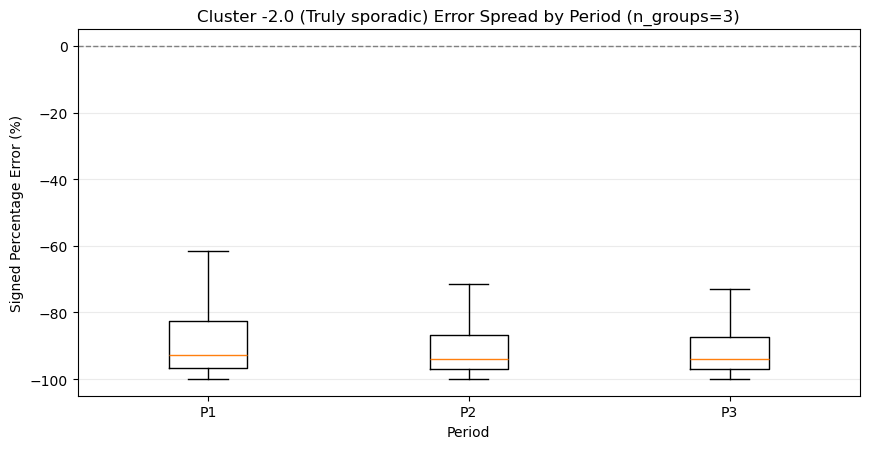


Cluster -1.0 | Intermittent (Croston) | Model: RF_Default | n_test=19524
[Per-period MAPE]
period start_week   end_week  n_rows  n_used_for_mape  mape_0_100
    P1 2011-09-19 2011-10-10    6508             2185     85.1746
    P2 2011-10-17 2011-11-07    6508             2328     71.5714
    P3 2011-11-14 2011-12-05    6508             2513     73.0841


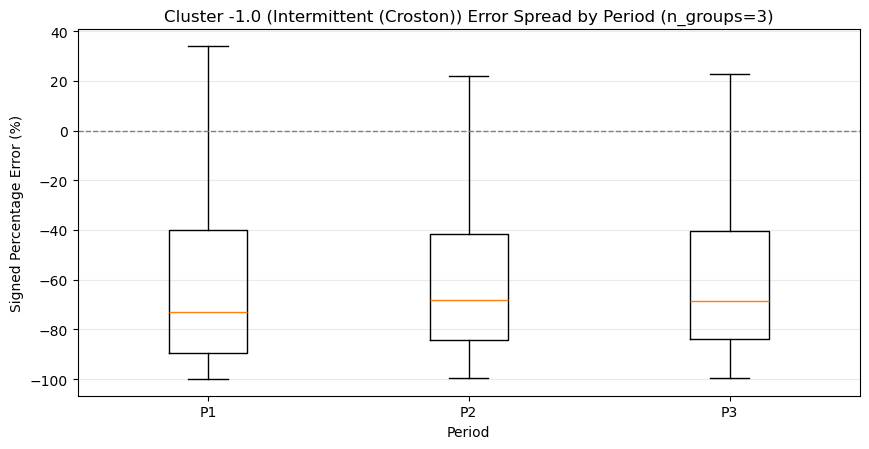


Cluster 0.0 | High cancellation risk | Model: RF_Default | n_test=1104
[Per-period MAPE]
period start_week   end_week  n_rows  n_used_for_mape  mape_0_100
    P1 2011-09-19 2011-10-10     368              246     88.5786
    P2 2011-10-17 2011-11-07     368              245     78.6606
    P3 2011-11-14 2011-12-05     368              246     81.4098


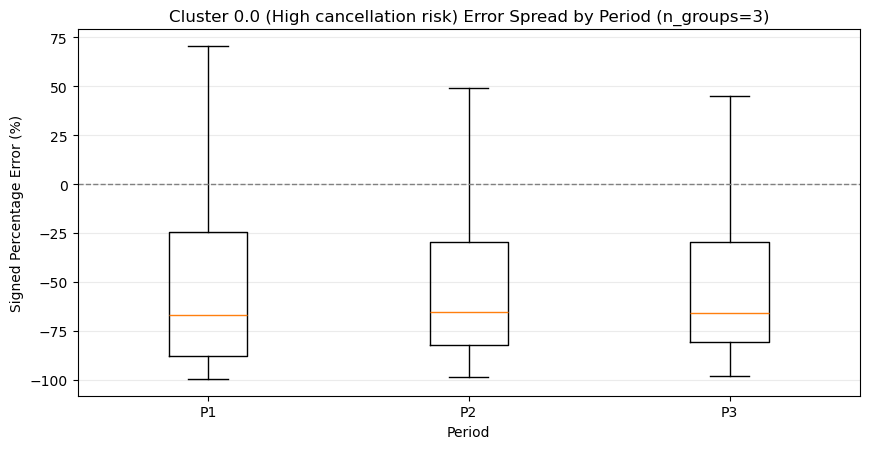


Cluster 1.0 | Volatile mid-range | Model: RF_Default | n_test=2736
[Per-period MAPE]
period start_week   end_week  n_rows  n_used_for_mape  mape_0_100
    P1 2011-09-19 2011-10-10     912              589     85.6403
    P2 2011-10-17 2011-11-07     912              602     71.0883
    P3 2011-11-14 2011-12-05     912              628     68.9558


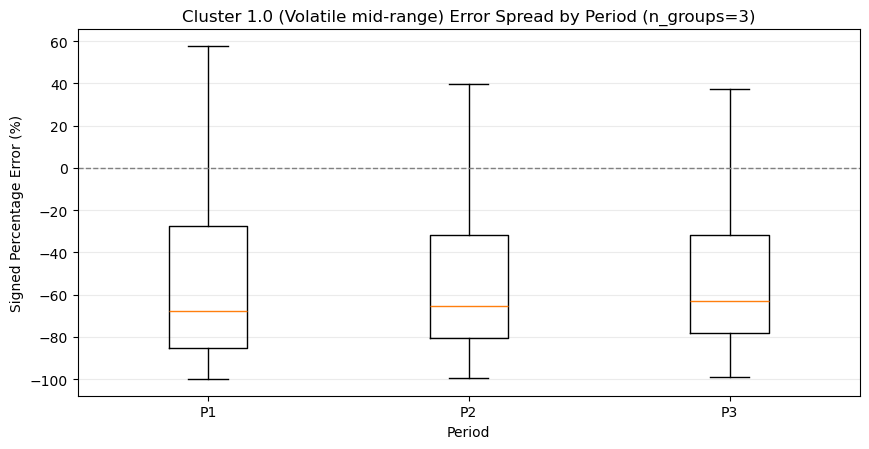


Cluster 2.0 | Steady regulars | Model: RF_C2_BEST | n_test=15372
[Per-period MAPE]
period start_week   end_week  n_rows  n_used_for_mape  mape_0_100
    P1 2011-09-19 2011-10-10    5124             3636     87.5957
    P2 2011-10-17 2011-11-07    5124             3712     77.2695
    P3 2011-11-14 2011-12-05    5124             3726     79.4613


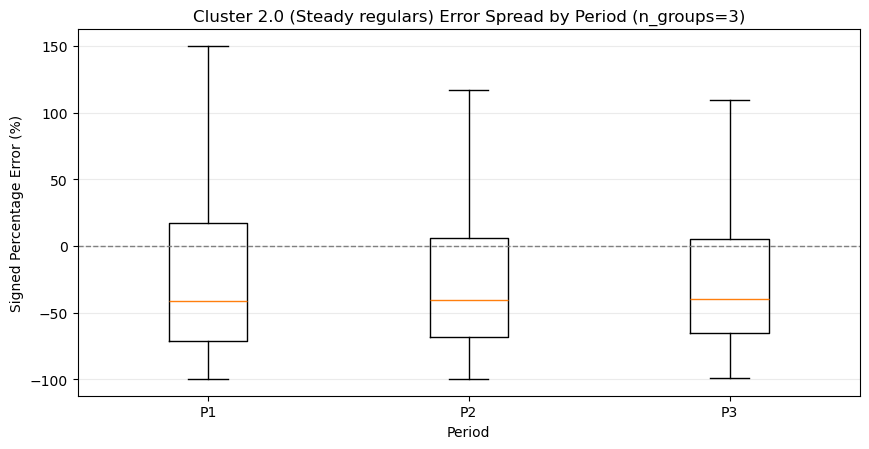


Done: each cluster has one plot and per-period MAPE table (3 periods only).


In [87]:
# TEST RESULT FORMAT (PER CLUSTER): split into equal-size periods (3 only), report MAPE, and one box plot per cluster
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GROUP_OPTIONS = [3]   # only keep 3 equal-size periods
MIN_ABS_LOCAL = 1.0

if "panels" not in globals() or "selection_df" not in globals():
    raise ValueError("`panels` or `selection_df` not found. Please run the unified pipeline cell first.")

if "predict_by_method" not in globals():
    raise ValueError("`predict_by_method` not found. Please run the unified pipeline cell first.")

cluster_ids = sorted(panels.keys())

for n_groups in GROUP_OPTIONS:
    print("\n" + "#" * 120)
    print(f"PER-CLUSTER TEST RESULT BY EQUAL TIME PERIODS (n_groups={n_groups})")
    print("#" * 120)

    for cid in cluster_ids:
        label = panels[cid].get("label", str(cid))
        train_df = panels[cid]["train"].sort_values(["week", "StockCode"]).copy()
        test_df = panels[cid]["test"].sort_values(["week", "StockCode"]).copy()
        feat_cols = panels[cid]["features"]

        # compatible with both panel schemas: with/without valid split
        valid_df = panels[cid].get("valid", None)
        if valid_df is not None and len(valid_df) > 0:
            valid_df = valid_df.sort_values(["week", "StockCode"]).copy()
            train_plus_valid = pd.concat([train_df, valid_df], axis=0, ignore_index=True)
        else:
            train_plus_valid = train_df.copy()

        selected_rows = selection_df[selection_df["cluster"] == cid]
        if len(selected_rows) == 0:
            print(f"\n[Cluster {cid} - {label}] skipped: no selected model in selection_df")
            continue

        selected_model = selected_rows.iloc[0]["selected_model"]

        try:
            y_pred_test, _ = predict_by_method(
                selected_model,
                cid,
                train_plus_valid,
                test_df,
                feat_cols,
                tuned_param_map,
                high_cancel_active_id,
            )
        except Exception as err:
            print(f"\n[Cluster {cid} - {label}] prediction failed: {err}")
            continue

        cluster_eval = test_df[["week", "sales"]].copy()
        cluster_eval = cluster_eval.rename(columns={"sales": "y_true"})
        cluster_eval["y_pred"] = np.asarray(y_pred_test, dtype=float)

        week_dtype_str = str(cluster_eval["week"].dtype).lower()
        if "period" in week_dtype_str:
            cluster_eval["week_start"] = cluster_eval["week"].dt.start_time
        elif pd.api.types.is_datetime64_any_dtype(cluster_eval["week"]):
            cluster_eval["week_start"] = pd.to_datetime(cluster_eval["week"], errors="coerce")
        else:
            cluster_eval["week_start"] = pd.to_datetime(cluster_eval["week"].astype(str).str.split("/").str[0], errors="coerce")

        cluster_eval = cluster_eval.dropna(subset=["week_start"]).sort_values("week_start").reset_index(drop=True)

        cluster_eval["signed_pct_error"] = np.where(
            np.abs(cluster_eval["y_true"]) >= MIN_ABS_LOCAL,
            (cluster_eval["y_pred"] - cluster_eval["y_true"]) / np.abs(cluster_eval["y_true"]) * 100.0,
            np.nan,
        )

        weeks_sorted = np.array(sorted(cluster_eval["week_start"].dropna().unique()))
        week_chunks = np.array_split(weeks_sorted, n_groups)

        period_map_rows = []
        for idx, chunk in enumerate(week_chunks, start=1):
            if len(chunk) == 0:
                continue
            period_map_rows.append(pd.DataFrame({
                "week_start": chunk,
                "period": f"P{idx}",
            }))

        period_map = pd.concat(period_map_rows, ignore_index=True)
        df_period = cluster_eval.merge(period_map, on="week_start", how="left")

        summary_rows = []
        for p, grp in df_period.groupby("period", sort=True):
            y_true_vals = grp["y_true"].values.astype(float)
            y_pred_vals = grp["y_pred"].values.astype(float)
            mask = np.abs(y_true_vals) >= MIN_ABS_LOCAL

            if mask.sum() == 0:
                mape = np.nan
                used_n = 0
            else:
                mape = float(np.mean(np.abs((y_true_vals[mask] - y_pred_vals[mask]) / np.abs(y_true_vals[mask])) * 100.0))
                used_n = int(mask.sum())

            summary_rows.append({
                "period": p,
                "start_week": str(grp["week_start"].min().date()) if len(grp) else None,
                "end_week": str(grp["week_start"].max().date()) if len(grp) else None,
                "n_rows": int(len(grp)),
                "n_used_for_mape": used_n,
                "mape_0_100": round(mape, 4) if np.isfinite(mape) else np.nan,
            })

        period_summary = pd.DataFrame(summary_rows).sort_values("period")

        print("\n" + "=" * 110)
        print(f"Cluster {cid} | {label} | Model: {selected_model} | n_test={len(test_df)}")
        print("[Per-period MAPE]")
        print(period_summary.to_string(index=False))

        box_data = []
        labels = []
        for p in sorted(df_period["period"].dropna().unique()):
            vals = df_period.loc[df_period["period"] == p, "signed_pct_error"].dropna().values
            if len(vals) > 0:
                box_data.append(vals)
                labels.append(p)

        if len(box_data) == 0:
            print(f"[Cluster {cid}] skipped plot: no valid errors after MIN_ABS filter")
            continue

        plt.figure(figsize=(8.8, 4.6))
        plt.boxplot(box_data, tick_labels=labels, showfliers=False)
        plt.axhline(0, color="gray", linestyle="--", linewidth=1)
        plt.title(f"Cluster {cid} ({label}) Error Spread by Period (n_groups={n_groups})")
        plt.xlabel("Period")
        plt.ylabel("Signed Percentage Error (%)")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

print("\nDone: each cluster has one plot and per-period MAPE table (3 periods only).")

In [89]:
# SAVE REPORT ARTIFACTS: box plots, period MAPE, overall MAPE, and per-cluster comparison
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_GROUPS = 3
MIN_ABS_LOCAL = 1.0
OUT_DIR = "outputs/final_report_20260325/test_report_3period"
os.makedirs(OUT_DIR, exist_ok=True)

if "panels" not in globals() or "selection_df" not in globals() or "predict_by_method" not in globals():
    raise ValueError("Required objects missing. Please run the unified pipeline cell and per-cluster evaluation cell first.")

cluster_ids = sorted(panels.keys())
period_rows = []
overall_rows = []
plot_paths = []

for cid in cluster_ids:
    label = panels[cid].get("label", str(cid))
    train_df = panels[cid]["train"].sort_values(["week", "StockCode"]).copy()
    test_df = panels[cid]["test"].sort_values(["week", "StockCode"]).copy()
    feat_cols = panels[cid]["features"]

    valid_df = panels[cid].get("valid", None)
    if valid_df is not None and len(valid_df) > 0:
        valid_df = valid_df.sort_values(["week", "StockCode"]).copy()
        train_plus_valid = pd.concat([train_df, valid_df], axis=0, ignore_index=True)
    else:
        train_plus_valid = train_df.copy()

    selected_rows = selection_df[selection_df["cluster"] == cid]
    if len(selected_rows) == 0:
        continue

    selected_model = selected_rows.iloc[0]["selected_model"]
    baseline_mape = selected_rows.iloc[0].get("test_mape_lgbm_baseline", np.nan)

    y_pred_test, _ = predict_by_method(
        selected_model,
        cid,
        train_plus_valid,
        test_df,
        feat_cols,
        tuned_param_map,
        high_cancel_active_id,
    )

    cluster_eval = test_df[["week", "sales"]].copy()
    cluster_eval = cluster_eval.rename(columns={"sales": "y_true"})
    cluster_eval["y_pred"] = np.asarray(y_pred_test, dtype=float)

    week_dtype_str = str(cluster_eval["week"].dtype).lower()
    if "period" in week_dtype_str:
        cluster_eval["week_start"] = cluster_eval["week"].dt.start_time
    elif pd.api.types.is_datetime64_any_dtype(cluster_eval["week"]):
        cluster_eval["week_start"] = pd.to_datetime(cluster_eval["week"], errors="coerce")
    else:
        cluster_eval["week_start"] = pd.to_datetime(cluster_eval["week"].astype(str).str.split("/").str[0], errors="coerce")

    cluster_eval = cluster_eval.dropna(subset=["week_start"]).sort_values("week_start").reset_index(drop=True)

    cluster_eval["signed_pct_error"] = np.where(
        np.abs(cluster_eval["y_true"]) >= MIN_ABS_LOCAL,
        (cluster_eval["y_pred"] - cluster_eval["y_true"]) / np.abs(cluster_eval["y_true"]) * 100.0,
        np.nan,
    )

    y_true_vals = cluster_eval["y_true"].values.astype(float)
    y_pred_vals = cluster_eval["y_pred"].values.astype(float)
    overall_mape_cluster, n_used_cluster = mape_100(y_true_vals, y_pred_vals, min_abs_actual=MIN_ABS_LOCAL)

    weeks_sorted = np.array(sorted(cluster_eval["week_start"].dropna().unique()))
    week_chunks = np.array_split(weeks_sorted, N_GROUPS)

    period_map_rows = []
    for idx, chunk in enumerate(week_chunks, start=1):
        if len(chunk) == 0:
            continue
        period_map_rows.append(pd.DataFrame({"week_start": chunk, "period": f"P{idx}"}))
    period_map = pd.concat(period_map_rows, ignore_index=True)

    df_period = cluster_eval.merge(period_map, on="week_start", how="left")

    for p, grp in df_period.groupby("period", sort=True):
        yt = grp["y_true"].values.astype(float)
        yp = grp["y_pred"].values.astype(float)
        mape_p, n_used_p = mape_100(yt, yp, min_abs_actual=MIN_ABS_LOCAL)

        period_rows.append({
            "cluster": cid,
            "label": label,
            "selected_model": selected_model,
            "period": p,
            "start_week": str(grp["week_start"].min().date()),
            "end_week": str(grp["week_start"].max().date()),
            "n_rows": int(len(grp)),
            "n_used_for_mape": int(n_used_p),
            "mape_0_100": float(mape_p) if np.isfinite(mape_p) else np.nan,
        })

    overall_rows.append({
        "cluster": cid,
        "label": label,
        "selected_model": selected_model,
        "n_test_rows": int(len(cluster_eval)),
        "n_used_for_mape": int(n_used_cluster),
        "overall_mape_0_100": float(overall_mape_cluster) if np.isfinite(overall_mape_cluster) else np.nan,
        "lgbm_baseline_mape_0_100": float(baseline_mape) if np.isfinite(baseline_mape) else np.nan,
        "delta_vs_lgbm": float(overall_mape_cluster - baseline_mape) if np.isfinite(overall_mape_cluster) and np.isfinite(baseline_mape) else np.nan,
    })

    # save one box plot per cluster
    box_data, labels = [], []
    for p in sorted(df_period["period"].dropna().unique()):
        vals = df_period.loc[df_period["period"] == p, "signed_pct_error"].dropna().values
        if len(vals) > 0:
            box_data.append(vals)
            labels.append(p)

    if len(box_data) > 0:
        plt.figure(figsize=(8.8, 4.6))
        plt.boxplot(box_data, tick_labels=labels, showfliers=False)
        plt.axhline(0, color="gray", linestyle="--", linewidth=1)
        plt.title(f"Cluster {cid} ({label}) Error Spread by Period")
        plt.xlabel("Period")
        plt.ylabel("Signed Percentage Error (%)")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plot_path = os.path.join(OUT_DIR, f"boxplot_cluster_{str(cid).replace('.', '_')}.png")
        plt.savefig(plot_path, dpi=150, bbox_inches="tight")
        plt.close()
        plot_paths.append(plot_path)

period_df = pd.DataFrame(period_rows).sort_values(["cluster", "period"])
overall_df = pd.DataFrame(overall_rows).sort_values("cluster")

period_wide = (
    period_df.pivot_table(index=["cluster", "label", "selected_model"], columns="period", values="mape_0_100", aggfunc="first")
    .reset_index()
)
period_wide.columns.name = None

cluster_compare_df = overall_df.merge(
    period_wide,
    on=["cluster", "label", "selected_model"],
    how="left"
).sort_values("cluster")

# weighted overall MAPE across clusters
good = overall_df[np.isfinite(overall_df["overall_mape_0_100"]) & (overall_df["n_used_for_mape"] > 0)]
if len(good) > 0:
    weighted_overall_mape = float(np.average(good["overall_mape_0_100"], weights=good["n_used_for_mape"]))
else:
    weighted_overall_mape = np.nan

# save tabular outputs
period_csv = os.path.join(OUT_DIR, "per_cluster_period_mape_long.csv")
period_wide_csv = os.path.join(OUT_DIR, "per_cluster_period_mape_wide.csv")
overall_csv = os.path.join(OUT_DIR, "overall_mape_by_cluster.csv")
compare_csv = os.path.join(OUT_DIR, "cluster_comparison.csv")
excel_path = os.path.join(OUT_DIR, "test_report_3period.xlsx")
summary_json = os.path.join(OUT_DIR, "overall_summary.json")

period_df.to_csv(period_csv, index=False)
period_wide.to_csv(period_wide_csv, index=False)
overall_df.to_csv(overall_csv, index=False)
cluster_compare_df.to_csv(compare_csv, index=False)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    period_df.to_excel(writer, sheet_name="period_mape_long", index=False)
    period_wide.to_excel(writer, sheet_name="period_mape_wide", index=False)
    overall_df.to_excel(writer, sheet_name="overall_mape", index=False)
    cluster_compare_df.to_excel(writer, sheet_name="cluster_comparison", index=False)

summary_payload = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "n_groups": N_GROUPS,
    "min_abs_actual": MIN_ABS_LOCAL,
    "weighted_overall_mape_0_100": weighted_overall_mape,
    "n_clusters": int(len(overall_df)),
    "files": {
        "period_csv": period_csv,
        "period_wide_csv": period_wide_csv,
        "overall_csv": overall_csv,
        "compare_csv": compare_csv,
        "excel": excel_path,
        "boxplots": plot_paths,
    },
}

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

# optional: save one comparison bar chart across clusters
if len(cluster_compare_df) > 0:
    plot_df = cluster_compare_df.copy()
    x = np.arange(len(plot_df))
    width = 0.36

    plt.figure(figsize=(10, 4.8))
    plt.bar(x - width / 2, plot_df["overall_mape_0_100"], width=width, label="Selected Model", color="#2D6FB7")
    if "lgbm_baseline_mape_0_100" in plot_df.columns:
        plt.bar(x + width / 2, plot_df["lgbm_baseline_mape_0_100"], width=width, label="LGBM Baseline", color="#8FB3D9")
    plt.xticks(x, plot_df["cluster"].astype(str).values)
    plt.xlabel("Cluster")
    plt.ylabel("MAPE (0-100)")
    plt.title("Overall MAPE Comparison by Cluster")
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    compare_png = os.path.join(OUT_DIR, "cluster_overall_mape_comparison.png")
    plt.savefig(compare_png, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved comparison chart: {compare_png}")

print("\nSaved report artifacts:")
print(f"- {period_csv}")
print(f"- {period_wide_csv}")
print(f"- {overall_csv}")
print(f"- {compare_csv}")
print(f"- {excel_path}")
print(f"- {summary_json}")
print("- boxplots:")
for p in plot_paths:
    print(f"  - {p}")

print(f"\nWeighted overall MAPE (all clusters): {weighted_overall_mape:.4f}" if np.isfinite(weighted_overall_mape) else "\nWeighted overall MAPE: NaN")

Saved comparison chart: outputs/final_report_20260325/test_report_3period/cluster_overall_mape_comparison.png

Saved report artifacts:
- outputs/final_report_20260325/test_report_3period/per_cluster_period_mape_long.csv
- outputs/final_report_20260325/test_report_3period/per_cluster_period_mape_wide.csv
- outputs/final_report_20260325/test_report_3period/overall_mape_by_cluster.csv
- outputs/final_report_20260325/test_report_3period/cluster_comparison.csv
- outputs/final_report_20260325/test_report_3period/test_report_3period.xlsx
- outputs/final_report_20260325/test_report_3period/overall_summary.json
- boxplots:
  - outputs/final_report_20260325/test_report_3period/boxplot_cluster_-2_0.png
  - outputs/final_report_20260325/test_report_3period/boxplot_cluster_-1_0.png
  - outputs/final_report_20260325/test_report_3period/boxplot_cluster_0_0.png
  - outputs/final_report_20260325/test_report_3period/boxplot_cluster_1_0.png
  - outputs/final_report_20260325/test_report_3period/boxplot_cl

In [90]:
# SAVE BEST MODEL PARAMS FOR DEPLOYMENT
import os
import json
import numpy as np

PARAM_OUT_DIR = "outputs/final_report_20260325/model_artifacts"
os.makedirs(PARAM_OUT_DIR, exist_ok=True)
param_path = os.path.join(PARAM_OUT_DIR, "best_model_params.json")

if "selection_df" not in globals():
    raise ValueError("`selection_df` not found. Please run unified pipeline cell first.")

baseline_rf_params = dict(BASELINE_RF_PARAMS) if "BASELINE_RF_PARAMS" in globals() else {}
best_c2_rf_params = dict(BEST_C2_RF_PARAMS) if "BEST_C2_RF_PARAMS" in globals() else {}
default_lgbm_params = dict(DEFAULT_LGBM_PARAMS) if "DEFAULT_LGBM_PARAMS" in globals() else {}
tuned_map = {str(k): v for k, v in tuned_param_map.items()} if "tuned_param_map" in globals() else {}

cluster_configs = []
for _, row in selection_df.sort_values("cluster").iterrows():
    cid = float(row["cluster"])
    model_name = str(row["selected_model"])

    if model_name == "RF_C2_BEST":
        params = best_c2_rf_params
    elif model_name == "RF_Default":
        params = baseline_rf_params
    elif model_name == "LGBM_Tuned":
        params = tuned_map.get(str(cid), default_lgbm_params)
    elif model_name == "LGBM_Default":
        params = default_lgbm_params
    elif model_name == "CrostonSBA":
        params = {"alpha": float(CROSTON_ALPHA) if "CROSTON_ALPHA" in globals() else 0.1}
    else:
        params = {}

    cluster_configs.append({
        "cluster": cid,
        "label": str(row.get("label", "")),
        "selected_model": model_name,
        "params": params,
        "test_mape_selected": float(row.get("test_mape_selected", np.nan)) if np.isfinite(row.get("test_mape_selected", np.nan)) else None,
        "test_mape_lgbm_baseline": float(row.get("test_mape_lgbm_baseline", np.nan)) if np.isfinite(row.get("test_mape_lgbm_baseline", np.nan)) else None,
    })

payload = {
    "version": "2026-03-25",
    "forecast_horizon": "next_week",
    "cluster_feature_file": "clustering data/product_features_clustered.csv",
    "sales_file": "online retail/total_retail_cleaned.csv",
    "defaults": {
        "BASELINE_RF_PARAMS": baseline_rf_params,
        "BEST_C2_RF_PARAMS": best_c2_rf_params,
        "DEFAULT_LGBM_PARAMS": default_lgbm_params,
        "CROSTON_ALPHA": float(CROSTON_ALPHA) if "CROSTON_ALPHA" in globals() else 0.1,
        "lag_features": [1, 2, 4, 8, 13],
    },
    "cluster_configs": cluster_configs,
}

with open(param_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

print(f"Saved best model params to: {param_path}")
print(f"Clusters saved: {len(cluster_configs)}")

Saved best model params to: outputs/final_report_20260325/model_artifacts/best_model_params.json
Clusters saved: 5
